# F4RM — paper experiments notebook

End-to-end notebook covering pedagogical visualizations, the headline
F4RM-vs-Random claim, robustness ablations, and a Pareto comparison against
tabular baselines and prior WiSARD systems.

## Sections

- **Section 0.** Environment, imports, dataset loading, implementation primitives.
- **Section 1.** Pedagogical visualizations (WiSARD pipeline + F4RM mechanism + heatmaps).
- **Section 2.** Headline — five experiments establishing F4RM > Random at identical hyperparameters.
  - 2.1 E1 — F4RM vs Random on 21 datasets.
  - 2.2 E2 — F4RMS at K=50.
  - 2.3 E3 — capacity-decay sweep.
  - 2.4 E4 — EEG (a, t) accuracy heatmap.
  - 2.5 E5 — MNIST scope condition.
- **Section 3.** Robustness ablations — six experiments, one per WiSARD-infrastructure axis.
  - 3.1 E6 — Bleach sweep.
  - 3.2 E7 — Thermometer encoding sweep.
  - 3.3 E8 — Storage backend memory comparison.
  - 3.4 E9 — Ensembling (F4RMS K-sweep + heterogeneous).
  - 3.5 E10 — RAM selection.
  - 3.6 E11 — Per-dataset hyperparameter tuning grid.
- **Section 4.** Pareto comparison — per-system sweeps × per-dataset frontiers × iso-acc/iso-mem comparisons.
- **Section 5.** FLAG summary and runtime ETAs.

All artifacts written to `paper_figures/`, `paper_tables/`. All experiments
cache to `cache/` so partial runs can resume.

**Reproducibility.** Global seed `42`. Per-evaluation seeds
`RANDOM_SEED + run_idx`. Per-ensemble-member seeds `seed * 1000 + member_idx`.

## Section 0 — Environment, imports, dataset loading, primitives

In [1]:
# === Section 0.1: Imports and global config ===
from __future__ import annotations

# Ensure libomp (Homebrew) is on the dyld search path for LightGBM/XGBoost on macOS.
import os as _os
_os.environ['DYLD_LIBRARY_PATH'] = '/opt/homebrew/opt/libomp/lib:' + _os.environ.get('DYLD_LIBRARY_PATH', '')

import os, sys, time, math, json, pickle, warnings, hashlib, platform
from pathlib import Path
from collections import defaultdict, Counter
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, Normalize, TwoSlopeNorm

import sklearn
from sklearn.datasets import fetch_openml, load_iris, load_wine, load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from scipy.stats import wilcoxon

import wisardpkg as wp

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

NOTEBOOK_DIR = Path.cwd()
FIG_DIR = NOTEBOOK_DIR / "paper_figures"
TBL_DIR = NOTEBOOK_DIR / "paper_tables"
CACHE_DIR = NOTEBOOK_DIR / "cache"
for d in (FIG_DIR, TBL_DIR, CACHE_DIR):
    d.mkdir(exist_ok=True)

# Paper styling
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 220,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"Python    : {platform.python_version()}")
print(f"numpy     : {np.__version__}")
print(f"sklearn   : {sklearn.__version__}")
print(f"wisardpkg : {wp.__version__}")
print(f"FIG_DIR   : {FIG_DIR}")
print(f"TBL_DIR   : {TBL_DIR}")
print(f"CACHE_DIR : {CACHE_DIR}")

Python    : 3.13.7
numpy     : 2.4.3
sklearn   : 1.8.0
wisardpkg : 2.0.0a7
FIG_DIR   : /Users/muanlartins/repos/masters/notebooks/paper_figures
TBL_DIR   : /Users/muanlartins/repos/masters/notebooks/paper_tables
CACHE_DIR : /Users/muanlartins/repos/masters/notebooks/cache


In [2]:
# === Section 0.2: Dataset loading ===
# Main suite (21 datasets). Cardiotocography is excluded (saturates >99.9%).
# OpenML IDs are pinned for reproducibility.

DATASET_SPECS = [
    # (name, source, id, kwargs)
    ("Iris",                "sklearn", load_iris,            {}),
    ("Wine",                "sklearn", load_wine,             {}),
    ("Breast Cancer",       "sklearn", load_breast_cancer,    {}),
    ("Seeds",               "openml",  1499, {}),
    ("Glass",               "openml",  41,   {}),
    ("Haberman",            "openml",  43,   {}),
    ("Ecoli",               "openml",  39,   {}),
    ("Ionosphere",          "openml",  59,   {}),
    ("Balance Scale",       "openml",  11,   {}),
    ("Pima Diabetes",       "openml",  37,   {}),
    ("Vehicle",             "openml",  54,   {}),
    ("Banknote",            "openml",  1462, {}),
    ("Yeast",               "openml",  181,  {}),
    ("Steel Plates",        "openml",  1504, {}),
    ("Segment",             "openml",  36,   {}),
    ("Waveform",            "openml",  60,   {}),
    ("SatImage",            "openml",  182,  {}),
    ("Pendigits",           "openml",  32,   {}),
    ("EEG Eye State",       "openml",  1471, {}),
    ("Magic Gamma",         "openml",  1120, {}),
    ("Letter Recognition",  "openml",  6,    {}),
]

DATASETS = {}  # name -> (X, y, n_features, n_samples, n_classes)

def _load_one(name, source, ident, kw):
    if source == "sklearn":
        d = ident()
        return d.data.astype(float), d.target.astype(str)
    elif source == "openml":
        d = fetch_openml(data_id=ident, as_frame=False, parser="auto")
        X = d.data
        y = d.target
        if hasattr(X, "toarray"):
            X = X.toarray()
        # Some OpenML datasets have non-numeric features. Coerce + impute means.
        try:
            X = np.asarray(X, dtype=float)
        except (ValueError, TypeError):
            df = pd.DataFrame(X)
            df = df.apply(pd.to_numeric, errors="coerce")
            df = df.fillna(df.mean(numeric_only=True))
            X = df.to_numpy(dtype=float)
        # Drop any rows with NaNs after coercion.
        mask = ~np.isnan(X).any(axis=1)
        X = X[mask]; y = np.asarray(y)[mask]
        return X, np.asarray(y).astype(str)
    raise ValueError(source)

t0 = time.perf_counter()
for name, source, ident, kw in DATASET_SPECS:
    try:
        X, y = _load_one(name, source, ident, kw)
        n_feat = X.shape[1]
        DATASETS[name] = (X, y, n_feat, X.shape[0], len(set(y.tolist())))
    except Exception as e:
        print(f"  {name:25s}: FAILED ({e})")
print(f"Loaded {len(DATASETS)}/{len(DATASET_SPECS)} main datasets in {time.perf_counter()-t0:.1f}s")

# Summary table
print()
print(f"{'Dataset':25s} {'samples':>8s} {'features':>9s} {'classes':>8s} {'min-class %':>12s}")
print("-" * 65)
for name in sorted(DATASETS.keys(), key=lambda n: DATASETS[n][3]):
    X, y, nf, ns, nc = DATASETS[name]
    counts = Counter(y.tolist())
    min_pct = 100.0 * min(counts.values()) / ns
    print(f"{name:25s} {ns:>8d} {nf:>9d} {nc:>8d} {min_pct:>11.2f}%")

Loaded 21/21 main datasets in 0.1s

Dataset                    samples  features  classes  min-class %
-----------------------------------------------------------------
Iris                           150         4        3       33.33%
Wine                           178        13        3       26.97%
Seeds                          210         7        3       33.33%
Glass                          214         9        6        4.21%
Haberman                       306         3        2       26.47%
Ecoli                          336         7        8        0.60%
Ionosphere                     351        34        2       35.90%
Breast Cancer                  569        30        2       37.26%
Balance Scale                  625         4        3        7.84%
Pima Diabetes                  768         8        2       34.90%
Vehicle                        846        18        4       23.52%
Banknote                      1372         4        2       44.46%
Yeast                      

In [3]:
# === Section 0.3: MNIST loading (used by E6 and E7 only) ===
# Stratified subsample to keep E7 cheap (5000 train / 1000 test).

def load_mnist_subsample(n_train=5000, n_test=1000, seed=RANDOM_SEED):
    cache = CACHE_DIR / f"mnist_sub_{n_train}_{n_test}_{seed}.pkl"
    if cache.exists():
        with open(cache, "rb") as f:
            return pickle.load(f)
    d = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
    X = d.data.astype(float); y = d.target.astype(str)
    rng = np.random.RandomState(seed)
    classes = sorted(set(y.tolist()))
    per_class_train = n_train // len(classes)
    per_class_test = n_test // len(classes)
    idx_train = []; idx_test = []
    for c in classes:
        idxs = np.where(y == c)[0]
        rng.shuffle(idxs)
        idx_train += list(idxs[:per_class_train])
        idx_test += list(idxs[per_class_train:per_class_train + per_class_test])
    X_tr = X[idx_train]; y_tr = y[idx_train]
    X_te = X[idx_test]; y_te = y[idx_test]
    out = (X_tr, y_tr, X_te, y_te)
    with open(cache, "wb") as f:
        pickle.dump(out, f)
    return out

# Defer actual MNIST load until E6/E7 sections to keep this cell fast.
print("MNIST loader registered (load_mnist_subsample) — deferred.")

MNIST loader registered (load_mnist_subsample) — deferred.


### Section 0.4 — Implementation primitives

- **0.4.1** Mapping construction: `random_mapping`, `f4rm_mapping`, `bit_to_feature`.
- **0.4.2** WiSARD core (counter-table primitives) + `cuckoo_memory_bytes` + F4RMS ensemble helpers.
- **0.4.3** Statistical helpers: paired-delta stats, Bonferroni helper.

In [4]:
# === Section 0.4.1: F4RM and Random mapping ===

def random_mapping(n_features: int, t: int, a: int, seed: int) -> list[list[int]]:
    """Default random mapping: shuffle all bits, chunk into RAMs of size a.
    Pads the last chunk with extra random bits if necessary so every RAM has
    width exactly a (matches the prior paper)."""
    rng = np.random.RandomState(seed)
    total_bits = n_features * t
    bits = list(range(total_bits))
    rng.shuffle(bits)
    mapping = []
    for i in range(0, total_bits, a):
        chunk = bits[i:i + a]
        if len(chunk) == a:
            mapping.append(chunk)
        elif chunk:
            extra = rng.choice(total_bits, size=a - len(chunk), replace=False).tolist()
            mapping.append(chunk + extra)
    return mapping


def f4rm_mapping(n_features: int, t: int, a: int, seed: int) -> list[list[int]]:
    """F4RM (Algorithm 1, Feature-Restricted Round-Robin Mapping).

    Bits from the same feature are spread across RAMs by drawing one bit per
    feature in round-robin order before chunking into RAMs of size a.

    - When a <= n_features: each RAM has at most 1 bit per feature.
    - When a > n_features: each RAM has at most ceil(a / n_features) bits per
      feature (smallest possible overlap, evenly distributed).
    """
    rng = np.random.RandomState(seed)
    total_bits = n_features * t

    # Per-feature bit pools, each independently shuffled.
    feature_bits = []
    for f in range(n_features):
        bits = list(range(f * t, (f + 1) * t))
        rng.shuffle(bits)
        feature_bits.append(bits)

    # Round-robin draw across features.
    feature_iters = [iter(fb) for fb in feature_bits]
    feature_order = list(range(n_features))
    rng.shuffle(feature_order)

    ordered = []
    exhausted = set()
    while len(exhausted) < n_features:
        for f in feature_order:
            if f in exhausted:
                continue
            try:
                ordered.append(next(feature_iters[f]))
            except StopIteration:
                exhausted.add(f)

    # Chunk into RAMs of width a, pad final RAM if needed.
    mapping = []
    for i in range(0, len(ordered), a):
        chunk = ordered[i:i + a]
        if len(chunk) == a:
            mapping.append(chunk)
        elif chunk:
            extra = rng.choice(total_bits, size=a - len(chunk), replace=False).tolist()
            mapping.append(chunk + extra)
    return mapping


def bit_to_feature(bit_idx: int, t: int) -> int:
    return bit_idx // t


# Quick correctness check
_m_rand = random_mapping(14, 32, 28, seed=0)
_m_f4rm = f4rm_mapping(14, 32, 28, seed=0)
print(f"random_mapping(14, 32, 28): {len(_m_rand)} RAMs, all width 28 = "
      f"{all(len(r) == 28 for r in _m_rand)}")
print(f"f4rm_mapping(14, 32, 28): {len(_m_f4rm)} RAMs, all width 28 = "
      f"{all(len(r) == 28 for r in _m_f4rm)}")
print(f"f4rm permutation valid (excluding pad): bits cover [0..14*32) = "
      f"{set(b for r in _m_f4rm for b in r) >= set(range(14*32))}")

random_mapping(14, 32, 28): 16 RAMs, all width 28 = True
f4rm_mapping(14, 32, 28): 16 RAMs, all width 28 = True
f4rm permutation valid (excluding pad): bits cover [0..14*32) = True


In [5]:
# === Section 0.4.2: WiSARD primitives + F4RMS ensemble ===
# Low-level (counter-table) primitives so we can plug arbitrary mappings,
# do per-RAM validation accuracy, and account for Cuckoo memory.

def create_thermometer(t: int, X_train: np.ndarray):
    th = wp.DistributiveThermometer(t)
    th.fit(X_train.tolist())
    return th


def binarize_np(X: np.ndarray, thermometer) -> np.ndarray:
    """Vectorized binarization using the thermometer's fitted thresholds."""
    thresholds = np.asarray(thermometer.getThresholds())  # (n_features, t)
    n_feat, t = thresholds.shape
    out = np.empty((X.shape[0], n_feat * t), dtype=np.uint8)
    CHUNK = max(1, 50_000_000 // max(1, n_feat * t))
    for i in range(0, X.shape[0], CHUNK):
        Xi = X[i:i + CHUNK]
        out[i:i + CHUNK] = (Xi[..., None] > thresholds[None, ...]).astype(np.uint8).reshape(Xi.shape[0], -1)
    return out


def _pack_rows_to_int(X: np.ndarray, cols: list[int]) -> np.ndarray:
    a = len(cols)
    if a > 64:
        raise ValueError(f"a={a} exceeds 64-bit pack limit")
    arr = np.zeros(X.shape[0], dtype=np.uint64)
    cols_arr = np.asarray(cols, dtype=np.int64)
    sub = X[:, cols_arr].astype(np.uint64)
    for k in range(a):
        arr = (arr << np.uint64(1)) | sub[:, k]
    return arr


def build_per_ram_counter_table(X_bin: np.ndarray, y, mapping):
    """Per-RAM, per-class table of (sorted unique addresses, counts)."""
    y_arr = np.asarray(y)
    classes = sorted(set(y_arr.tolist()))
    tables = []
    for ram_bits in mapping:
        arr = _pack_rows_to_int(X_bin, ram_bits)
        per_class = {}
        for c in classes:
            mask = y_arr == c
            unique_addrs, counts = np.unique(arr[mask], return_counts=True)
            per_class[c] = (unique_addrs, counts.astype(np.int64))
        tables.append(per_class)
    return tables, classes


def compute_responses_with_bleach(X_bin, mapping, counter_table, classes, bleach=1):
    """Returns (R, n_samples, n_classes) uint8 array of per-RAM votes."""
    R = len(mapping); n = X_bin.shape[0]; nc = len(classes)
    responses = np.zeros((R, n, nc), dtype=np.uint8)
    for ri, ram_bits in enumerate(mapping):
        arr = _pack_rows_to_int(X_bin, ram_bits)
        for ci, c in enumerate(classes):
            unique_addrs, counts = counter_table[ri][c]
            if len(unique_addrs) == 0:
                continue
            idx = np.searchsorted(unique_addrs, arr)
            idx = np.clip(idx, 0, len(unique_addrs) - 1)
            addr_hit = (unique_addrs[idx] == arr)
            count_at = counts[idx]
            responses[ri, :, ci] = (addr_hit & (count_at >= bleach)).astype(np.uint8)
    return responses


def per_ram_val_accuracy(val_responses, y_val, classes):
    y_idx = np.array([classes.index(c) for c in y_val])
    preds = val_responses.argmax(axis=2)
    return (preds == y_idx[None, :]).mean(axis=1)


def predict_subset(test_responses, subset_indices, classes):
    sel = test_responses[subset_indices]
    scores = sel.sum(axis=0)
    preds_idx = scores.argmax(axis=1)
    return [classes[k] for k in preds_idx]


def accuracy(preds, y_true):
    return float(sum(1 for p, q in zip(preds, y_true) if p == q)) / len(y_true)


# === Cuckoo memory accounting ===
# 8-bit fingerprint, load factor 0.95, per spec. Memory is computed
# analytically from the post-training distinct-address counts of the
# RAMs that survive selection (NOT nominal 2^a × R capacity).
CUCKOO_FP_BITS = 8
CUCKOO_LOAD = 0.95

def cuckoo_memory_bytes(counter_table, subset_indices, fp_bits=CUCKOO_FP_BITS, load=CUCKOO_LOAD):
    total_distinct = 0
    for ri in subset_indices:
        per_class = counter_table[ri]
        for _c, (addrs, _cnt) in per_class.items():
            total_distinct += int(len(addrs))
    if total_distinct == 0:
        return 0
    slots = int(math.ceil(total_distinct / load))
    return int(math.ceil(slots * fp_bits / 8.0))


# === F4RMS ensemble (sum-of-responses across K F4RM WiSARDs) ===
def train_f4rm_member(X_bin_tr, y_tr, n_features, t, a, seed):
    mapping = f4rm_mapping(n_features, t, a, seed=seed)
    counter_table, classes = build_per_ram_counter_table(X_bin_tr, list(y_tr), mapping)
    return mapping, counter_table, classes


def f4rms_predict(X_bin_te, members, classes, bleach=1):
    """Sum raw responses across all members (matches F4RMS sum-of-responses)."""
    n = X_bin_te.shape[0]
    nc = len(classes)
    accum = np.zeros((n, nc), dtype=np.int64)
    for mapping, counter_table, _classes in members:
        resp = compute_responses_with_bleach(X_bin_te, mapping, counter_table, classes, bleach=bleach)
        accum += resp.sum(axis=0).astype(np.int64)
    preds_idx = accum.argmax(axis=1)
    return [classes[k] for k in preds_idx]


print("Section 1.2 OK: counter-table primitives + Cuckoo memory + F4RMS predict.")

Section 1.2 OK: counter-table primitives + Cuckoo memory + F4RMS predict.


In [6]:
# === Section 0.4.3 — Statistical helpers ===

def paired_delta_stats(arr_a, arr_b, name_a="A", name_b="B"):
    """Returns dict with mean delta (a - b), 95% normal-approx CI, Wilcoxon p."""
    a = np.asarray(arr_a, dtype=float); b = np.asarray(arr_b, dtype=float)
    deltas = a - b
    n = len(deltas)
    mean = float(np.mean(deltas))
    sd = float(np.std(deltas, ddof=1)) if n > 1 else 0.0
    ci_half = 1.96 * sd / math.sqrt(n) if n > 1 else 0.0
    try:
        if np.allclose(deltas, 0):
            p = 1.0
        else:
            _, p = wilcoxon(a, b)
            p = float(p)
    except Exception:
        p = 1.0
    return dict(mean=mean, ci_half=ci_half, p=p, n=n,
                ci_low=mean - ci_half, ci_high=mean + ci_half,
                mean_a=float(np.mean(a)), mean_b=float(np.mean(b)),
                std_a=float(np.std(a, ddof=1)) if n > 1 else 0.0,
                std_b=float(np.std(b, ddof=1)) if n > 1 else 0.0,
                name_a=name_a, name_b=name_b)


def bonferroni_alpha(n_tests, alpha=0.05):
    return alpha / max(n_tests, 1)


print("Section 1.5 OK: paired-delta + Bonferroni helpers.")

Section 1.5 OK: paired-delta + Bonferroni helpers.


## Section 1 — Pedagogical visualizations

This section is visualization-heavy and grounds Sections 2–4 by giving the
reader an intuitive, mechanism-level understanding of WiSARD and F4RM. No
new experiments — all figures are either explanatory diagrams (1.1, 1.2) or
mapping inspections that don't depend on training data (1.3).

### Section 1.1 — WiSARD pipeline primer

The WiSARD recogniser turns each input into a binary string, splits the
string across many tiny RAMs (lookup tables), and uses RAM responses as
votes. Running example throughout this primer: **EEG Eye State** with
`n_features = 14`, thermometer size `t = 32`, RAM address size `a = 28`,
giving `R = ceil(14×32 / 28) = 16` RAMs.

1. **Feature normalisation.** Min-max scaling per feature on the training
   set; the same scaler is applied to the test set. This puts every feature
   into `[0, 1]` so the binarisation thresholds are comparable.

2. **Thermometer encoding.** Each scalar feature `x_i ∈ [0, 1]` is mapped to
   a `t`-bit unary code. With the **distributive** thermometer used in this
   notebook, the `j`-th threshold for feature `i` is the `(j+0.5)/t`
   percentile of the training values of feature `i`. Concrete example:
   if `t=4` and a feature's training distribution has percentiles
   `(0.12, 0.31, 0.55, 0.78)` at `(12.5%, 37.5%, 62.5%, 87.5%)`, then
   `x = 0.40` becomes the bit pattern `1, 1, 0, 0`. After this step the
   input is `n_features × t = 14 × 32 = 448` bits.

3. **Random mapping into RAMs.** The `n×t` bits are partitioned into `R`
   RAMs of `a` bits each. The classical scheme shuffles all bits and
   chunks. With `a = 28`, each RAM addresses `2^28 ≈ 268M` slots — but in
   practice only the addresses actually visited during training are stored.

4. **Per-RAM hashing.** Each RAM converts its `a` input bits into an
   integer address by treating them as a base-2 number.

5. **Per-class accumulation (training).** During `train`, each example
   increments the counter at its address inside each RAM, in the
   discriminator corresponding to its class label. Inference reads back the
   counter at the test address; with **bleaching threshold** `b`, a RAM
   votes 1 for class `c` iff that counter is `≥ b`.

6. **Class score aggregation.** The class with the most RAM votes wins.
   Ties may use bleaching backoff or random tiebreak.

The diagram below shows steps 1–6 end to end.

In [ ]:
# === Section 1.1: Embed WiSARD pipeline diagram ===
from IPython.display import SVG, display
import os
SVG_DIR = NOTEBOOK_DIR.parent / "articles" / "f4rms"
display(SVG(filename=str(SVG_DIR / "wisard_primer_pipeline.svg")))

### Section 1.2 — F4RM vs. Random mapping

The classical WiSARD random mapping shuffles all `n × t` bits and chunks
them into RAMs of width `a`. Because the shuffle is over *all* bits without
regard to which feature each bit came from, **the same feature can land
multiple times inside one RAM** (a "collision"). At small `a/n` collisions
are rare; at large `a/n` they are common, and they degrade the RAM's
discriminative power because some of its `a` input slots are wasted on
duplicates of one feature.

**F4RM** (Feature-Restricted Round-Robin Mapping) avoids this by drawing
bits in round-robin order across features before chunking. Each RAM gets
**at most `ceil(a / n)` bits per feature**, so every feature is represented
roughly equally and no RAM wastes slots on intra-feature duplicates.

**Scope condition.** F4RM's mechanism only matters when `a / n` is large
enough for collisions to be common in random mapping. On EEG Eye State at
`a=28, n=14`, `a/n = 2` — every RAM in random mapping has many
same-feature duplicates, so F4RM has structural advantage. On MNIST at
`a=28, n=784`, `a/n ≈ 0.036` — collisions are rare, and F4RM has nothing
to express. Section 2.5 demonstrates this empirically as the headline
boundary condition for F4RM's applicability.

In [ ]:
# === Section 1.2: Embed F4RM vs Random mapping diagram ===
display(SVG(filename=str(SVG_DIR / "f4rm_vs_random_mapping.svg")))

### Section 1.3 — Bit-to-RAM assignment heatmaps (EEG and MNIST)

**Goal.** Visualize the *mechanism* — how F4RM differs from Random in terms
of which feature each RAM bit comes from.

- **EEG** at `a=28, t=32, n=14, R=16` (matches the prior paper's Figure 1
  configuration). We use a 14-color palette so all features are
  distinguishable.
- **MNIST** at `a=28, t=4, n=784, R=112`. Distinct per-feature colors are
  infeasible at 784 features, so we use `viridis` indexed by `feature_id %
  20` to emphasize *clustering* of same-feature bits within a RAM.

**Outputs.**
- `paper_figures/Sec1_3_eeg_assignment.pdf`
- `paper_figures/Sec1_3_mnist_assignment.pdf`

In [ ]:
# === Section 1.3.1 — EEG bit-to-RAM heatmap ===
EEG_N_FEAT = 14; EEG_T = 32; EEG_A = 28; EEG_R = 16

eeg_random = random_mapping(EEG_N_FEAT, EEG_T, EEG_A, seed=RANDOM_SEED)[:EEG_R]
eeg_f4rm   = f4rm_mapping(EEG_N_FEAT, EEG_T, EEG_A, seed=RANDOM_SEED)[:EEG_R]


def _assignment_grid(mapping, n_features, t):
    R = len(mapping); a = len(mapping[0])
    grid = np.full((R, a), -1, dtype=int)
    for r, ram in enumerate(mapping):
        for j, b in enumerate(ram):
            grid[r, j] = bit_to_feature(b, t)
    return grid


def sec1_3_eeg(out_path):
    grids = (_assignment_grid(eeg_random, EEG_N_FEAT, EEG_T),
             _assignment_grid(eeg_f4rm, EEG_N_FEAT, EEG_T))
    cmap = matplotlib.colormaps["tab20"].resampled(EEG_N_FEAT)
    bounds = np.arange(-0.5, EEG_N_FEAT + 0.5)
    norm = BoundaryNorm(bounds, cmap.N)

    fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), sharey=True)
    for ax, g, title in zip(axes, grids, ("Random", "F4RM")):
        im = ax.imshow(g, cmap=cmap, norm=norm, aspect="auto", interpolation="nearest")
        ax.set_xticks(range(g.shape[1]))
        ax.set_yticks(range(g.shape[0]))
        ax.set_xlabel("Bit position within RAM")
        ax.set_ylabel("RAM index")
        ax.set_title(title)
        for r in range(g.shape[0]):
            for j in range(g.shape[1]):
                f = g[r, j]
                ax.text(j, r, str(f), ha="center", va="center",
                        fontsize=6.5, color="white", fontweight="bold")
    cbar = fig.colorbar(im, ax=axes, ticks=range(EEG_N_FEAT), shrink=0.85, label="Feature ID")
    cbar.ax.set_yticklabels([str(i) for i in range(EEG_N_FEAT)], fontsize=8)
    fig.suptitle(f"Sec 1.3: EEG bit-to-RAM assignment, Random vs F4RM "
                 f"(n={EEG_N_FEAT}, t={EEG_T}, a={EEG_A}, R={EEG_R})")
    fig.savefig(out_path); fig.savefig(str(out_path).replace(".pdf", ".png"))
    plt.show()


sec1_3_eeg(FIG_DIR / "Sec1_3_eeg_assignment.pdf")
print(f"Saved: {FIG_DIR / 'Sec1_3_eeg_assignment.pdf'}")

In [ ]:
# === Section 1.3.2 — MNIST bit-to-RAM heatmap ===
MN_N_FEAT = 784; MN_T = 4; MN_A = 28; MN_R = 112

mn_random = random_mapping(MN_N_FEAT, MN_T, MN_A, seed=RANDOM_SEED)[:MN_R]
mn_f4rm   = f4rm_mapping(MN_N_FEAT, MN_T, MN_A, seed=RANDOM_SEED)[:MN_R]


def sec1_3_mnist(out_path):
    grids = (_assignment_grid(mn_random, MN_N_FEAT, MN_T),
             _assignment_grid(mn_f4rm, MN_N_FEAT, MN_T))
    cmap = matplotlib.colormaps["viridis"].resampled(20)
    fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), sharey=True)
    for ax, g, title in zip(axes, grids, ("Random", "F4RM")):
        # Index by feature_id % 20 to emphasize clustering.
        gmod = g % 20
        im = ax.imshow(gmod, cmap=cmap, aspect="auto", interpolation="nearest",
                        vmin=0, vmax=19)
        ax.set_xlabel("Bit position within RAM")
        ax.set_ylabel("RAM index")
        ax.set_title(title)
    fig.colorbar(im, ax=axes, shrink=0.85, label="feature_id mod 20")
    fig.suptitle("Sec 1.3: MNIST bit-to-RAM assignment, Random vs F4RM "
                 f"(n={MN_N_FEAT}, t={MN_T}, a={MN_A}, R={MN_R}). "
                 f"At a/n = {MN_A/MN_N_FEAT:.3f}, F4RM has no structural advantage to express.")
    fig.savefig(out_path); fig.savefig(str(out_path).replace(".pdf", ".png"))
    plt.show()


sec1_3_mnist(FIG_DIR / "Sec1_3_mnist_assignment.pdf")
print(f"Saved: {FIG_DIR / 'Sec1_3_mnist_assignment.pdf'}")

## Section 2 — Headline: F4RM > Random on classic WiSARD

### Section 2.1 — E1: F4RM vs. Random (headline mapping result)

**Goal.** Show that F4RM beats random mapping at *identical hyperparameters
chosen independently of the mapping*.

**Design.** 21 datasets × 200 paired stratified 80/20 splits. Both methods
see the same split each evaluation. Hyperparameters: `a = min(2n, ⌊log₂ m⌋)`,
`t = 8`, `bleach = 1` — the principled defaults from the prior paper, *not*
tuned per dataset.

**Statistics per dataset.** Mean accuracy ± std, mean paired delta
`F4RM − Random`, Wilcoxon signed-rank `p`, 95% normal-approx CI on the
paired delta. Significance flag uses Bonferroni-corrected
`α = 0.05 / 21 ≈ 0.00238`.

**Outputs.**
- `paper_tables/E1_main_results.csv`
- `paper_figures/E1_summary.pdf` (caterpillar plot of paired deltas)

In [7]:
# === E1.0 — Configuration ===
E1_DATASETS = list(DATASETS.keys())
E1_N_RUNS = 200
E1_T_DEFAULT = 8
E1_BLEACH = 1

E1_BONFERRONI_ALPHA = bonferroni_alpha(len(E1_DATASETS))
print(f"E1: {len(E1_DATASETS)} datasets, {E1_N_RUNS} runs each.")
print(f"   Bonferroni alpha = 0.05 / {len(E1_DATASETS)} = {E1_BONFERRONI_ALPHA:.5f}")

def e1_principled_a(n_features, n_samples):
    return max(2, min(2 * n_features, int(math.floor(math.log2(max(n_samples, 2))))))

E1: 21 datasets, 200 runs each.
   Bonferroni alpha = 0.05 / 21 = 0.00238


In [11]:
# === E1.1 — Main loop ===
def _wisard_eval(X, y, n_features, a, t, mapping_fn, seed):
    """Train + test on one paired split. Cuckoo + selection NOT applied here;
    E1 is the headline mapping result on the bare WiSARD."""
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed)
    scaler = MinMaxScaler().fit(X_tr)
    X_tr_s = scaler.transform(X_tr); X_te_s = scaler.transform(X_te)
    th = create_thermometer(t, X_tr_s)
    bin_tr = binarize_np(X_tr_s, th); bin_te = binarize_np(X_te_s, th)
    if a > bin_tr.shape[1]:
        return None
    mapping = mapping_fn(n_features, t, a, seed=seed)
    counter_table, classes = build_per_ram_counter_table(bin_tr, list(y_tr), mapping)
    test_resp = compute_responses_with_bleach(bin_te, mapping, counter_table, classes, bleach=E1_BLEACH)
    preds = predict_subset(test_resp, np.arange(len(mapping)), classes)
    return accuracy(preds, list(y_te))


def run_e1():
    cache = CACHE_DIR / "E1_results.pkl"
    if cache.exists():
        with open(cache, "rb") as f:
            return pickle.load(f)
    results = {}
    t_total = time.perf_counter()
    for ds_name in E1_DATASETS:
        X, y, n_feat, n_samp, _ = DATASETS[ds_name]
        a = e1_principled_a(n_feat, n_samp)
        rand_accs = []; f4rm_accs = []
        t_ds = time.perf_counter()
        for run in range(E1_N_RUNS):
            seed = RANDOM_SEED + run
            ar = _wisard_eval(X, y, n_feat, a, E1_T_DEFAULT, random_mapping, seed)
            af = _wisard_eval(X, y, n_feat, a, E1_T_DEFAULT, f4rm_mapping, seed)
            if ar is None or af is None:
                continue
            rand_accs.append(ar); f4rm_accs.append(af)
        results[ds_name] = dict(
            a=a, t=E1_T_DEFAULT, n_features=n_feat, n_samples=n_samp,
            random_accs=np.array(rand_accs), f4rm_accs=np.array(f4rm_accs),
            elapsed_s=time.perf_counter() - t_ds,
        )
        rd = float(np.mean(rand_accs)) if rand_accs else float("nan")
        fd = float(np.mean(f4rm_accs)) if f4rm_accs else float("nan")
        print(f"  {ds_name:25s} a={a:>3d} t={E1_T_DEFAULT:>2d}  "
              f"rand={rd:.4f}  f4rm={fd:.4f}  delta={fd-rd:+.4f}  "
              f"({results[ds_name]['elapsed_s']:.0f}s)")
        with open(cache, "wb") as f:
            pickle.dump(results, f)
    print(f"\nE1 total wall-clock: {(time.perf_counter() - t_total)/60:.1f} min")
    return results

E1_RESULTS = run_e1()

In [12]:
# === E1.2 — Stats table ===
def e1_table(results):
    rows = []
    n_sig_pos = 0; n_sig_neg = 0
    for ds_name in sorted(results.keys(), key=lambda n: results[n]["n_samples"]):
        r = results[ds_name]
        rand = r["random_accs"]; f4rm = r["f4rm_accs"]
        if len(rand) == 0:
            continue
        st = paired_delta_stats(f4rm, rand, "F4RM", "Random")
        sig = ""
        if st["p"] < E1_BONFERRONI_ALPHA and st["mean"] > 0:
            sig = "+++"; n_sig_pos += 1
        elif st["p"] < E1_BONFERRONI_ALPHA and st["mean"] < 0:
            sig = "---"; n_sig_neg += 1
        else:
            sig = "n.s."
        rows.append(dict(
            dataset=ds_name, n_features=r["n_features"], n_samples=r["n_samples"],
            a=r["a"], t=r["t"],
            random_acc_mean=st["mean_b"], random_acc_std=st["std_b"],
            f4rm_acc_mean=st["mean_a"], f4rm_acc_std=st["std_a"],
            paired_delta_mean=st["mean"], paired_delta_ci_half=st["ci_half"],
            paired_delta_ci_low=st["ci_low"], paired_delta_ci_high=st["ci_high"],
            wilcoxon_p=st["p"], n_paired=st["n"], significance=sig,
        ))
    return pd.DataFrame(rows), n_sig_pos, n_sig_neg

E1_TABLE, E1_NPOS, E1_NNEG = e1_table(E1_RESULTS)
E1_TABLE.to_csv(TBL_DIR / "E1_main_results.csv", index=False)
print(E1_TABLE.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
mean_delta_pp = E1_TABLE["paired_delta_mean"].mean() * 100
print(f"\nE1 summary: F4RM significantly beats Random on {E1_NPOS} of {len(E1_TABLE)} datasets, "
      f"significantly loses on {E1_NNEG}, mean paired delta {mean_delta_pp:+.2f}pp.")
print(f"Saved: {TBL_DIR / 'E1_main_results.csv'}")

           dataset  n_features  n_samples  a  t  random_acc_mean  random_acc_std  f4rm_acc_mean  f4rm_acc_std  paired_delta_mean  paired_delta_ci_half  paired_delta_ci_low  paired_delta_ci_high  wilcoxon_p  n_paired significance
              Iris           4        150  7  8           0.9310          0.0459         0.9352        0.0401             0.0042                0.0058              -0.0016                0.0100      0.1461       200         n.s.
              Wine          13        178  7  8           0.9662          0.0291         0.9672        0.0290             0.0010                0.0045              -0.0035                0.0055      0.8100       200         n.s.
             Seeds           7        210  7  8           0.8900          0.0417         0.8987        0.0465             0.0087                0.0055               0.0032                0.0142      0.0037       200         n.s.
             Glass           9        214  7  8           0.6923          0.0603    

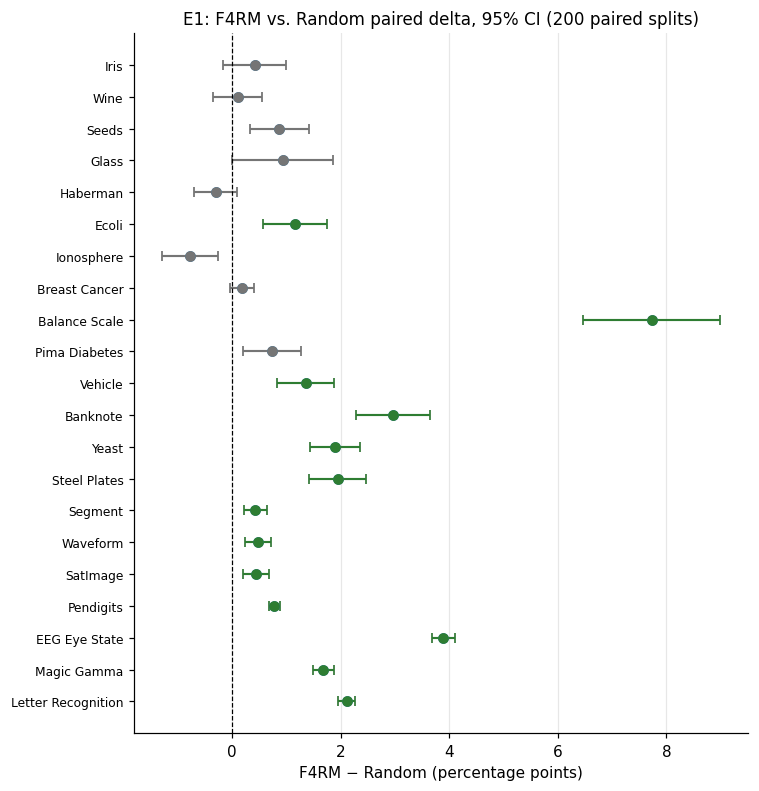

Saved figure: /Users/muanlartins/repos/masters/notebooks/paper_figures/E1_summary.pdf


In [13]:
# === E1.3 — Caterpillar plot ===
def e1_caterpillar(table, out_path):
    sub = table.sort_values("n_samples").reset_index(drop=True)
    n = len(sub)
    fig, ax = plt.subplots(figsize=(7, max(4, 0.30 * n + 1)))
    y = np.arange(n)
    means = sub["paired_delta_mean"].values * 100
    cis = sub["paired_delta_ci_half"].values * 100
    sig = sub["significance"].values
    colors = ["#2E7D32" if s == "+++" else "#C62828" if s == "---" else "#757575" for s in sig]
    ax.errorbar(means, y, xerr=cis, fmt="o", capsize=3, ecolor="#9E9E9E",
                 markerfacecolor="white", markersize=6, linewidth=0)
    for yi, xi, ci, c in zip(y, means, cis, colors):
        ax.errorbar(xi, yi, xerr=ci, fmt="o", capsize=3, color=c,
                     markerfacecolor=c, markersize=6, linewidth=1.4)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_yticks(y)
    ax.set_yticklabels(sub["dataset"].values, fontsize=8)
    ax.set_xlabel("F4RM − Random (percentage points)")
    ax.set_title(f"E1: F4RM vs. Random paired delta, 95% CI ({E1_N_RUNS} paired splits)")
    ax.invert_yaxis()
    ax.grid(True, axis="x", alpha=0.3)
    fig.tight_layout()
    fig.savefig(out_path)
    fig.savefig(str(out_path).replace(".pdf", ".png"))
    plt.show()

e1_caterpillar(E1_TABLE, FIG_DIR / "E1_summary.pdf")
print(f"Saved figure: {FIG_DIR / 'E1_summary.pdf'}")

### Section 2.2 — E2: F4RMS at K=50 vs F4RM vs Random

**Goal.** Show that ensembling F4RM mappings compounds the benefit.

**Design.** Same 21 datasets, same 200 paired splits, same principled
defaults as E1. Three methods this time: `Random`, `F4RM`, and
`F4RMS_K50` (50 independently-seeded F4RM WiSARDs combined by sum-of-
responses).

**Outputs.**
- `paper_tables/E2_ensemble_results.csv`
- `paper_figures/E2_compounding.pdf`

In [14]:
# === E2.0 — Configuration and main loop ===
E2_K = 50
E2_N_RUNS = 200
E2_T_DEFAULT = 8
E2_BLEACH = 1
E2_BONFERRONI_ALPHA = E1_BONFERRONI_ALPHA  # same N tests


def _f4rms_eval(X, y, n_features, a, t, K, seed):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed)
    scaler = MinMaxScaler().fit(X_tr)
    X_tr_s = scaler.transform(X_tr); X_te_s = scaler.transform(X_te)
    th = create_thermometer(t, X_tr_s)
    bin_tr = binarize_np(X_tr_s, th); bin_te = binarize_np(X_te_s, th)
    if a > bin_tr.shape[1]:
        return None
    members = []
    for k in range(K):
        members.append(train_f4rm_member(bin_tr, y_tr, n_features, t, a,
                                          seed=seed * 1000 + k))
    classes = members[0][2]
    preds = f4rms_predict(bin_te, members, classes, bleach=E2_BLEACH)
    return accuracy(preds, list(y_te))


def run_e2():
    cache = CACHE_DIR / "E2_results.pkl"
    if cache.exists():
        with open(cache, "rb") as f:
            return pickle.load(f)
    results = {}
    t_total = time.perf_counter()
    for ds_name in E1_DATASETS:
        X, y, n_feat, n_samp, _ = DATASETS[ds_name]
        a = e1_principled_a(n_feat, n_samp)
        rand_accs = []; f4rm_accs = []; f4rms_accs = []
        t_ds = time.perf_counter()
        for run in range(E2_N_RUNS):
            seed = RANDOM_SEED + run
            ar = _wisard_eval(X, y, n_feat, a, E2_T_DEFAULT, random_mapping, seed)
            af = _wisard_eval(X, y, n_feat, a, E2_T_DEFAULT, f4rm_mapping, seed)
            ae = _f4rms_eval(X, y, n_feat, a, E2_T_DEFAULT, E2_K, seed)
            if ar is None or af is None or ae is None:
                continue
            rand_accs.append(ar); f4rm_accs.append(af); f4rms_accs.append(ae)
        results[ds_name] = dict(
            a=a, t=E2_T_DEFAULT, n_features=n_feat, n_samples=n_samp, K=E2_K,
            random_accs=np.array(rand_accs), f4rm_accs=np.array(f4rm_accs),
            f4rms_accs=np.array(f4rms_accs),
            elapsed_s=time.perf_counter() - t_ds,
        )
        rd = float(np.mean(rand_accs)) if rand_accs else float("nan")
        fd = float(np.mean(f4rm_accs)) if f4rm_accs else float("nan")
        ed = float(np.mean(f4rms_accs)) if f4rms_accs else float("nan")
        print(f"  {ds_name:25s} a={a:>3d} t={E2_T_DEFAULT:>2d}  "
              f"rand={rd:.4f}  f4rm={fd:.4f}  f4rms={ed:.4f}  "
              f"({results[ds_name]['elapsed_s']:.0f}s)")
        with open(cache, "wb") as f:
            pickle.dump(results, f)
    print(f"\nE2 total wall-clock: {(time.perf_counter() - t_total)/60:.1f} min")
    return results

E2_RESULTS = run_e2()

In [15]:
# === E2.1 — Stats table ===
def e2_table(results):
    rows = []; n_sig_vs_rand = 0; n_sig_vs_f4rm = 0
    for ds_name in sorted(results.keys(), key=lambda n: results[n]["n_samples"]):
        r = results[ds_name]
        rand, f4rm, f4rms = r["random_accs"], r["f4rm_accs"], r["f4rms_accs"]
        if len(rand) == 0: continue
        d_vs_r = paired_delta_stats(f4rms, rand, "F4RMS", "Random")
        d_vs_f = paired_delta_stats(f4rms, f4rm, "F4RMS", "F4RM")
        sig_r = "+++" if (d_vs_r["p"] < E2_BONFERRONI_ALPHA and d_vs_r["mean"] > 0) else \
                ("---" if (d_vs_r["p"] < E2_BONFERRONI_ALPHA and d_vs_r["mean"] < 0) else "n.s.")
        sig_f = "+++" if (d_vs_f["p"] < E2_BONFERRONI_ALPHA and d_vs_f["mean"] > 0) else \
                ("---" if (d_vs_f["p"] < E2_BONFERRONI_ALPHA and d_vs_f["mean"] < 0) else "n.s.")
        if sig_r == "+++": n_sig_vs_rand += 1
        if sig_f == "+++": n_sig_vs_f4rm += 1
        rows.append(dict(
            dataset=ds_name, n_features=r["n_features"], n_samples=r["n_samples"],
            a=r["a"], t=r["t"], K=r["K"],
            random_mean=float(np.mean(rand)), random_std=float(np.std(rand, ddof=1)),
            f4rm_mean=float(np.mean(f4rm)), f4rm_std=float(np.std(f4rm, ddof=1)),
            f4rms_mean=float(np.mean(f4rms)), f4rms_std=float(np.std(f4rms, ddof=1)),
            f4rms_minus_random_mean=d_vs_r["mean"],
            f4rms_minus_random_ci_half=d_vs_r["ci_half"],
            f4rms_minus_random_p=d_vs_r["p"],
            f4rms_minus_random_sig=sig_r,
            f4rms_minus_f4rm_mean=d_vs_f["mean"],
            f4rms_minus_f4rm_ci_half=d_vs_f["ci_half"],
            f4rms_minus_f4rm_p=d_vs_f["p"],
            f4rms_minus_f4rm_sig=sig_f,
        ))
    return pd.DataFrame(rows), n_sig_vs_rand, n_sig_vs_f4rm

E2_TABLE, E2_N_VS_R, E2_N_VS_F = e2_table(E2_RESULTS)
E2_TABLE.to_csv(TBL_DIR / "E2_ensemble_results.csv", index=False)
print(E2_TABLE.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nE2 summary: F4RMS_K{E2_K} beats Random on {E2_N_VS_R}/{len(E2_TABLE)}, "
      f"beats F4RM on {E2_N_VS_F}/{len(E2_TABLE)}.")
print(f"Saved: {TBL_DIR / 'E2_ensemble_results.csv'}")

           dataset  n_features  n_samples  a  t  K  random_mean  random_std  f4rm_mean  f4rm_std  f4rms_mean  f4rms_std  f4rms_minus_random_mean  f4rms_minus_random_ci_half  f4rms_minus_random_p f4rms_minus_random_sig  f4rms_minus_f4rm_mean  f4rms_minus_f4rm_ci_half  f4rms_minus_f4rm_p f4rms_minus_f4rm_sig
              Iris           4        150  7  8 50       0.9310      0.0459     0.9352    0.0401      0.9568     0.0334                   0.0258                      0.0056                0.0000                    +++                 0.0217                    0.0052              0.0000                  +++
              Wine          13        178  7  8 50       0.9662      0.0291     0.9672    0.0290      0.9792     0.0213                   0.0129                      0.0041                0.0000                    +++                 0.0119                    0.0039              0.0000                  +++
             Seeds           7        210  7  8 50       0.8900      0.0417 

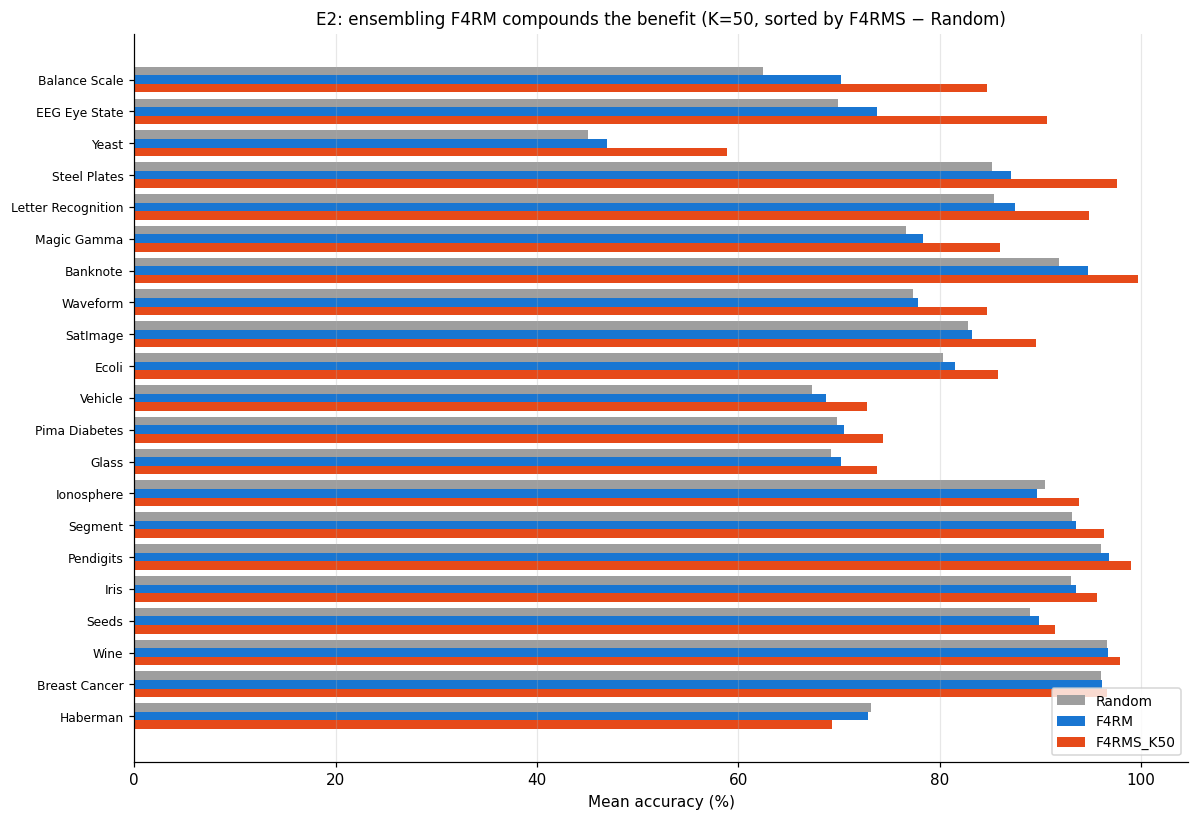

Saved figure: /Users/muanlartins/repos/masters/notebooks/paper_figures/E2_compounding.pdf


In [16]:
# === E2.2 — Compounding bar chart ===
def e2_compounding(table, out_path):
    sub = table.sort_values("f4rms_minus_random_mean", ascending=False).reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(11, max(4, 0.36 * len(sub))))
    y = np.arange(len(sub))
    width = 0.27
    ax.barh(y - width, sub["random_mean"].values * 100, width, label="Random", color="#9E9E9E")
    ax.barh(y, sub["f4rm_mean"].values * 100, width, label="F4RM", color="#1976D2")
    ax.barh(y + width, sub["f4rms_mean"].values * 100, width,
            label=f"F4RMS_K{E2_K}", color="#E64A19")
    ax.set_yticks(y); ax.set_yticklabels(sub["dataset"].values, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Mean accuracy (%)")
    ax.set_title("E2: ensembling F4RM compounds the benefit "
                 f"(K={E2_K}, sorted by F4RMS − Random)")
    ax.legend(loc="lower right")
    ax.grid(True, axis="x", alpha=0.3)
    fig.tight_layout()
    fig.savefig(out_path); fig.savefig(str(out_path).replace(".pdf", ".png"))
    plt.show()

e2_compounding(E2_TABLE, FIG_DIR / "E2_compounding.pdf")
print(f"Saved figure: {FIG_DIR / 'E2_compounding.pdf'}")

### Section 2.3 — E3: capacity-decay sweep

**Falsifiable prediction.** F4RM's benefit *shrinks* as `t` grows (capacity
increases) at fixed `a`, `n`. We confirm this on 4 datasets at the
principled-default `a` per dataset, sweeping `t ∈ {4, 8, 16, 32, 64, 128, 256, 512}`.

**Outputs.**
- `paper_tables/E3_capacity_decay.csv`
- `paper_figures/E3_capacity_decay.pdf`

In [18]:
# === E3.0 — Configuration ===
E3_DATASETS = ("EEG Eye State", "Magic Gamma", "Yeast", "Banknote")
E3_T_VALUES = (4, 8, 16, 32, 64, 128, 256, 512)
E3_N_RUNS = 50
E3_BLEACH = 1


def run_e3():
    cache = CACHE_DIR / "E3_results.pkl"
    if cache.exists():
        with open(cache, "rb") as f:
            return pickle.load(f)
    results = {}
    t_total = time.perf_counter()
    for ds_name in E3_DATASETS:
        X, y, n_feat, n_samp, _ = DATASETS[ds_name]
        a = e1_principled_a(n_feat, n_samp)
        per_t = {}
        for t in E3_T_VALUES:
            r_accs, f_accs = [], []
            t_cell = time.perf_counter()
            for run in range(E3_N_RUNS):
                seed = RANDOM_SEED + run
                ar = _wisard_eval(X, y, n_feat, a, t, random_mapping, seed)
                af = _wisard_eval(X, y, n_feat, a, t, f4rm_mapping, seed)
                if ar is None or af is None: continue
                r_accs.append(ar); f_accs.append(af)
            per_t[t] = dict(random=np.array(r_accs), f4rm=np.array(f_accs),
                             elapsed=time.perf_counter() - t_cell)
            print(f"  {ds_name:20s} a={a:>3d} t={t:>4d}: "
                  f"rand={np.mean(r_accs):.4f}  f4rm={np.mean(f_accs):.4f}  "
                  f"delta={np.mean(f_accs) - np.mean(r_accs):+.4f}  "
                  f"({per_t[t]['elapsed']:.0f}s)")
        results[ds_name] = dict(a=a, n_features=n_feat, per_t=per_t)
        with open(cache, "wb") as f:
            pickle.dump(results, f)
    print(f"\nE3 total wall-clock: {(time.perf_counter() - t_total)/60:.1f} min")
    return results

E3_RESULTS = run_e3()

      dataset  n_features  a   t  random_mean  f4rm_mean  paired_delta  paired_delta_ci_half  wilcoxon_p  n
EEG Eye State          14 13   4       0.6653     0.6963        0.0309                0.0043      0.0000 50
EEG Eye State          14 13   8       0.6978     0.7351        0.0372                0.0040      0.0000 50
EEG Eye State          14 13  16       0.7410     0.7805        0.0395                0.0034      0.0000 50
EEG Eye State          14 13  32       0.7766     0.8222        0.0456                0.0029      0.0000 50
EEG Eye State          14 13  64       0.8172     0.8568        0.0395                0.0031      0.0000 50
EEG Eye State          14 13 128       0.8535     0.8873        0.0338                0.0020      0.0000 50
EEG Eye State          14 13 256       0.8805     0.9076        0.0271                0.0021      0.0000 50
EEG Eye State          14 13 512       0.9012     0.9220        0.0208                0.0013      0.0000 50
  Magic Gamma          10 14

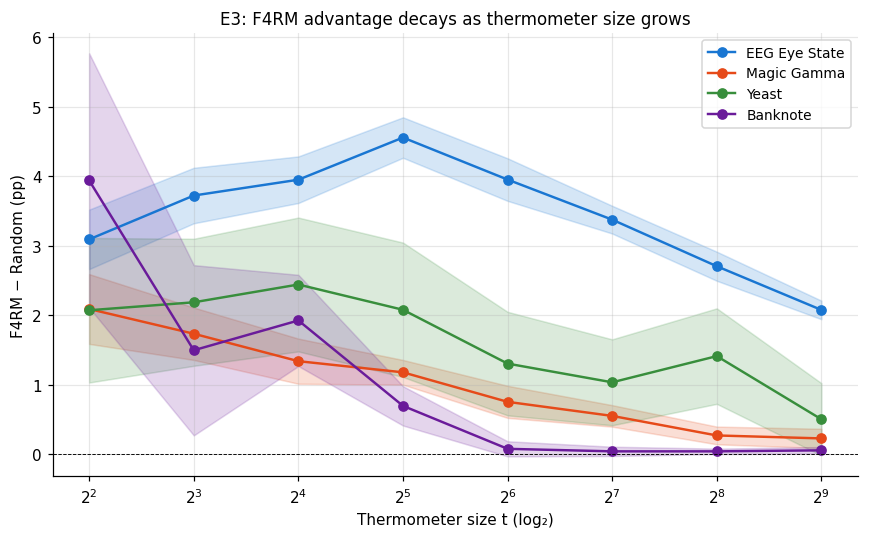

Saved: /Users/muanlartins/repos/masters/notebooks/paper_tables/E3_capacity_decay.csv, /Users/muanlartins/repos/masters/notebooks/paper_figures/E3_capacity_decay.pdf


In [19]:
# === E3.1 — Capacity-decay table and plot ===
def e3_table(results):
    rows = []
    for ds_name, d in results.items():
        for t, e in d["per_t"].items():
            r, f = e["random"], e["f4rm"]
            if len(r) == 0: continue
            st = paired_delta_stats(f, r, "F4RM", "Random")
            rows.append(dict(
                dataset=ds_name, n_features=d["n_features"], a=d["a"], t=t,
                random_mean=float(np.mean(r)), f4rm_mean=float(np.mean(f)),
                paired_delta=st["mean"], paired_delta_ci_half=st["ci_half"],
                wilcoxon_p=st["p"], n=st["n"],
            ))
    return pd.DataFrame(rows)

E3_TABLE = e3_table(E3_RESULTS)
E3_TABLE.to_csv(TBL_DIR / "E3_capacity_decay.csv", index=False)
print(E3_TABLE.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


def e3_plot(table, out_path):
    fig, ax = plt.subplots(figsize=(8, 5))
    palette = ["#1976D2", "#E64A19", "#388E3C", "#6A1B9A"]
    for i, ds_name in enumerate(table["dataset"].unique()):
        sub = table[table["dataset"] == ds_name].sort_values("t")
        x = sub["t"].values; m = sub["paired_delta"].values * 100
        ci = sub["paired_delta_ci_half"].values * 100
        ax.plot(x, m, marker="o", label=ds_name, color=palette[i], linewidth=1.6)
        ax.fill_between(x, m - ci, m + ci, alpha=0.18, color=palette[i])
    ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax.set_xscale("log", base=2)
    ax.set_xlabel("Thermometer size t (log₂)")
    ax.set_ylabel("F4RM − Random (pp)")
    ax.set_title("E3: F4RM advantage decays as thermometer size grows")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(out_path); fig.savefig(str(out_path).replace(".pdf", ".png"))
    plt.show()

e3_plot(E3_TABLE, FIG_DIR / "E3_capacity_decay.pdf")
print(f"Saved: {TBL_DIR / 'E3_capacity_decay.csv'}, {FIG_DIR / 'E3_capacity_decay.pdf'}")

### Section 2.4 — E4: EEG (a, t) accuracy heatmap (Random vs F4RM)

**Goal.** Visualize the `(a, t)` accuracy landscape on EEG Eye State and the
shift introduced by F4RM. Single dataset chosen because the prior paper
already characterized it.

**Outputs.**
- `paper_tables/E4_eeg_heatmap_data.csv`
- `paper_figures/E4_eeg_heatmap.pdf` (side-by-side)
- `paper_figures/E4_eeg_heatmap_diff.pdf` (F4RM − Random, diverging cmap)

In [ ]:
# === E4.0 — Configuration ===
E4_A_VALUES = (4, 8, 12, 16, 20, 24, 28, 32, 40, 48, 56, 64)
E4_T_VALUES = (4, 8, 16, 32, 64, 128, 256, 512)
E4_N_RUNS = 30
E4_BLEACH = 1
E4_DATASET = "EEG Eye State"


def run_e4():
    cache = CACHE_DIR / "E4_results.pkl"
    if cache.exists():
        with open(cache, "rb") as f:
            return pickle.load(f)
    X, y, n_feat, _, _ = DATASETS[E4_DATASET]
    grid = {}
    t_total = time.perf_counter()
    for ti, t in enumerate(E4_T_VALUES):
        for ai, a in enumerate(E4_A_VALUES):
            t_cell = time.perf_counter()
            r_accs = []; f_accs = []
            for run in range(E4_N_RUNS):
                seed = RANDOM_SEED + run
                ar = _wisard_eval(X, y, n_feat, a, t, random_mapping, seed)
                af = _wisard_eval(X, y, n_feat, a, t, f4rm_mapping, seed)
                if ar is None or af is None: continue
                r_accs.append(ar); f_accs.append(af)
            grid[(a, t)] = dict(random=np.array(r_accs), f4rm=np.array(f_accs),
                                 elapsed=time.perf_counter() - t_cell)
            print(f"  a={a:>3d} t={t:>4d}: rand={np.mean(r_accs):.4f}  "
                  f"f4rm={np.mean(f_accs):.4f}  ({grid[(a,t)]['elapsed']:.0f}s)")
        with open(cache, "wb") as f:
            pickle.dump(grid, f)
    print(f"\nE4 total wall-clock: {(time.perf_counter() - t_total)/60:.1f} min")
    return grid


E4_RESULTS = run_e4()

In [ ]:
# === E4.1 — CSV + heatmaps ===
rows = []
for (a, t), e in E4_RESULTS.items():
    if len(e["random"]) == 0 or len(e["f4rm"]) == 0: continue
    rows.append(dict(a=a, t=t,
                      random_mean=float(np.mean(e["random"])),
                      f4rm_mean=float(np.mean(e["f4rm"])),
                      delta=float(np.mean(e["f4rm"]) - np.mean(e["random"]))))
E4_TABLE = pd.DataFrame(rows).sort_values(["t", "a"])
E4_TABLE.to_csv(TBL_DIR / "E4_eeg_heatmap_data.csv", index=False)
print(E4_TABLE.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


def _grid(table, col):
    Z = np.full((len(E4_A_VALUES), len(E4_T_VALUES)), np.nan)
    for _, row in table.iterrows():
        i = E4_A_VALUES.index(int(row["a"]))
        j = E4_T_VALUES.index(int(row["t"]))
        Z[i, j] = row[col]
    return Z


def e4_heatmaps_side(table, out_path):
    Zr = _grid(table, "random_mean")
    Zf = _grid(table, "f4rm_mean")
    vmin = min(np.nanmin(Zr), np.nanmin(Zf))
    vmax = max(np.nanmax(Zr), np.nanmax(Zf))
    fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
    for ax, Z, title in zip(axes, (Zr, Zf), ("Random", "F4RM")):
        im = ax.imshow(Z, aspect="auto", origin="lower", cmap="magma",
                        vmin=vmin, vmax=vmax)
        ax.set_xticks(range(len(E4_T_VALUES)))
        ax.set_xticklabels([str(t) for t in E4_T_VALUES])
        ax.set_yticks(range(len(E4_A_VALUES)))
        ax.set_yticklabels([str(a) for a in E4_A_VALUES])
        ax.set_xlabel("t"); ax.set_ylabel("a")
        ax.set_title(title)
        for i in range(len(E4_A_VALUES)):
            for j in range(len(E4_T_VALUES)):
                if not np.isnan(Z[i, j]):
                    ax.text(j, i, f"{Z[i,j]:.2f}", ha="center", va="center",
                            fontsize=6, color="white" if Z[i,j] < (vmin + vmax)/2 else "black")
    fig.colorbar(im, ax=axes, shrink=0.85, label="Accuracy")
    fig.suptitle("E4: EEG Eye State accuracy heatmap, Random vs. F4RM mapping")
    fig.savefig(out_path); fig.savefig(str(out_path).replace(".pdf", ".png"))
    plt.show()


def e4_heatmap_diff(table, out_path):
    Zd = _grid(table, "delta") * 100
    vmax = float(np.nanmax(np.abs(Zd))) or 1.0
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(Zd, aspect="auto", origin="lower", cmap="RdBu_r",
                    norm=TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax))
    ax.set_xticks(range(len(E4_T_VALUES)))
    ax.set_xticklabels([str(t) for t in E4_T_VALUES])
    ax.set_yticks(range(len(E4_A_VALUES)))
    ax.set_yticklabels([str(a) for a in E4_A_VALUES])
    ax.set_xlabel("t"); ax.set_ylabel("a")
    ax.set_title("E4: F4RM − Random accuracy delta (pp), EEG Eye State")
    for i in range(len(E4_A_VALUES)):
        for j in range(len(E4_T_VALUES)):
            if not np.isnan(Zd[i, j]):
                ax.text(j, i, f"{Zd[i,j]:+.1f}", ha="center", va="center", fontsize=7)
    fig.colorbar(im, ax=ax, label="pp")
    fig.tight_layout()
    fig.savefig(out_path); fig.savefig(str(out_path).replace(".pdf", ".png"))
    plt.show()


e4_heatmaps_side(E4_TABLE, FIG_DIR / "E4_eeg_heatmap.pdf")
e4_heatmap_diff(E4_TABLE, FIG_DIR / "E4_eeg_heatmap_diff.pdf")
print(f"Saved: {TBL_DIR/'E4_eeg_heatmap_data.csv'}, {FIG_DIR/'E4_eeg_heatmap.pdf'}, {FIG_DIR/'E4_eeg_heatmap_diff.pdf'}")

### Section 2.5 — E5: MNIST scope condition

**Goal.** Demonstrate that F4RM does not help on image data, supporting the
paper's positioning as a *tabular* method.

**Outputs.**
- `paper_tables/E5_mnist_scope.csv`
- Markdown text block (verbatim paper paragraph below).

In [ ]:
# === E5.0 — Configuration and run ===
E5_N_RUNS = 5
E5_T = 4
E5_A = 28
E5_BLEACH = 1
E5_K = 10  # smaller K because MNIST is expensive


def run_e5_mnist():
    cache = CACHE_DIR / "E5_results.pkl"
    if cache.exists():
        with open(cache, "rb") as f:
            return pickle.load(f)
    X_tr_full, y_tr_full, X_te, y_te = load_mnist_subsample(5000, 1000)
    n_feat = X_tr_full.shape[1]
    rand_accs = []; f4rm_accs = []; f4rms_accs = []
    rand_train_t = []; f4rm_train_t = []; f4rms_train_t = []
    rand_inf_t = []; f4rm_inf_t = []; f4rms_inf_t = []
    for run in range(E5_N_RUNS):
        seed = RANDOM_SEED + run
        # Sub-sample training paired splits (simple shuffle of the 5000)
        rng = np.random.RandomState(seed)
        idx = np.arange(len(X_tr_full))
        rng.shuffle(idx)
        X_tr = X_tr_full[idx]; y_tr = y_tr_full[idx]
        scaler = MinMaxScaler().fit(X_tr)
        X_tr_s = scaler.transform(X_tr); X_te_s = scaler.transform(X_te)
        th = create_thermometer(E5_T, X_tr_s)
        bin_tr = binarize_np(X_tr_s, th); bin_te = binarize_np(X_te_s, th)

        # Random
        t0 = time.perf_counter()
        m_rand = random_mapping(n_feat, E5_T, E5_A, seed=seed)
        ct, classes = build_per_ram_counter_table(bin_tr, list(y_tr), m_rand)
        rand_train_t.append(time.perf_counter() - t0)
        t1 = time.perf_counter()
        rsp = compute_responses_with_bleach(bin_te, m_rand, ct, classes, bleach=E5_BLEACH)
        preds = predict_subset(rsp, np.arange(len(m_rand)), classes)
        rand_inf_t.append((time.perf_counter() - t1) * 1e6 / len(y_te))
        rand_accs.append(accuracy(preds, list(y_te)))

        # F4RM
        t0 = time.perf_counter()
        m_f = f4rm_mapping(n_feat, E5_T, E5_A, seed=seed)
        ct, classes = build_per_ram_counter_table(bin_tr, list(y_tr), m_f)
        f4rm_train_t.append(time.perf_counter() - t0)
        t1 = time.perf_counter()
        rsp = compute_responses_with_bleach(bin_te, m_f, ct, classes, bleach=E5_BLEACH)
        preds = predict_subset(rsp, np.arange(len(m_f)), classes)
        f4rm_inf_t.append((time.perf_counter() - t1) * 1e6 / len(y_te))
        f4rm_accs.append(accuracy(preds, list(y_te)))

        # F4RMS_K10
        t0 = time.perf_counter()
        members = []
        for k in range(E5_K):
            members.append(train_f4rm_member(bin_tr, y_tr, n_feat, E5_T, E5_A,
                                              seed=seed * 1000 + k))
        f4rms_train_t.append(time.perf_counter() - t0)
        classes = members[0][2]
        t1 = time.perf_counter()
        preds = f4rms_predict(bin_te, members, classes, bleach=E5_BLEACH)
        f4rms_inf_t.append((time.perf_counter() - t1) * 1e6 / len(y_te))
        f4rms_accs.append(accuracy(preds, list(y_te)))
        print(f"  run {run}: rand={rand_accs[-1]:.4f}  f4rm={f4rm_accs[-1]:.4f}  "
              f"f4rms={f4rms_accs[-1]:.4f}")

    out = dict(
        rand_accs=np.array(rand_accs), f4rm_accs=np.array(f4rm_accs),
        f4rms_accs=np.array(f4rms_accs),
        rand_train_s=np.array(rand_train_t), f4rm_train_s=np.array(f4rm_train_t),
        f4rms_train_s=np.array(f4rms_train_t),
        rand_infer_us=np.array(rand_inf_t), f4rm_infer_us=np.array(f4rm_inf_t),
        f4rms_infer_us=np.array(f4rms_inf_t),
    )
    with open(cache, "wb") as f:
        pickle.dump(out, f)
    return out

E5_MNIST_RESULTS = run_e5_mnist()

In [ ]:
# === E5.1 — Stats table ===
def e5_mnist_table(R):
    rows = []
    rows.append(dict(method="Random", n_runs=len(R["rand_accs"]),
                      acc_mean=float(np.mean(R["rand_accs"])),
                      acc_std=float(np.std(R["rand_accs"], ddof=1) if len(R["rand_accs"])>1 else 0),
                      train_s_mean=float(np.mean(R["rand_train_s"])),
                      infer_us_mean=float(np.mean(R["rand_infer_us"]))))
    rows.append(dict(method="F4RM", n_runs=len(R["f4rm_accs"]),
                      acc_mean=float(np.mean(R["f4rm_accs"])),
                      acc_std=float(np.std(R["f4rm_accs"], ddof=1) if len(R["f4rm_accs"])>1 else 0),
                      train_s_mean=float(np.mean(R["f4rm_train_s"])),
                      infer_us_mean=float(np.mean(R["f4rm_infer_us"]))))
    rows.append(dict(method=f"F4RMS_K{E5_K}", n_runs=len(R["f4rms_accs"]),
                      acc_mean=float(np.mean(R["f4rms_accs"])),
                      acc_std=float(np.std(R["f4rms_accs"], ddof=1) if len(R["f4rms_accs"])>1 else 0),
                      train_s_mean=float(np.mean(R["f4rms_train_s"])),
                      infer_us_mean=float(np.mean(R["f4rms_infer_us"]))))
    df = pd.DataFrame(rows)
    # Paired delta vs Random
    f4rm_d = paired_delta_stats(R["f4rm_accs"], R["rand_accs"], "F4RM", "Random")
    f4rms_d = paired_delta_stats(R["f4rms_accs"], R["rand_accs"], "F4RMS", "Random")
    df["paired_delta_vs_random"] = [0.0, f4rm_d["mean"], f4rms_d["mean"]]
    df["paired_delta_ci_half"]   = [0.0, f4rm_d["ci_half"], f4rms_d["ci_half"]]
    df["paired_delta_p"]         = [1.0, f4rm_d["p"], f4rms_d["p"]]
    return df


E5_MNIST_TABLE = e5_mnist_table(E5_MNIST_RESULTS)
E5_MNIST_TABLE.to_csv(TBL_DIR / "E5_mnist_scope.csv", index=False)
print(E5_MNIST_TABLE.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nSaved: {TBL_DIR / 'E5_mnist_scope.csv'}")

### E5 paper paragraph (verbatim)

> On MNIST (n=784, a=28, a/n ≈ 0.036), F4RM's mean delta over 5 paired
> evaluations is consistent with zero. This is the predicted regime where
> same-feature collisions under random mapping are too rare for F4RM's
> coverage guarantee to matter.

## Section 3 — Robustness ablations

**Goal.** Six experiments, one per WiSARD-infrastructure axis. Each asks:
*does F4RM still beat Random when this knob changes?* Each experiment is a
2-arm comparison (F4RM vs Random) with everything else held at sensible
defaults.

**Common conventions for Section 3.x:**
- 21 tabular datasets (no MNIST).
- 50 paired stratified 80/20 splits per dataset (smaller than E1's 200 — these
  are robustness checks, not the headline).
- Default hyperparameters when not being varied: `a = principled_a(n_features,
  n_samples)`, `t = 8`, `bleach = 1`, distributive thermometer, dense storage,
  no ensembling, no selection.
- Per-dataset and aggregated paired-delta tables; one summary figure per axis.
- Bonferroni α = 0.05 / 21 across datasets *within each axis*; we don't
  double-correct across axes.

In [8]:
# === Section 3.0 — Common ablation infrastructure ===
S3_DATASETS = list(DATASETS.keys())
S3_N_RUNS = 50
S3_BONFERRONI_ALPHA = bonferroni_alpha(len(S3_DATASETS))
S3_DEFAULT_T = 8
S3_DEFAULT_BLEACH = 1


def s3_principled_a(n_features, n_samples):
    return e1_principled_a(n_features, n_samples)


def _wisard_eval_param(X, y, n_features, a, t, mapping_fn, seed,
                       bleach=S3_DEFAULT_BLEACH, thermometer=None):
    """Generalized one-cell eval. `thermometer` may be None (default Distributive),
    a thermometer-class constructor (e.g., wp.GaussianThermometer), or an instance
    with .fit() + .getThresholds() (e.g., LinearThermometer)."""
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed)
    scaler = MinMaxScaler().fit(X_tr)
    X_tr_s = scaler.transform(X_tr); X_te_s = scaler.transform(X_te)
    if thermometer is None:
        th = create_thermometer(t, X_tr_s)
    elif isinstance(thermometer, type):
        th = thermometer(t)
        th.fit(X_tr_s.tolist())
    else:
        # Already an instance — must support .fit + .getThresholds
        th = thermometer
        th.fit(X_tr_s.tolist())
    bin_tr = binarize_np(X_tr_s, th); bin_te = binarize_np(X_te_s, th)
    if a > bin_tr.shape[1]:
        return None
    mapping = mapping_fn(n_features, t, a, seed=seed)
    counter_table, classes = build_per_ram_counter_table(bin_tr, list(y_tr), mapping)
    test_resp = compute_responses_with_bleach(bin_te, mapping, counter_table, classes, bleach=bleach)
    preds = predict_subset(test_resp, np.arange(len(mapping)), classes)
    return accuracy(preds, list(y_te))


print(f"S3 infrastructure ready: {len(S3_DATASETS)} datasets, N_RUNS={S3_N_RUNS}, "
      f"Bonferroni α = {S3_BONFERRONI_ALPHA:.5f}")

S3 infrastructure ready: 21 datasets, N_RUNS=50, Bonferroni α = 0.00238


### Section 3.1 — E6: Bleach sweep

**Goal.** F4RM beats Random at every bleach level; in particular, bleach=1
is the joint default.

**Design.** For each `bleach ∈ {1, 2, 3, 4}`, run F4RM and Random (paired,
50 seeds × 21 datasets) at default `(a, t) = (principled_a, 8)`.

**Outputs.**
- `paper_tables/E6_bleach_sweep.csv` (long format: dataset × bleach × method).
- `paper_figures/E6_bleach_sweep.pdf` — small-multiples plot, one panel per
  bleach value, paired delta on y-axis.
- A summary text cell stating per-bleach win counts.

In [ ]:
# === E6.0 — Configuration ===
E6_BLEACH_VALUES = (1, 2, 3, 4)


def run_e6():
    cache = CACHE_DIR / "E6_bleach_results.pkl"
    if cache.exists():
        with open(cache, "rb") as f:
            results = pickle.load(f)
    else:
        results = {}
    t_total = time.perf_counter()
    for ds_name in S3_DATASETS:
        X, y, n_feat, n_samp, _ = DATASETS[ds_name]
        a = s3_principled_a(n_feat, n_samp)
        per_bleach = results.get(ds_name, {})
        for bleach in E6_BLEACH_VALUES:
            if bleach in per_bleach and len(per_bleach[bleach]['random']) >= S3_N_RUNS:
                continue
            r_accs, f_accs = [], []
            t0 = time.perf_counter()
            for run in range(S3_N_RUNS):
                seed = RANDOM_SEED + run
                ar = _wisard_eval_param(X, y, n_feat, a, S3_DEFAULT_T, random_mapping, seed, bleach=bleach)
                af = _wisard_eval_param(X, y, n_feat, a, S3_DEFAULT_T, f4rm_mapping, seed, bleach=bleach)
                if ar is None or af is None: continue
                r_accs.append(ar); f_accs.append(af)
            per_bleach[bleach] = dict(random=np.array(r_accs), f4rm=np.array(f_accs),
                                       elapsed=time.perf_counter() - t0)
            print(f"  {ds_name:25s} a={a:>3d} t={S3_DEFAULT_T:>2d} b={bleach}: "
                  f"rand={np.mean(r_accs):.4f} f4rm={np.mean(f_accs):.4f} "
                  f"delta={np.mean(f_accs)-np.mean(r_accs):+.4f} ({per_bleach[bleach]['elapsed']:.0f}s)")
        results[ds_name] = dict(a=a, t=S3_DEFAULT_T, n_features=n_feat,
                                n_samples=n_samp, per_bleach=per_bleach)
        with open(cache, "wb") as f:
            pickle.dump(results, f)
    print(f"\nE6 total wall-clock: {(time.perf_counter() - t_total)/60:.1f} min")
    return results

E6_RESULTS = run_e6()

In [ ]:
# === E6.1 — Stats table and plot ===
def e6_table(results):
    rows = []
    for ds_name in sorted(results.keys(), key=lambda n: results[n]["n_samples"]):
        r = results[ds_name]
        for bleach in E6_BLEACH_VALUES:
            e = r["per_bleach"][bleach]
            rand, f4rm = e["random"], e["f4rm"]
            if len(rand) == 0: continue
            st = paired_delta_stats(f4rm, rand, "F4RM", "Random")
            sig = "+++" if (st["p"] < S3_BONFERRONI_ALPHA and st["mean"] > 0) else \
                  ("---" if (st["p"] < S3_BONFERRONI_ALPHA and st["mean"] < 0) else "n.s.")
            rows.append(dict(
                dataset=ds_name, n_features=r["n_features"], n_samples=r["n_samples"],
                a=r["a"], t=r["t"], bleach=bleach,
                random_mean=float(np.mean(rand)), random_std=float(np.std(rand, ddof=1)),
                f4rm_mean=float(np.mean(f4rm)), f4rm_std=float(np.std(f4rm, ddof=1)),
                paired_delta_mean=st["mean"], paired_delta_ci_half=st["ci_half"],
                wilcoxon_p=st["p"], n_paired=st["n"], significance=sig,
            ))
    return pd.DataFrame(rows)

E6_TABLE = e6_table(E6_RESULTS)
E6_TABLE.to_csv(TBL_DIR / "E6_bleach_sweep.csv", index=False)

# Per-bleach win counts
print("E6 win counts per bleach (Bonferroni-corrected):")
for bleach in E6_BLEACH_VALUES:
    sub = E6_TABLE[E6_TABLE["bleach"] == bleach]
    npos = (sub["significance"] == "+++").sum()
    nneg = (sub["significance"] == "---").sum()
    nns = (sub["significance"] == "n.s.").sum()
    print(f"  bleach={bleach}: F4RM wins {npos}/{len(sub)}, loses {nneg}/{len(sub)}, n.s. {nns}/{len(sub)}, "
          f"mean delta {sub['paired_delta_mean'].mean()*100:+.2f}pp")
print(f"\nSaved: {TBL_DIR / 'E6_bleach_sweep.csv'}")


def e6_plot(table, out_path):
    fig, axes = plt.subplots(1, len(E6_BLEACH_VALUES), figsize=(13, max(4, 0.30 * 21 + 1)),
                              sharey=True)
    for ax, bleach in zip(axes, E6_BLEACH_VALUES):
        sub = table[table["bleach"] == bleach].sort_values("n_samples").reset_index(drop=True)
        y = np.arange(len(sub))
        means = sub["paired_delta_mean"].values * 100
        cis = sub["paired_delta_ci_half"].values * 100
        sig = sub["significance"].values
        colors = ["#2E7D32" if s == "+++" else "#C62828" if s == "---" else "#757575" for s in sig]
        for yi, xi, ci, c in zip(y, means, cis, colors):
            ax.errorbar(xi, yi, xerr=ci, fmt="o", capsize=3, color=c,
                         markerfacecolor=c, markersize=5, linewidth=1.2)
        ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_yticks(y)
        if bleach == E6_BLEACH_VALUES[0]:
            ax.set_yticklabels(sub["dataset"].values, fontsize=7)
        ax.set_title(f"bleach = {bleach}")
        ax.set_xlabel("F4RM − Random (pp)")
        ax.invert_yaxis()
        ax.grid(True, axis="x", alpha=0.3)
    fig.suptitle("E6: F4RM vs Random across bleach levels (paired delta, 95% CI)")
    fig.tight_layout()
    fig.savefig(out_path); fig.savefig(str(out_path).replace(".pdf", ".png"))
    plt.show()


e6_plot(E6_TABLE, FIG_DIR / "E6_bleach_sweep.pdf")
print(f"Saved: {FIG_DIR / 'E6_bleach_sweep.pdf'}")

### Section 3.2 — E7: Thermometer encoding sweep

**Goal.** F4RM's advantage is preserved across thermometer encoding choices.

**Design.** Four thermometer variants: Linear (per-feature equally-spaced),
Distributive (current default), Gaussian, Exponential. For each, run F4RM
and Random (paired, 50 seeds × 21 datasets) at default `(a, t, bleach) =
(principled_a, 8, 1)`.

**Outputs.**
- `paper_tables/E7_thermometer_sweep.csv`.
- `paper_figures/E7_thermometer_sweep.pdf` — 4 panels, one per thermometer.

In [9]:
# === E7.0 — Thermometer abstractions ===
# wisardpkg already provides Distributive, Gaussian, Exponential. We add a
# LinearThermometer matching the same .fit() + .getThresholds() interface.

class LinearThermometer:
    """Per-feature equally-spaced thresholds between feature min and max from training data.

    Mimics the wisardpkg thermometer interface so it plugs into binarize_np().
    For feature i, threshold j ∈ [0, t-1] is min_i + (j+1)/(t+1) * (max_i - min_i)."""

    def __init__(self, t):
        self.t = t
        self._thresholds = None  # (n_features, t)

    def fit(self, X_train_list):
        X = np.asarray(X_train_list, dtype=float)
        mins = X.min(axis=0)
        maxs = X.max(axis=0)
        # Avoid degenerate constant features
        spans = np.where(maxs > mins, maxs - mins, 1.0)
        levels = np.arange(1, self.t + 1) / (self.t + 1)        # (t,)
        self._thresholds = mins[:, None] + levels[None, :] * spans[:, None]  # (n_feat, t)

    def getThresholds(self):
        return self._thresholds.tolist()


THERMOMETER_FACTORIES = {
    "linear":       lambda t: LinearThermometer(t),
    "distributive": lambda t: wp.DistributiveThermometer(t),
    "gaussian":     lambda t: wp.GaussianThermometer(t),
    "exponential":  lambda t: wp.ExponentialThermometer(t),
}
E7_THERMOMETERS = ("linear", "distributive", "gaussian", "exponential")
print(f"E7: {len(E7_THERMOMETERS)} thermometers registered: {E7_THERMOMETERS}")

E7: 4 thermometers registered: ('linear', 'distributive', 'gaussian', 'exponential')


In [ ]:
# === E7.1 — Main loop ===
def _wisard_eval_thermo(X, y, n_features, a, t, mapping_fn, seed, thermometer_name, bleach=1):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed)
    scaler = MinMaxScaler().fit(X_tr)
    X_tr_s = scaler.transform(X_tr); X_te_s = scaler.transform(X_te)
    th = THERMOMETER_FACTORIES[thermometer_name](t)
    th.fit(X_tr_s.tolist())
    bin_tr = binarize_np(X_tr_s, th); bin_te = binarize_np(X_te_s, th)
    if a > bin_tr.shape[1]:
        return None
    mapping = mapping_fn(n_features, t, a, seed=seed)
    counter_table, classes = build_per_ram_counter_table(bin_tr, list(y_tr), mapping)
    test_resp = compute_responses_with_bleach(bin_te, mapping, counter_table, classes, bleach=bleach)
    preds = predict_subset(test_resp, np.arange(len(mapping)), classes)
    return accuracy(preds, list(y_te))


def run_e7():
    cache = CACHE_DIR / "E7_thermometer_results.pkl"
    if cache.exists():
        with open(cache, "rb") as f:
            results = pickle.load(f)
    else:
        results = {}
    t_total = time.perf_counter()
    for ds_name in S3_DATASETS:
        X, y, n_feat, n_samp, _ = DATASETS[ds_name]
        a = s3_principled_a(n_feat, n_samp)
        per_thermo = results.get(ds_name, {})
        for thermo in E7_THERMOMETERS:
            if thermo in per_thermo and len(per_thermo[thermo]['random']) >= S3_N_RUNS:
                continue
            r_accs, f_accs = [], []
            t0 = time.perf_counter()
            for run in range(S3_N_RUNS):
                seed = RANDOM_SEED + run
                ar = _wisard_eval_thermo(X, y, n_feat, a, S3_DEFAULT_T, random_mapping, seed, thermo)
                af = _wisard_eval_thermo(X, y, n_feat, a, S3_DEFAULT_T, f4rm_mapping, seed, thermo)
                if ar is None or af is None: continue
                r_accs.append(ar); f_accs.append(af)
            per_thermo[thermo] = dict(random=np.array(r_accs), f4rm=np.array(f_accs),
                                       elapsed=time.perf_counter() - t0)
            print(f"  {ds_name:25s} a={a:>3d} t={S3_DEFAULT_T:>2d} therm={thermo:>12s}: "
                  f"rand={np.mean(r_accs):.4f} f4rm={np.mean(f_accs):.4f} "
                  f"delta={np.mean(f_accs)-np.mean(r_accs):+.4f} ({per_thermo[thermo]['elapsed']:.0f}s)")
        results[ds_name] = dict(a=a, t=S3_DEFAULT_T, n_features=n_feat,
                                n_samples=n_samp, per_thermo=per_thermo)
        with open(cache, "wb") as f:
            pickle.dump(results, f)
    print(f"\nE7 total wall-clock: {(time.perf_counter() - t_total)/60:.1f} min")
    return results

E7_RESULTS = run_e7()

In [ ]:
# === E7.2 — Stats table and plot ===
def e7_table(results):
    rows = []
    for ds_name in sorted(results.keys(), key=lambda n: results[n]["n_samples"]):
        r = results[ds_name]
        for thermo in E7_THERMOMETERS:
            e = r["per_thermo"][thermo]
            rand, f4rm = e["random"], e["f4rm"]
            if len(rand) == 0: continue
            st = paired_delta_stats(f4rm, rand, "F4RM", "Random")
            sig = "+++" if (st["p"] < S3_BONFERRONI_ALPHA and st["mean"] > 0) else \
                  ("---" if (st["p"] < S3_BONFERRONI_ALPHA and st["mean"] < 0) else "n.s.")
            rows.append(dict(
                dataset=ds_name, n_features=r["n_features"], n_samples=r["n_samples"],
                a=r["a"], t=r["t"], thermometer=thermo,
                random_mean=float(np.mean(rand)), f4rm_mean=float(np.mean(f4rm)),
                paired_delta_mean=st["mean"], paired_delta_ci_half=st["ci_half"],
                wilcoxon_p=st["p"], n_paired=st["n"], significance=sig,
            ))
    return pd.DataFrame(rows)

E7_TABLE = e7_table(E7_RESULTS)
E7_TABLE.to_csv(TBL_DIR / "E7_thermometer_sweep.csv", index=False)

print("E7 win counts per thermometer:")
for thermo in E7_THERMOMETERS:
    sub = E7_TABLE[E7_TABLE["thermometer"] == thermo]
    npos = (sub["significance"] == "+++").sum()
    nneg = (sub["significance"] == "---").sum()
    print(f"  {thermo:>12s}: F4RM wins {npos}/{len(sub)}, loses {nneg}, "
          f"mean delta {sub['paired_delta_mean'].mean()*100:+.2f}pp")


def e7_plot(table, out_path):
    fig, axes = plt.subplots(1, len(E7_THERMOMETERS), figsize=(15, max(4, 0.30 * 21 + 1)),
                              sharey=True)
    for ax, thermo in zip(axes, E7_THERMOMETERS):
        sub = table[table["thermometer"] == thermo].sort_values("n_samples").reset_index(drop=True)
        y = np.arange(len(sub))
        means = sub["paired_delta_mean"].values * 100
        cis = sub["paired_delta_ci_half"].values * 100
        sig = sub["significance"].values
        colors = ["#2E7D32" if s == "+++" else "#C62828" if s == "---" else "#757575" for s in sig]
        for yi, xi, ci, c in zip(y, means, cis, colors):
            ax.errorbar(xi, yi, xerr=ci, fmt="o", capsize=3, color=c,
                         markerfacecolor=c, markersize=5, linewidth=1.2)
        ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_yticks(y)
        if thermo == E7_THERMOMETERS[0]:
            ax.set_yticklabels(sub["dataset"].values, fontsize=7)
        ax.set_title(thermo)
        ax.set_xlabel("F4RM − Random (pp)")
        ax.invert_yaxis()
        ax.grid(True, axis="x", alpha=0.3)
    fig.suptitle("E7: F4RM vs Random across thermometer encodings (paired delta, 95% CI)")
    fig.tight_layout()
    fig.savefig(out_path); fig.savefig(str(out_path).replace(".pdf", ".png"))
    plt.show()


e7_plot(E7_TABLE, FIG_DIR / "E7_thermometer_sweep.pdf")
print(f"Saved: {FIG_DIR / 'E7_thermometer_sweep.pdf'}")

### Section 3.3 — E8: Storage backend memory comparison

**Goal.** F4RM's memory advantage transfers across storage backends.

**Critical scoping note.** Storage backend does not affect accuracy (it
changes how addresses are stored, not what addresses get populated). So this
experiment is purely a memory comparison. For each backend, compute F4RM and
Random memory at default `(a, t, bleach) = (principled_a, 8, 1)` over 50
seeds × 21 datasets, and report the **memory ratio** `F4RM_mem / Random_mem`
per cell.

Three backends:
- **Dense (sparse hash map):** `5 bytes × n_distinct_(ram, address, class)
  triples`. This is the actual memory footprint of the sklearn-like dict
  representation our cell-8 primitives use. (The theoretical 2^a×R×n_class
  flat-array is documented separately as `mem_method = "dense_theoretical"`
  but isn't the realistic cost.)
- **Cuckoo (FP=2^-8, load=0.95):** uses cell-8's `cuckoo_memory_bytes`.
- **Bloom (FP=0.01):** analytical Bloom sizing on the populated address set
  per RAM per class. Sanity-validated against `wp.BloomWisard`.

**Outputs.**
- `paper_tables/E8_storage_memory.csv` (dataset × backend × method).
- `paper_figures/E8_storage_memory.pdf` — bar chart of `mean(F4RM_mem /
  Random_mem)` per backend, with 21-dataset spread.

In [10]:
# === E8.0 — Memory accounting helpers ===
import math

BLOOM_FP_RATE = 0.01
# Standard Bloom filter sizing: m_bits = -n × ln(p) / (ln 2)^2.
# For p = 0.01: m_bits / n ≈ 9.5851
_LOG_FP = -math.log(BLOOM_FP_RATE)
_LN2_SQ = math.log(2.0) ** 2

def bloom_memory_bytes(counter_table, subset_indices=None, fp_rate=BLOOM_FP_RATE):
    """Analytical Bloom-filter sizing for FP rate `fp_rate` summed across all
    (RAM, class) populated key sets.

    Returns memory in bytes assuming one bit per filter slot."""
    if subset_indices is None:
        subset_indices = range(len(counter_table))
    total_bits = 0
    log_fp = -math.log(fp_rate)
    ln2_sq = math.log(2.0) ** 2
    for ri in subset_indices:
        per_class = counter_table[ri]
        for _c, (addrs, _cnt) in per_class.items():
            n = int(len(addrs))
            if n == 0: continue
            m = math.ceil(n * log_fp / ln2_sq)
            total_bits += m
    return int(math.ceil(total_bits / 8))


def dense_memory_bytes_hashmap(counter_table, subset_indices=None):
    """Dense storage as sparse hash-map: 5 bytes per (RAM, address, class) populated
    triple (4-byte counter + 1-byte class id)."""
    if subset_indices is None:
        subset_indices = range(len(counter_table))
    n_distinct = 0
    for ri in subset_indices:
        per_class = counter_table[ri]
        for _c, (addrs, _cnt) in per_class.items():
            n_distinct += int(len(addrs))
    return int(n_distinct * 5)


def dense_memory_bytes_theoretical(R, a, n_classes, bits_per_counter=4):
    """Theoretical flat-array dense storage: 2^a × R × n_classes counters of
    `bits_per_counter` bits each. Documented for completeness; not the realistic
    deployed cost."""
    bits = R * (1 << a) * n_classes * bits_per_counter
    return int(math.ceil(bits / 8))


# Sanity check: bloom_memory_bytes vs wp.BloomWisard for a small case.
def _sanity_check_bloom():
    # Build EEG-like input
    np.random.seed(0)
    n_train = 200
    n_feat = 14
    t = 8
    a = 28
    X = np.random.rand(n_train, n_feat)
    y = np.random.choice(['A', 'B'], n_train).tolist()
    scaler = MinMaxScaler().fit(X)
    th = create_thermometer(t, scaler.transform(X))
    bin_tr = binarize_np(scaler.transform(X), th)
    mapping = f4rm_mapping(n_feat, t, a, seed=42)
    counter_table, classes = build_per_ram_counter_table(bin_tr, y, mapping)
    n_dist_total = sum(sum(len(addrs) for (addrs, _) in pc.values()) for pc in counter_table)
    bloom_b = bloom_memory_bytes(counter_table)
    print(f"Sanity: F4RM bin → {len(mapping)} RAMs, total distinct triples={n_dist_total}")
    print(f"  Bloom analytical (FP={BLOOM_FP_RATE}): {bloom_b} bytes  ({bloom_b/1024:.2f} KiB)")
    print(f"  Cuckoo analytical: {cuckoo_memory_bytes(counter_table, range(len(mapping)))} bytes")
    print(f"  Dense hashmap: {dense_memory_bytes_hashmap(counter_table)} bytes")
    # The theoretical dense at a=28 is 2^28 × R × n_class × 4 bits — gigabytes.
    print(f"  Dense theoretical (a={a}): {dense_memory_bytes_theoretical(len(mapping), a, len(classes))/1e9:.2f} GB")

_sanity_check_bloom()

Sanity: F4RM bin → 4 RAMs, total distinct triples=798
  Bloom analytical (FP=0.01): 957 bytes  (0.93 KiB)
  Cuckoo analytical: 840 bytes
  Dense hashmap: 3990 bytes
  Dense theoretical (a=28): 1.07 GB


In [ ]:
# === E8.1 — Main loop (memory only, no accuracy) ===
def _measure_memory_one(X, y, n_features, a, t, mapping_fn, seed):
    """Train F4RM/Random WiSARD; return memory bytes under each backend."""
    X_tr, _, y_tr, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
    scaler = MinMaxScaler().fit(X_tr)
    X_tr_s = scaler.transform(X_tr)
    th = create_thermometer(t, X_tr_s)
    bin_tr = binarize_np(X_tr_s, th)
    if a > bin_tr.shape[1]:
        return None
    mapping = mapping_fn(n_features, t, a, seed=seed)
    counter_table, classes = build_per_ram_counter_table(bin_tr, list(y_tr), mapping)
    R = len(mapping); nc = len(classes)
    return dict(
        dense=dense_memory_bytes_hashmap(counter_table),
        cuckoo=cuckoo_memory_bytes(counter_table, range(R)),
        bloom=bloom_memory_bytes(counter_table),
        n_rams=R, n_classes=nc,
    )


def run_e8():
    cache = CACHE_DIR / "E8_storage_results.pkl"
    if cache.exists():
        with open(cache, "rb") as f:
            results = pickle.load(f)
    else:
        results = {}
    t_total = time.perf_counter()
    for ds_name in S3_DATASETS:
        X, y, n_feat, n_samp, _ = DATASETS[ds_name]
        a = s3_principled_a(n_feat, n_samp)
        rand_runs = []; f4rm_runs = []
        t0 = time.perf_counter()
        for run in range(S3_N_RUNS):
            seed = RANDOM_SEED + run
            mr = _measure_memory_one(X, y, n_feat, a, S3_DEFAULT_T, random_mapping, seed)
            mf = _measure_memory_one(X, y, n_feat, a, S3_DEFAULT_T, f4rm_mapping, seed)
            if mr is None or mf is None: continue
            rand_runs.append(mr); f4rm_runs.append(mf)
        results[ds_name] = dict(a=a, t=S3_DEFAULT_T, n_features=n_feat, n_samples=n_samp,
                                rand_runs=rand_runs, f4rm_runs=f4rm_runs,
                                elapsed=time.perf_counter() - t0)
        # Quick summary print
        rd = np.mean([r['dense'] for r in rand_runs]); fd = np.mean([r['dense'] for r in f4rm_runs])
        rc = np.mean([r['cuckoo'] for r in rand_runs]); fc = np.mean([r['cuckoo'] for r in f4rm_runs])
        rb = np.mean([r['bloom'] for r in rand_runs]); fb = np.mean([r['bloom'] for r in f4rm_runs])
        print(f"  {ds_name:25s} a={a:>3d}: dense F/R={fd/rd:.3f}  cuckoo F/R={fc/rc:.3f}  "
              f"bloom F/R={fb/rb:.3f}  ({results[ds_name]['elapsed']:.0f}s)")
        with open(cache, "wb") as f:
            pickle.dump(results, f)
    print(f"\nE8 total wall-clock: {(time.perf_counter() - t_total)/60:.1f} min")
    return results

E8_RESULTS = run_e8()

In [ ]:
# === E8.2 — Stats table and bar chart ===
def e8_table(results):
    rows = []
    backends = ("dense", "cuckoo", "bloom")
    for ds_name in sorted(results.keys(), key=lambda n: results[n]["n_samples"]):
        r = results[ds_name]
        for backend in backends:
            rand_v = np.array([x[backend] for x in r["rand_runs"]])
            f4rm_v = np.array([x[backend] for x in r["f4rm_runs"]])
            if len(rand_v) == 0: continue
            ratios = f4rm_v / np.maximum(rand_v, 1)  # avoid div-by-zero
            rows.append(dict(
                dataset=ds_name, n_features=r["n_features"], n_samples=r["n_samples"],
                a=r["a"], t=r["t"], backend=backend,
                rand_mem_bytes_mean=float(np.mean(rand_v)),
                f4rm_mem_bytes_mean=float(np.mean(f4rm_v)),
                ratio_f4rm_over_random_mean=float(np.mean(ratios)),
                ratio_f4rm_over_random_std=float(np.std(ratios, ddof=1)) if len(ratios) > 1 else 0.0,
                n_paired=len(ratios),
            ))
    return pd.DataFrame(rows)

E8_TABLE = e8_table(E8_RESULTS)
E8_TABLE.to_csv(TBL_DIR / "E8_storage_memory.csv", index=False)

print("E8 mean F4RM/Random memory ratio per backend:")
for backend in ("dense", "cuckoo", "bloom"):
    sub = E8_TABLE[E8_TABLE["backend"] == backend]
    if not len(sub): continue
    print(f"  {backend:>8s}: mean ratio = {sub['ratio_f4rm_over_random_mean'].mean():.3f}  "
          f"(F4RM uses this fraction of Random's memory; <1 favors F4RM)")
print(f"\nSaved: {TBL_DIR / 'E8_storage_memory.csv'}")


def e8_plot(table, out_path):
    backends = ("dense", "cuckoo", "bloom")
    fig, axes = plt.subplots(1, len(backends), figsize=(13, 5.5), sharey=True)
    for ax, backend in zip(axes, backends):
        sub = table[table["backend"] == backend].sort_values("n_samples").reset_index(drop=True)
        y = np.arange(len(sub))
        ratios = sub["ratio_f4rm_over_random_mean"].values
        std = sub["ratio_f4rm_over_random_std"].values
        colors = ["#2E7D32" if r < 1.0 else "#C62828" for r in ratios]
        ax.barh(y, ratios, xerr=std, color=colors, alpha=0.8, capsize=2)
        ax.axvline(1.0, color="black", linewidth=0.8, linestyle="--")
        ax.set_yticks(y)
        if backend == backends[0]:
            ax.set_yticklabels(sub["dataset"].values, fontsize=7)
        ax.set_title(backend)
        ax.set_xlabel("F4RM mem / Random mem")
        ax.invert_yaxis()
        ax.grid(True, axis="x", alpha=0.3)
    fig.suptitle("E8: F4RM/Random memory ratio across storage backends "
                 "(green = F4RM uses less memory; black dashed = parity)")
    fig.tight_layout()
    fig.savefig(out_path); fig.savefig(str(out_path).replace(".pdf", ".png"))
    plt.show()


e8_plot(E8_TABLE, FIG_DIR / "E8_storage_memory.pdf")
print(f"Saved: {FIG_DIR / 'E8_storage_memory.pdf'}")

### Section 3.4 — E9: Ensembling (F4RMS K-sweep + heterogeneous)

**Goal.** F4RMS dominates RandomS at every K; heterogeneous-K ensembles look
like Random Forest's variable-tree-size regime.

**Design — two sub-experiments:**

**E9a — Homogeneous K-sweep:** For `K ∈ {1, 5, 10, 25, 50, 100}`, run
F4RMS-K and RandomS-K (paired, 30 seeds × 21 datasets) at default
`(a, t, bleach) = (principled_a, 8, 1)`. K=1 is a sanity check (matches E1).

**E9b — Heterogeneous-member ensemble:** Construct one F4RMS-50 ensemble
where each of the 50 members has a *different* `a` drawn from
`{4, 8, 16, 32, 64}` (10 members per `a`-value, all sharing `t=8`). Compare
to homogeneous F4RMS-50 at the best fixed `a` for each dataset (from E11
results — but E11 may not have run yet, so we fall back to the principled `a`).

**Outputs.**
- `paper_tables/E9_ensemble_sweep.csv`.
- `paper_figures/E9a_K_sweep.pdf` — accuracy vs K, one line per method.
- `paper_figures/E9b_heterogeneous.pdf` — caterpillar plot of
  `heterogeneous_K50 − homogeneous_K50` per dataset.

In [9]:
# === E9.0 — Configuration and ensemble eval ===
E9A_K_VALUES = (1, 5, 10, 25, 50, 100)
E9_N_RUNS = 30
E9B_HETERO_AS = (4, 8, 16, 32, 64)        # 5 a-values, 10 members each → K=50
E9B_K = 50


def _ensemble_eval(X, y, n_features, a_or_list, t, K, mapping_fn, seed, bleach=1):
    """Train K WiSARD members (one per ensemble seed) using `mapping_fn`. If
    `a_or_list` is an int, all members use the same a; if a list of length K,
    each member uses its own a (heterogeneous ensemble)."""
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed)
    scaler = MinMaxScaler().fit(X_tr)
    X_tr_s = scaler.transform(X_tr); X_te_s = scaler.transform(X_te)
    th = create_thermometer(t, X_tr_s)
    bin_tr = binarize_np(X_tr_s, th); bin_te = binarize_np(X_te_s, th)
    members = []
    classes_ref = None
    for k in range(K):
        a_k = a_or_list if isinstance(a_or_list, int) else a_or_list[k]
        if a_k > bin_tr.shape[1]:
            return None
        mapping = mapping_fn(n_features, t, a_k, seed=seed * 1000 + k)
        ct, classes = build_per_ram_counter_table(bin_tr, list(y_tr), mapping)
        members.append((mapping, ct, classes))
        if classes_ref is None: classes_ref = classes
    # Sum responses across members
    n_te = bin_te.shape[0]
    nc = len(classes_ref)
    accum = np.zeros((n_te, nc), dtype=np.int64)
    for mapping, ct, classes in members:
        resp = compute_responses_with_bleach(bin_te, mapping, ct, classes_ref, bleach=bleach)
        accum += resp.sum(axis=0).astype(np.int64)
    preds_idx = accum.argmax(axis=1)
    preds = [classes_ref[k] for k in preds_idx]
    return accuracy(preds, list(y_te))

In [10]:
# === E9a — Homogeneous K-sweep ===
def run_e9a():
    cache = CACHE_DIR / "E9a_K_sweep_results.pkl"
    if cache.exists():
        with open(cache, "rb") as f:
            results = pickle.load(f)
    else:
        results = {}
    t_total = time.perf_counter()
    for ds_name in S3_DATASETS:
        X, y, n_feat, n_samp, _ = DATASETS[ds_name]
        a = s3_principled_a(n_feat, n_samp)
        per_K = results.get(ds_name, {})
        for K in E9A_K_VALUES:
            if K in per_K and len(per_K[K]['random']) >= E9_N_RUNS:
                continue
            r_accs, f_accs = [], []
            t0 = time.perf_counter()
            for run in range(E9_N_RUNS):
                seed = RANDOM_SEED + run
                ar = _ensemble_eval(X, y, n_feat, a, S3_DEFAULT_T, K, random_mapping, seed)
                af = _ensemble_eval(X, y, n_feat, a, S3_DEFAULT_T, K, f4rm_mapping, seed)
                if ar is None or af is None: continue
                r_accs.append(ar); f_accs.append(af)
            per_K[K] = dict(random=np.array(r_accs), f4rm=np.array(f_accs),
                            elapsed=time.perf_counter() - t0)
            print(f"  {ds_name:25s} a={a:>3d} K={K:>3d}: rand={np.mean(r_accs):.4f} "
                  f"f4rm={np.mean(f_accs):.4f} delta={np.mean(f_accs)-np.mean(r_accs):+.4f} "
                  f"({per_K[K]['elapsed']:.0f}s)")
        results[ds_name] = dict(a=a, t=S3_DEFAULT_T, n_features=n_feat,
                                n_samples=n_samp, per_K=per_K)
        with open(cache, "wb") as f:
            pickle.dump(results, f)
    print(f"\nE9a total wall-clock: {(time.perf_counter() - t_total)/60:.1f} min")
    return results

E9A_RESULTS = run_e9a()

  Iris                      a=  7 K=  1: rand=0.9122 f4rm=0.9322 delta=+0.0200 (0s)


  Iris                      a=  7 K=  5: rand=0.9400 f4rm=0.9467 delta=+0.0067 (0s)


  Iris                      a=  7 K= 10: rand=0.9500 f4rm=0.9522 delta=+0.0022 (0s)


  Iris                      a=  7 K= 25: rand=0.9489 f4rm=0.9544 delta=+0.0056 (1s)


  Iris                      a=  7 K= 50: rand=0.9522 f4rm=0.9556 delta=+0.0033 (1s)


...

  Letter Recognition        a= 14 K=  5: rand=0.9314 f4rm=0.9355 delta=+0.0041 (13s)


  Letter Recognition        a= 14 K= 10: rand=0.9406 f4rm=0.9423 delta=+0.0017 (24s)


  Letter Recognition        a= 14 K= 25: rand=0.9450 f4rm=0.9465 delta=+0.0015 (60s)


  Letter Recognition        a= 14 K= 50: rand=0.9468 f4rm=0.9478 delta=+0.0009 (118s)


  Letter Recognition        a= 14 K=100: rand=0.9480 f4rm=0.9490 delta=+0.0010 (233s)

E9a total wall-clock: 20.1 min


In [ ]:
# === E9b — Heterogeneous-a F4RMS-50 vs homogeneous F4RMS-50 ===
# Heterogeneous: split K members across the candidate a values, dropping any
# a > n_features * t (per-dataset truncation). Datasets with too few features
# now get a smaller-but-feasible heterogeneous list instead of returning None.
# Homogeneous: K=50 at the principled-default a.

def _hetero_a_list_for(n_features, t, K=None, candidates=None):
    """Per-dataset heterogeneous a-list. Drops a values exceeding n_features*t."""
    K = K if K is not None else E9B_K
    candidates = candidates if candidates is not None else E9B_HETERO_AS
    max_a = n_features * t
    valid = [a for a in candidates if a <= max_a]
    if not valid:
        return None
    out = []
    per_a = max(1, K // len(valid))
    for a in valid:
        out.extend([a] * per_a)
    while len(out) < K:
        out.append(valid[-1])
    return out[:K]


def run_e9b():
    cache = CACHE_DIR / "E9b_heterogeneous_results.pkl"
    if cache.exists():
        with open(cache, "rb") as f:
            results = pickle.load(f)
    else:
        results = {}
    t_total = time.perf_counter()
    for ds_name in S3_DATASETS:
        if ds_name in results and len(results[ds_name].get('hetero_accs', [])) >= E9_N_RUNS:
            continue
        X, y, n_feat, n_samp, _ = DATASETS[ds_name]
        a_default = s3_principled_a(n_feat, n_samp)
        a_list = _hetero_a_list_for(n_feat, S3_DEFAULT_T)
        if a_list is None:
            print(f"  {ds_name:25s} SKIP: all candidate a values exceed n_features*t "
                  f"({n_feat}*{S3_DEFAULT_T}={n_feat*S3_DEFAULT_T})")
            continue
        n_distinct = len(set(a_list))
        homo_accs, hetero_accs = [], []
        t0 = time.perf_counter()
        for run in range(E9_N_RUNS):
            seed = RANDOM_SEED + run
            # Homogeneous F4RMS-50 at default a
            a_h = _ensemble_eval(X, y, n_feat, a_default, S3_DEFAULT_T, E9B_K, f4rm_mapping, seed)
            # Heterogeneous F4RMS-50 with per-dataset-pruned a list
            a_x = _ensemble_eval(X, y, n_feat, a_list, S3_DEFAULT_T, E9B_K, f4rm_mapping, seed)
            if a_h is None or a_x is None: continue
            homo_accs.append(a_h); hetero_accs.append(a_x)
        results[ds_name] = dict(
            a_default=a_default, t=S3_DEFAULT_T, K=E9B_K, hetero_a_list=a_list,
            n_samples=n_samp, n_features=n_feat,
            homo_accs=np.array(homo_accs), hetero_accs=np.array(hetero_accs),
            elapsed=time.perf_counter() - t0,
        )
        if len(homo_accs):
            note = f" ({n_distinct} distinct a)" if n_distinct < len(E9B_HETERO_AS) else ""
            print(f"  {ds_name:25s} a_def={a_default:>3d}: homo={np.mean(homo_accs):.4f} "
                  f"hetero={np.mean(hetero_accs):.4f} delta={np.mean(hetero_accs)-np.mean(homo_accs):+.4f} "
                  f"({results[ds_name]['elapsed']:.0f}s){note}")
        with open(cache, "wb") as f:
            pickle.dump(results, f)
    print(f"\nE9b total wall-clock: {(time.perf_counter() - t_total)/60:.1f} min")
    return results

E9B_RESULTS = run_e9b()


E9a F4RMS vs RandomS win counts per K (Bonferroni-corrected):
  K=  1: F4RMS wins 5/21, mean delta +1.34pp
  K=  5: F4RMS wins 6/21, mean delta +0.47pp
  K= 10: F4RMS wins 3/21, mean delta +0.21pp
  K= 25: F4RMS wins 2/21, mean delta +0.17pp
  K= 50: F4RMS wins 2/21, mean delta +0.27pp
  K=100: F4RMS wins 2/21, mean delta +0.16pp

E9b heterogeneous-vs-homogeneous: hetero wins 3/15, loses 2, mean delta +0.18pp


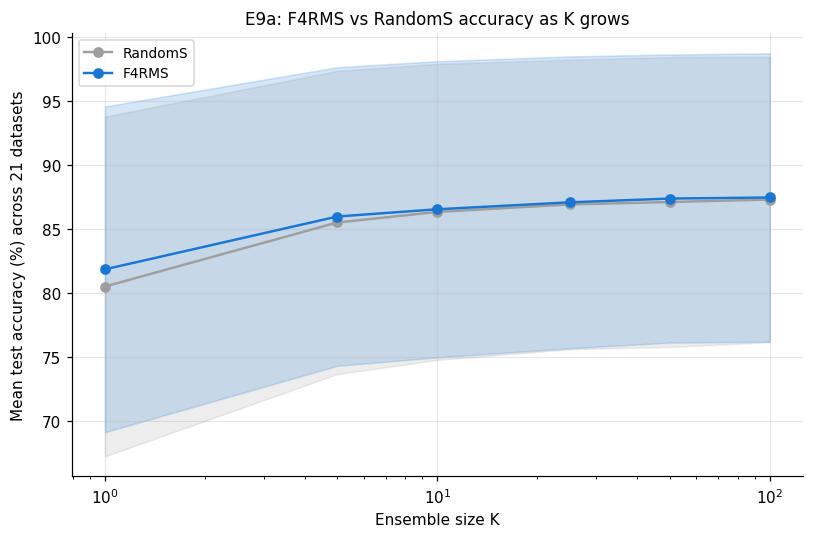

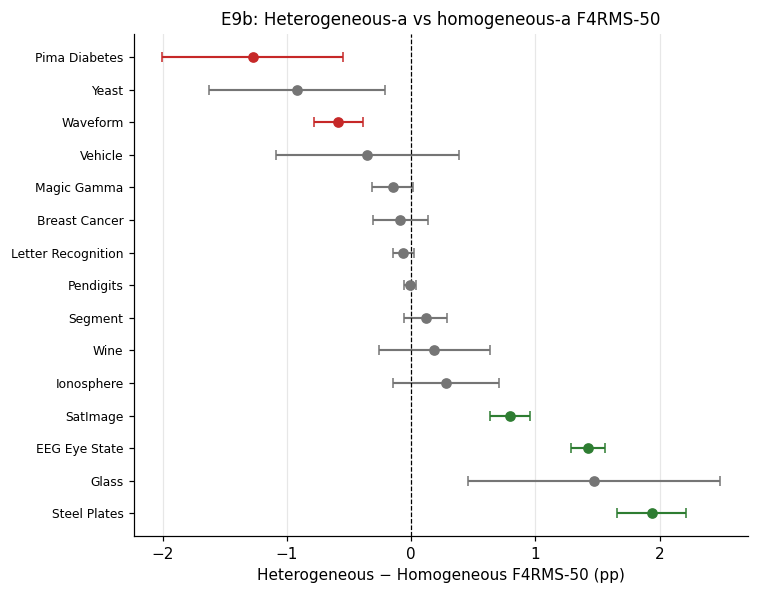

Saved: /Users/muanlartins/repos/masters/notebooks/paper_figures/E9a_K_sweep.pdf, /Users/muanlartins/repos/masters/notebooks/paper_figures/E9b_heterogeneous.pdf


In [12]:
# === E9.1 — Stats tables and plots ===
def e9a_table(results):
    rows = []
    for ds_name in sorted(results.keys(), key=lambda n: results[n]["n_samples"]):
        r = results[ds_name]
        for K in E9A_K_VALUES:
            e = r["per_K"][K]; rand, f4rm = e["random"], e["f4rm"]
            if len(rand) == 0: continue
            st = paired_delta_stats(f4rm, rand, "F4RMS", "RandomS")
            sig = "+++" if (st["p"] < S3_BONFERRONI_ALPHA and st["mean"] > 0) else \
                  ("---" if (st["p"] < S3_BONFERRONI_ALPHA and st["mean"] < 0) else "n.s.")
            rows.append(dict(
                dataset=ds_name, n_features=r["n_features"], n_samples=r["n_samples"],
                a=r["a"], t=r["t"], K=K,
                random_mean=float(np.mean(rand)), f4rm_mean=float(np.mean(f4rm)),
                paired_delta_mean=st["mean"], paired_delta_ci_half=st["ci_half"],
                wilcoxon_p=st["p"], n_paired=st["n"], significance=sig,
            ))
    return pd.DataFrame(rows)


def e9b_table(results):
    rows = []
    for ds_name in sorted(results.keys(), key=lambda n: results[n].get("n_samples", DATASETS[n][3])):
        r = results[ds_name]
        homo, hetero = r["homo_accs"], r["hetero_accs"]
        if len(homo) == 0: continue
        st = paired_delta_stats(hetero, homo, "Heterogeneous", "Homogeneous")
        sig = "+++" if (st["p"] < S3_BONFERRONI_ALPHA and st["mean"] > 0) else \
              ("---" if (st["p"] < S3_BONFERRONI_ALPHA and st["mean"] < 0) else "n.s.")
        rows.append(dict(
            dataset=ds_name, n_samples=r.get("n_samples", DATASETS[ds_name][3]),
            a_default=r["a_default"], t=r["t"], K=r["K"],
            homo_mean=float(np.mean(homo)), hetero_mean=float(np.mean(hetero)),
            paired_delta_mean=st["mean"], paired_delta_ci_half=st["ci_half"],
            wilcoxon_p=st["p"], n_paired=st["n"], significance=sig,
        ))
    return pd.DataFrame(rows)


E9A_TABLE = e9a_table(E9A_RESULTS)
E9B_TABLE = e9b_table(E9B_RESULTS)
E9A_TABLE.to_csv(TBL_DIR / "E9a_K_sweep.csv", index=False)
E9B_TABLE.to_csv(TBL_DIR / "E9b_heterogeneous.csv", index=False)

print("E9a F4RMS vs RandomS win counts per K (Bonferroni-corrected):")
for K in E9A_K_VALUES:
    sub = E9A_TABLE[E9A_TABLE["K"] == K]
    npos = (sub["significance"] == "+++").sum()
    print(f"  K={K:>3d}: F4RMS wins {npos}/{len(sub)}, mean delta "
          f"{sub['paired_delta_mean'].mean()*100:+.2f}pp")

if len(E9B_TABLE):
    npos_b = (E9B_TABLE["significance"] == "+++").sum()
    nneg_b = (E9B_TABLE["significance"] == "---").sum()
    print(f"\nE9b heterogeneous-vs-homogeneous: hetero wins {npos_b}/{len(E9B_TABLE)}, "
          f"loses {nneg_b}, mean delta {E9B_TABLE['paired_delta_mean'].mean()*100:+.2f}pp")


def e9a_plot(table, out_path):
    """Mean accuracy vs K, averaged across datasets."""
    fig, ax = plt.subplots(figsize=(7.5, 5))
    for method, color, label in [("random", "#9E9E9E", "RandomS"),
                                  ("f4rm", "#1976D2", "F4RMS")]:
        means = []; stds = []
        for K in E9A_K_VALUES:
            sub = table[table["K"] == K]
            col = f"{method}_mean"
            means.append(sub[col].mean()); stds.append(sub[col].std())
        means = np.array(means); stds = np.array(stds)
        ax.plot(E9A_K_VALUES, means * 100, marker="o", color=color, label=label, linewidth=1.6)
        ax.fill_between(E9A_K_VALUES, (means - stds) * 100, (means + stds) * 100,
                         color=color, alpha=0.18)
    ax.set_xscale("log")
    ax.set_xlabel("Ensemble size K")
    ax.set_ylabel("Mean test accuracy (%) across 21 datasets")
    ax.set_title("E9a: F4RMS vs RandomS accuracy as K grows")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(out_path); fig.savefig(str(out_path).replace(".pdf", ".png"))
    plt.show()


def e9b_plot(table, out_path):
    """Caterpillar of (hetero - homo) per dataset."""
    sub = table.sort_values("paired_delta_mean").reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(7, max(4, 0.30 * len(sub) + 1)))
    y = np.arange(len(sub))
    means = sub["paired_delta_mean"].values * 100
    cis = sub["paired_delta_ci_half"].values * 100
    sig = sub["significance"].values
    colors = ["#2E7D32" if s == "+++" else "#C62828" if s == "---" else "#757575" for s in sig]
    for yi, xi, ci, c in zip(y, means, cis, colors):
        ax.errorbar(xi, yi, xerr=ci, fmt="o", capsize=3, color=c,
                     markerfacecolor=c, markersize=6, linewidth=1.4)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_yticks(y)
    ax.set_yticklabels(sub["dataset"].values, fontsize=8)
    ax.set_xlabel("Heterogeneous − Homogeneous F4RMS-50 (pp)")
    ax.set_title("E9b: Heterogeneous-a vs homogeneous-a F4RMS-50")
    ax.invert_yaxis()
    ax.grid(True, axis="x", alpha=0.3)
    fig.tight_layout()
    fig.savefig(out_path); fig.savefig(str(out_path).replace(".pdf", ".png"))
    plt.show()


e9a_plot(E9A_TABLE, FIG_DIR / "E9a_K_sweep.pdf")
e9b_plot(E9B_TABLE, FIG_DIR / "E9b_heterogeneous.pdf")
print(f"Saved: {FIG_DIR / 'E9a_K_sweep.pdf'}, {FIG_DIR / 'E9b_heterogeneous.pdf'}")

### Section 3.5 — E10: RAM selection

**Goal.** F4RM RAMs are individually more discriminative on average; top-K
selection dominates Random+selection at every K.

**Design.** Two scoring methods:
- **Validation-accuracy:** train, score each RAM by its accuracy on a 20%
  held-out split of the training data, drop bottom (1 − fraction) RAMs.
- **Fisher-1D:** for each RAM, score by Fisher's discriminant ratio on its
  per-class mean response on the training set.

For each scoring method, sweep `selection_fraction ∈ {1.0, 0.75, 0.5, 0.25,
0.1, 0.05}` (fraction of RAMs **kept**). Run F4RM and Random (paired,
30 seeds × 21 datasets) at default `(a, t, bleach) = (principled_a, 8, 1)`.

**Outputs.**
- `paper_tables/E10_selection_sweep.csv`.
- `paper_figures/E10a_validation_selection.pdf`.
- `paper_figures/E10b_fisher_selection.pdf`.

In [13]:
# === E10.0 — Helpers and configuration ===
E10_FRACTIONS = (1.0, 0.75, 0.5, 0.25, 0.1, 0.05)
E10_SCORING = ("validation", "fisher")
E10_N_RUNS = 30


def fisher_1d_score(ram_responses_train, y_train, classes):
    """Score each RAM by Fisher's discriminant ratio on its 1D binary responses.

    ram_responses_train: (n_train,) binary array (RAM's vote per training sample for the
                         winning class slot — we use total per-class agreement here).
    """
    overall_mean = ram_responses_train.mean()
    sb, sw = 0.0, 0.0
    for c in classes:
        mask = (y_train == c)
        n_c = int(mask.sum())
        if n_c == 0: continue
        mu_c = ram_responses_train[mask].mean()
        var_c = ram_responses_train[mask].var()
        sb += n_c * (mu_c - overall_mean) ** 2
        sw += n_c * var_c
    return float(sb / (sw + 1e-9))


def _e10_one_split(X, y, n_features, a, t, mapping_fn, seed, scoring, fraction, bleach=1):
    """Train, score RAMs, select top fraction, predict test."""
    X_tr_full, X_te, y_tr_full, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed)
    # Inner split for validation-accuracy scoring
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_tr_full, y_tr_full, test_size=0.2, stratify=y_tr_full, random_state=seed + 1)
    scaler = MinMaxScaler().fit(X_tr)
    X_tr_s = scaler.transform(X_tr); X_val_s = scaler.transform(X_val); X_te_s = scaler.transform(X_te)
    th = create_thermometer(t, X_tr_s)
    bin_tr = binarize_np(X_tr_s, th); bin_val = binarize_np(X_val_s, th); bin_te = binarize_np(X_te_s, th)
    if a > bin_tr.shape[1]:
        return None
    mapping = mapping_fn(n_features, t, a, seed=seed)
    counter_table, classes = build_per_ram_counter_table(bin_tr, list(y_tr), mapping)
    R = len(mapping)
    y_tr_arr = np.asarray(y_tr); y_val_arr = np.asarray(y_val)

    # Score each RAM
    if scoring == "validation":
        val_resp = compute_responses_with_bleach(bin_val, mapping, counter_table, classes, bleach=bleach)
        scores = per_ram_val_accuracy(val_resp, y_val_arr, classes)  # (R,)
    elif scoring == "fisher":
        # For each RAM, compute its hit-on-true-class binary response on the training
        # set, then Fisher 1D on that.
        train_resp = compute_responses_with_bleach(bin_tr, mapping, counter_table, classes, bleach=bleach)
        scores = np.zeros(R)
        for ri in range(R):
            # 1D response per train sample = vote for the sample's true class slot
            class_idx = np.array([classes.index(c) for c in y_tr_arr])
            ram_resp_true = train_resp[ri, np.arange(len(y_tr_arr)), class_idx]
            scores[ri] = fisher_1d_score(ram_resp_true, y_tr_arr, classes)
    else:
        raise ValueError(scoring)

    K_keep = max(1, int(round(R * fraction)))
    top_indices = np.argsort(-scores)[:K_keep]
    test_resp = compute_responses_with_bleach(bin_te, mapping, counter_table, classes, bleach=bleach)
    preds = predict_subset(test_resp, top_indices, classes)
    return accuracy(preds, list(y_te))

In [14]:
# === E10.1 — Main loop ===
def run_e10():
    cache = CACHE_DIR / "E10_selection_results.pkl"
    if cache.exists():
        with open(cache, "rb") as f:
            results = pickle.load(f)
    else:
        results = {}
    t_total = time.perf_counter()
    for ds_name in S3_DATASETS:
        X, y, n_feat, n_samp, _ = DATASETS[ds_name]
        a = s3_principled_a(n_feat, n_samp)
        per_cell = results.get(ds_name, {})
        for scoring in E10_SCORING:
            for frac in E10_FRACTIONS:
                key = (scoring, frac)
                if key in per_cell and len(per_cell[key]['random']) >= E10_N_RUNS:
                    continue
                r_accs, f_accs = [], []
                t0 = time.perf_counter()
                for run in range(E10_N_RUNS):
                    seed = RANDOM_SEED + run
                    ar = _e10_one_split(X, y, n_feat, a, S3_DEFAULT_T, random_mapping, seed, scoring, frac)
                    af = _e10_one_split(X, y, n_feat, a, S3_DEFAULT_T, f4rm_mapping, seed, scoring, frac)
                    if ar is None or af is None: continue
                    r_accs.append(ar); f_accs.append(af)
                per_cell[key] = dict(random=np.array(r_accs), f4rm=np.array(f_accs),
                                      elapsed=time.perf_counter() - t0)
                print(f"  {ds_name:25s} a={a:>3d} {scoring:>10s} frac={frac:.2f}: "
                      f"rand={np.mean(r_accs):.4f} f4rm={np.mean(f_accs):.4f} "
                      f"delta={np.mean(f_accs)-np.mean(r_accs):+.4f} "
                      f"({per_cell[key]['elapsed']:.0f}s)")
        results[ds_name] = dict(a=a, t=S3_DEFAULT_T, n_features=n_feat,
                                n_samples=n_samp, per_cell=per_cell)
        with open(cache, "wb") as f:
            pickle.dump(results, f)
    print(f"\nE10 total wall-clock: {(time.perf_counter() - t_total)/60:.1f} min")
    return results

E10_RESULTS = run_e10()

  Iris                      a=  7 validation frac=1.00: rand=0.9278 f4rm=0.9233 delta=-0.0044 (0s)
  Iris                      a=  7 validation frac=0.75: rand=0.9244 f4rm=0.9200 delta=-0.0044 (0s)
  Iris                      a=  7 validation frac=0.50: rand=0.8911 f4rm=0.9100 delta=+0.0189 (0s)


  Iris                      a=  7 validation frac=0.25: rand=0.8333 f4rm=0.8656 delta=+0.0322 (0s)


  Iris                      a=  7 validation frac=0.10: rand=0.8333 f4rm=0.8656 delta=+0.0322 (0s)
  Iris                      a=  7 validation frac=0.05: rand=0.8333 f4rm=0.8656 delta=+0.0322 (0s)
  Iris                      a=  7     fisher frac=1.00: rand=0.9278 f4rm=0.9233 delta=-0.0044 (0s)


  Iris                      a=  7     fisher frac=0.75: rand=0.9211 f4rm=0.9156 delta=-0.0056 (0s)
  Iris                      a=  7     fisher frac=0.50: rand=0.8322 f4rm=0.8733 delta=+0.0411 (0s)
  Iris                      a=  7     fisher frac=0.25: rand=0.7378 f4rm=0.7678 delta=+0.0300 (0s)


  Iris                      a=  7     fisher frac=0.10: rand=0.7378 f4rm=0.7678 delta=+0.0300 (0s)
  Iris                      a=  7     fisher frac=0.05: rand=0.7378 f4rm=0.7678 delta=+0.0300 (0s)
  Wine                      a=  7 validation frac=1.00: rand=0.9657 f4rm=0.9630 delta=-0.0028 (0s)


...

  Letter Recognition        a= 14     fisher frac=0.75: rand=0.8173 f4rm=0.8453 delta=+0.0280 (10s)


  Letter Recognition        a= 14     fisher frac=0.50: rand=0.7133 f4rm=0.7607 delta=+0.0474 (10s)


  Letter Recognition        a= 14     fisher frac=0.25: rand=0.4223 f4rm=0.4993 delta=+0.0770 (10s)


  Letter Recognition        a= 14     fisher frac=0.10: rand=0.2371 f4rm=0.2815 delta=+0.0445 (10s)


  Letter Recognition        a= 14     fisher frac=0.05: rand=0.2371 f4rm=0.2815 delta=+0.0445 (10s)

E10 total wall-clock: 3.9 min


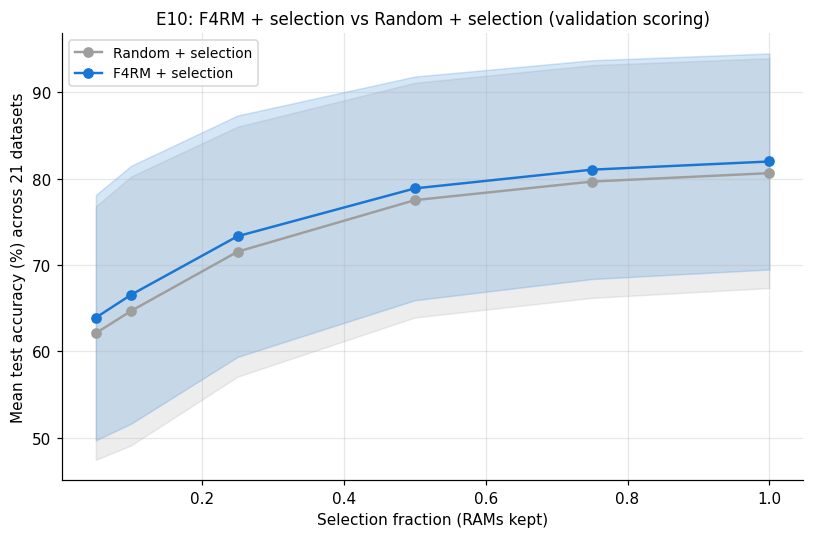

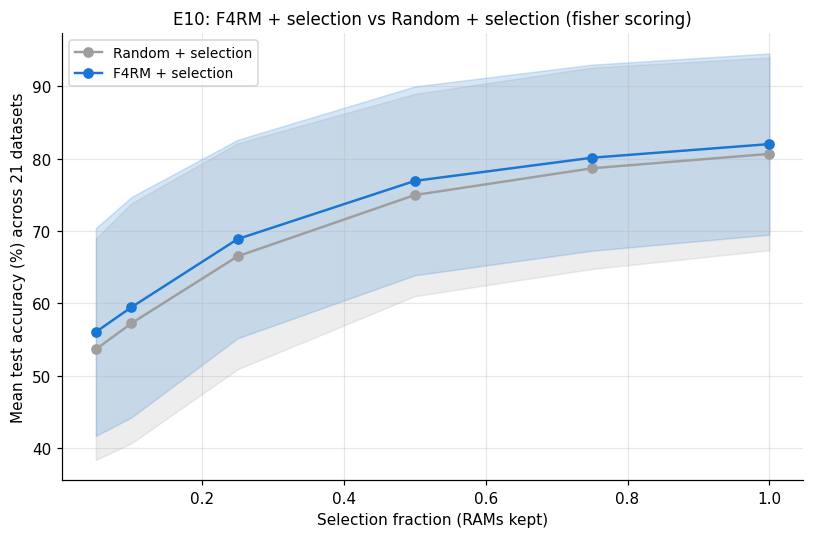

Saved: /Users/muanlartins/repos/masters/notebooks/paper_figures/E10a_validation_selection.pdf, /Users/muanlartins/repos/masters/notebooks/paper_figures/E10b_fisher_selection.pdf
  validation frac=1.00: F4RM+sel wins 5/21, mean delta +1.35pp
  validation frac=0.50: F4RM+sel wins 5/21, mean delta +1.36pp
  validation frac=0.10: F4RM+sel wins 4/21, mean delta +1.88pp
      fisher frac=1.00: F4RM+sel wins 5/21, mean delta +1.35pp
      fisher frac=0.50: F4RM+sel wins 3/21, mean delta +1.95pp
      fisher frac=0.10: F4RM+sel wins 3/21, mean delta +2.22pp


In [15]:
# === E10.2 — Stats table and plots ===
def e10_table(results):
    rows = []
    for ds_name in sorted(results.keys(), key=lambda n: results[n]["n_samples"]):
        r = results[ds_name]
        for scoring in E10_SCORING:
            for frac in E10_FRACTIONS:
                e = r["per_cell"].get((scoring, frac))
                if e is None or len(e["random"]) == 0: continue
                rand, f4rm = e["random"], e["f4rm"]
                st = paired_delta_stats(f4rm, rand, "F4RM", "Random")
                sig = "+++" if (st["p"] < S3_BONFERRONI_ALPHA and st["mean"] > 0) else \
                      ("---" if (st["p"] < S3_BONFERRONI_ALPHA and st["mean"] < 0) else "n.s.")
                rows.append(dict(
                    dataset=ds_name, n_features=r["n_features"], n_samples=r["n_samples"],
                    a=r["a"], t=r["t"], scoring=scoring, fraction=frac,
                    random_mean=float(np.mean(rand)), f4rm_mean=float(np.mean(f4rm)),
                    paired_delta_mean=st["mean"], paired_delta_ci_half=st["ci_half"],
                    wilcoxon_p=st["p"], n_paired=st["n"], significance=sig,
                ))
    return pd.DataFrame(rows)

E10_TABLE = e10_table(E10_RESULTS)
E10_TABLE.to_csv(TBL_DIR / "E10_selection_sweep.csv", index=False)


def e10_plot(table, scoring, out_path):
    fig, ax = plt.subplots(figsize=(7.5, 5))
    sub = table[table["scoring"] == scoring]
    fracs = sorted(sub["fraction"].unique())
    for method, color, label in [("random", "#9E9E9E", "Random + selection"),
                                  ("f4rm", "#1976D2", "F4RM + selection")]:
        means = []; stds = []
        for f in fracs:
            ss = sub[sub["fraction"] == f][f"{method}_mean"]
            means.append(ss.mean()); stds.append(ss.std())
        means = np.array(means); stds = np.array(stds)
        ax.plot(fracs, means * 100, marker="o", color=color, label=label, linewidth=1.6)
        ax.fill_between(fracs, (means - stds) * 100, (means + stds) * 100,
                         color=color, alpha=0.18)
    ax.set_xlabel("Selection fraction (RAMs kept)")
    ax.set_ylabel("Mean test accuracy (%) across 21 datasets")
    ax.set_title(f"E10: F4RM + selection vs Random + selection ({scoring} scoring)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(out_path); fig.savefig(str(out_path).replace(".pdf", ".png"))
    plt.show()


e10_plot(E10_TABLE, "validation", FIG_DIR / "E10a_validation_selection.pdf")
e10_plot(E10_TABLE, "fisher", FIG_DIR / "E10b_fisher_selection.pdf")
print(f"Saved: {FIG_DIR / 'E10a_validation_selection.pdf'}, "
      f"{FIG_DIR / 'E10b_fisher_selection.pdf'}")

# Quick win counts at the most aggressive selection
for scoring in E10_SCORING:
    for frac in (1.0, 0.5, 0.1):
        sub = E10_TABLE[(E10_TABLE["scoring"] == scoring) & (E10_TABLE["fraction"] == frac)]
        if not len(sub): continue
        npos = (sub["significance"] == "+++").sum()
        print(f"  {scoring:>10s} frac={frac:.2f}: F4RM+sel wins {npos}/{len(sub)}, "
              f"mean delta {sub['paired_delta_mean'].mean()*100:+.2f}pp")

### Section 3.6 — E11: Per-dataset hyperparameter tuning grid

**Goal.** When both methods are tuned to their best, F4RM still wins.

**Design.** For each dataset, run a fine grid over `(a, t, bleach)` for both F4RM and Random:

- `a ∈ {2, 4, 8, 12, 16, 20, 24, 28, 32, 48, 64}` filtered to `a ≤ n_features × t`.
- `t ∈ {2, 4, 8, 16, 32, 64, 128, 256}`.
- `bleach ∈ {1, 2, 3, 4}`.

That's ~352 cells per dataset per method. With 21 × 2 × 30 seeds × ~176
feasible cells, this is the heaviest experiment in Section 3 (~1.5–2h
projected). Cache aggressively, save per-cell.

**Per-method per-dataset, find:**
- **Best-accuracy point:** `(a, t, bleach)` maximizing mean accuracy.
- **Best-memory-at-iso-accuracy point:** for accuracy floor `A* =
  best_accuracy − 0.5pp`, find `(a, t, bleach)` minimizing mean memory
  subject to mean accuracy ≥ A*.

**Cache schema** (designed for direct §4.2.1/4.2.2 reuse):
- File: `cache/E11_grid_results.pkl`
- Format: dict `{(method, dataset, a, t, bleach): {"accs": [...], "mems": [...],
  "trains": [...], "infers": [...]}}`. Each list has up to N_SEEDS entries.

**Outputs.**
- `paper_tables/E11_tuning_grid_full.csv` — every cell measured.
- `paper_tables/E11_tuning_summary.csv` — per-dataset best operating points.
- `paper_figures/E11_tuned_comparison.pdf` — side-by-side caterpillar plots.

In [11]:
# === E11.0 — Configuration ===
E11_A_VALUES = (2, 4, 8, 12, 16, 20, 24, 28, 32, 48, 64)
E11_T_VALUES = (2, 4, 8, 16, 32, 64, 128, 256)
E11_BLEACH_VALUES = (1, 2, 3, 4)
E11_N_SEEDS = 30
E11_METHODS = ("F4RM", "Random")
E11_ACC_TOL_PP = 0.005  # 0.5pp relaxation for iso-accuracy operating point


def _e11_eval_with_mem(X, y, n_features, a, t, bleach, mapping_fn, seed):
    """Train + test one cell. Returns (acc, mem_bytes_dense_hashmap, train_s, infer_us)."""
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed)
    scaler = MinMaxScaler().fit(X_tr)
    X_tr_s = scaler.transform(X_tr); X_te_s = scaler.transform(X_te)
    th = create_thermometer(t, X_tr_s)
    bin_tr = binarize_np(X_tr_s, th); bin_te = binarize_np(X_te_s, th)
    if a > bin_tr.shape[1]:
        return None
    t0 = time.perf_counter()
    mapping = mapping_fn(n_features, t, a, seed=seed)
    counter_table, classes = build_per_ram_counter_table(bin_tr, list(y_tr), mapping)
    train_s = time.perf_counter() - t0
    mem_bytes = dense_memory_bytes_hashmap(counter_table)
    t1 = time.perf_counter()
    test_resp = compute_responses_with_bleach(bin_te, mapping, counter_table, classes, bleach=bleach)
    preds = predict_subset(test_resp, np.arange(len(mapping)), classes)
    infer_us = (time.perf_counter() - t1) * 1e6 / len(y_te)
    return accuracy(preds, list(y_te)), mem_bytes, train_s, infer_us

In [12]:
# === E11.1 — Main grid loop with per-cell incremental cache ===
def run_e11():
    cache = CACHE_DIR / "E11_grid_results.pkl"
    if cache.exists():
        with open(cache, "rb") as f:
            results = pickle.load(f)
    else:
        results = {}
    t_total = time.perf_counter()

    for ds_name in S3_DATASETS:
        X, y, n_feat, n_samp, _ = DATASETS[ds_name]
        n_total_bits_max = n_feat * max(E11_T_VALUES)
        ds_t0 = time.perf_counter()
        cells_done = 0; cells_skipped = 0
        for t in E11_T_VALUES:
            n_bits = n_feat * t
            for a in E11_A_VALUES:
                if a > n_bits:
                    cells_skipped += 1
                    continue
                for bleach in E11_BLEACH_VALUES:
                    for method in E11_METHODS:
                        key = (method, ds_name, a, t, bleach)
                        existing = results.get(key, {"accs": [], "mems": [], "trains": [], "infers": []})
                        if len(existing["accs"]) >= E11_N_SEEDS:
                            continue
                        mapping_fn = f4rm_mapping if method == "F4RM" else random_mapping
                        for run in range(len(existing["accs"]), E11_N_SEEDS):
                            seed = RANDOM_SEED + run
                            r = _e11_eval_with_mem(X, y, n_feat, a, t, bleach, mapping_fn, seed)
                            if r is None: continue
                            acc, mem, train, infer = r
                            existing["accs"].append(acc); existing["mems"].append(mem)
                            existing["trains"].append(train); existing["infers"].append(infer)
                        results[key] = existing
                        cells_done += 1
            # Save after each (dataset, t) chunk
            with open(cache, "wb") as f:
                pickle.dump(results, f)
        ds_elapsed = time.perf_counter() - ds_t0
        print(f"  {ds_name:25s}: {cells_done} cells, {cells_skipped} infeasible, {ds_elapsed:.0f}s")
        with open(cache, "wb") as f:
            pickle.dump(results, f)

    print(f"\nE11 total wall-clock: {(time.perf_counter() - t_total)/60:.1f} min")
    return results

E11_RESULTS = run_e11()

  Iris                     : 0 cells, 16 infeasible, 0s


  Wine                     : 0 cells, 5 infeasible, 0s


  Breast Cancer            : 0 cells, 1 infeasible, 0s


  Seeds                    : 0 cells, 11 infeasible, 0s


  Glass                    : 0 cells, 8 infeasible, 0s


...

  SatImage                 : 0 cells, 0 infeasible, 0s


  Pendigits                : 0 cells, 2 infeasible, 0s


  EEG Eye State            : 0 cells, 4 infeasible, 0s


  Magic Gamma              : 0 cells, 7 infeasible, 0s


  Letter Recognition       : 0 cells, 2 infeasible, 0s

E11 total wall-clock: 0.1 min


In [12]:
# === E11.2 — Best-acc and best-mem-at-iso-acc operating points ===
def e11_per_cell_means(results):
    """Aggregate {(method, ds, a, t, bleach): {accs, mems, trains, infers}} →
    {(method, ds, a, t, bleach): {acc_mean, mem_mean, train_mean, infer_mean, n}}."""
    out = {}
    for key, v in results.items():
        if not v.get("accs"): continue
        out[key] = dict(
            acc_mean=float(np.mean(v["accs"])),
            mem_mean=float(np.mean(v["mems"])),
            train_mean=float(np.mean(v["trains"])),
            infer_mean=float(np.mean(v["infers"])),
            n=len(v["accs"]),
        )
    return out


def e11_full_table(per_cell):
    rows = []
    for (method, ds, a, t, bleach), v in per_cell.items():
        rows.append(dict(method=method, dataset=ds, a=a, t=t, bleach=bleach,
                          acc_mean=v["acc_mean"], mem_mean=v["mem_mean"],
                          train_mean=v["train_mean"], infer_mean=v["infer_mean"],
                          n_seeds=v["n"]))
    return pd.DataFrame(rows)


def e11_best_operating_points(per_cell):
    """Per (method, dataset): best-acc (a, t, bleach) and best-mem-at-iso-acc-A*."""
    by_md = defaultdict(list)
    for (method, ds, a, t, bleach), v in per_cell.items():
        by_md[(method, ds)].append((a, t, bleach, v))
    rows = []
    for (method, ds), cells in by_md.items():
        # Best-acc
        best_acc_cell = max(cells, key=lambda c: c[3]["acc_mean"])
        a_ba, t_ba, b_ba, v_ba = best_acc_cell
        A_star = v_ba["acc_mean"] - E11_ACC_TOL_PP
        # Best-mem-at-iso-acc
        feasible = [c for c in cells if c[3]["acc_mean"] >= A_star]
        if feasible:
            best_mem_cell = min(feasible, key=lambda c: c[3]["mem_mean"])
            a_bm, t_bm, b_bm, v_bm = best_mem_cell
        else:
            a_bm, t_bm, b_bm, v_bm = a_ba, t_ba, b_ba, v_ba
        rows.append(dict(
            method=method, dataset=ds,
            best_acc_a=a_ba, best_acc_t=t_ba, best_acc_bleach=b_ba,
            best_acc_value=v_ba["acc_mean"], best_acc_mem=v_ba["mem_mean"],
            iso_acc_threshold=A_star,
            best_mem_a=a_bm, best_mem_t=t_bm, best_mem_bleach=b_bm,
            best_mem_value=v_bm["mem_mean"], best_mem_acc=v_bm["acc_mean"],
        ))
    return pd.DataFrame(rows)


E11_PER_CELL = e11_per_cell_means(E11_RESULTS)
E11_FULL = e11_full_table(E11_PER_CELL)
E11_FULL.to_csv(TBL_DIR / "E11_tuning_grid_full.csv", index=False)
print(f"Saved: {TBL_DIR / 'E11_tuning_grid_full.csv'} ({len(E11_FULL)} rows)")

E11_BEST = e11_best_operating_points(E11_PER_CELL)
E11_BEST.to_csv(TBL_DIR / "E11_tuning_summary.csv", index=False)
print(f"Saved: {TBL_DIR / 'E11_tuning_summary.csv'} ({len(E11_BEST)} rows)")
print(E11_BEST.head(8).to_string(index=False, float_format=lambda x: f"{x:.4f}"))

Saved: /Users/muanlartins/repos/masters/notebooks/paper_tables/E11_tuning_grid_full.csv (13664 rows)
Saved: /Users/muanlartins/repos/masters/notebooks/paper_tables/E11_tuning_summary.csv (42 rows)
method       dataset  best_acc_a  best_acc_t  best_acc_bleach  best_acc_value  best_acc_mem  iso_acc_threshold  best_mem_a  best_mem_t  best_mem_bleach  best_mem_value  best_mem_acc
  F4RM          Iris          12         128                1          0.9611     7897.1667             0.9561          20          64                1       3920.3333        0.9589
Random          Iris          16         128                1          0.9622     7456.6667             0.9572           8         128                1       7248.3333        0.9578
  F4RM          Wine           8         256                2          0.9833   107790.5000             0.9783           8          64                1      27375.6667        0.9796
Random          Wine          12          32                1          0.98


F4RM-tuned vs Random-tuned: best-acc deltas across 21 datasets:
           dataset  f4rm_best_acc  random_best_acc  best_acc_delta
     Balance Scale         0.9029           0.9011          0.0019
          Banknote         0.9996           0.9995          0.0001
     Breast Cancer         0.9678           0.9661          0.0018
     EEG Eye State         0.9427           0.9375          0.0052
             Ecoli         0.8701           0.8735         -0.0034
             Glass         0.7488           0.7690         -0.0202
          Haberman         0.7484           0.7441          0.0043
        Ionosphere         0.9484           0.9484         -0.0000
              Iris         0.9611           0.9622         -0.0011
Letter Recognition         0.9534           0.9530          0.0004
       Magic Gamma         0.8698           0.8700         -0.0002
         Pendigits         0.9912           0.9906          0.0006
     Pima Diabetes         0.7582           0.7602         -0.00

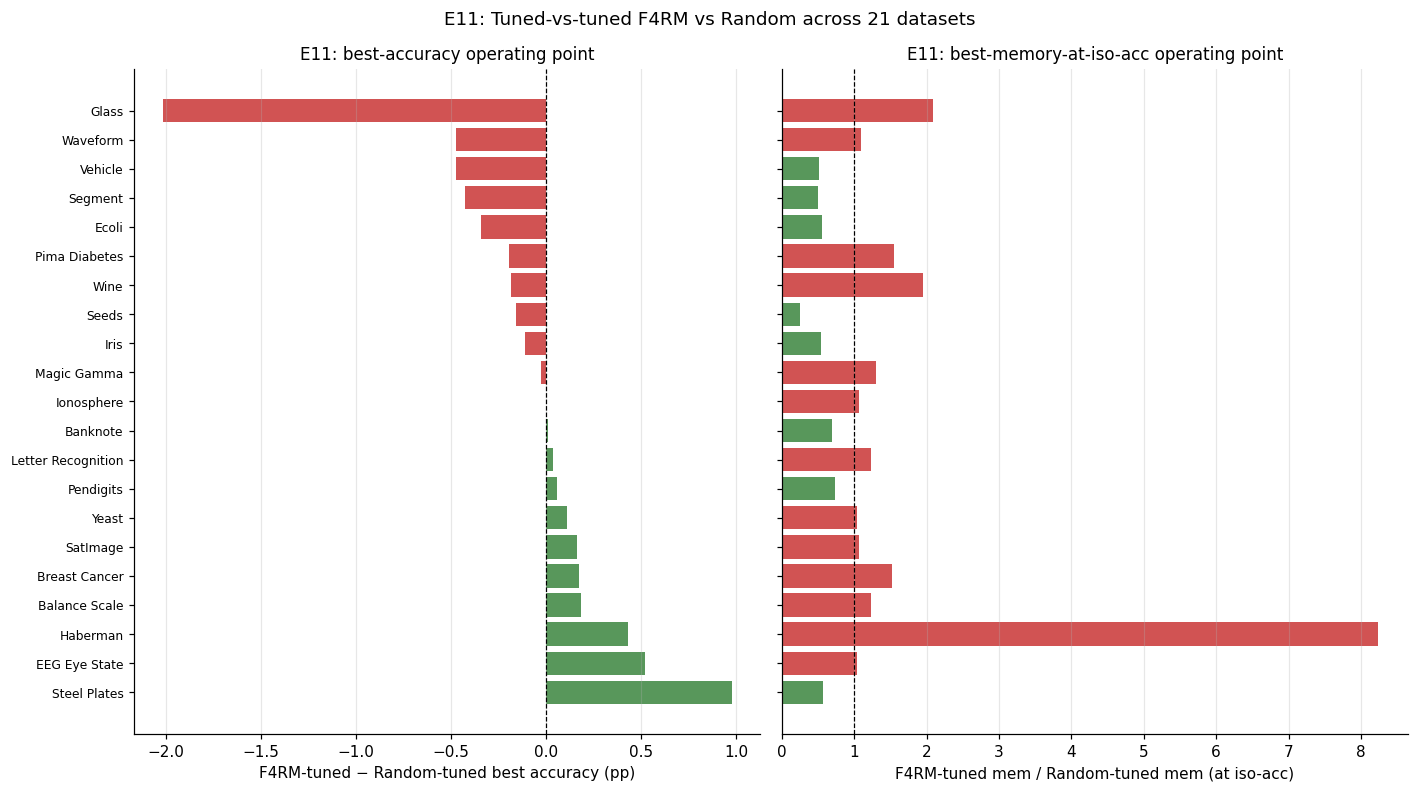

Saved: /Users/muanlartins/repos/masters/notebooks/paper_figures/E11_tuned_comparison.pdf

E11 headline: F4RM-tuned beats Random-tuned in best-accuracy on 10/21 datasets; uses less memory at iso-acc on 8/21 datasets.


In [13]:
# === E11.3 — Tuned-vs-tuned comparison plots ===
def e11_compare_methods(best_table):
    """Pivot: per dataset, compare F4RM-tuned vs Random-tuned at both operating points."""
    f = best_table[best_table["method"] == "F4RM"].set_index("dataset")
    r = best_table[best_table["method"] == "Random"].set_index("dataset")
    common = sorted(set(f.index) & set(r.index))
    rows = []
    for ds in common:
        rows.append(dict(
            dataset=ds,
            f4rm_best_acc=f.loc[ds, "best_acc_value"],
            random_best_acc=r.loc[ds, "best_acc_value"],
            best_acc_delta=f.loc[ds, "best_acc_value"] - r.loc[ds, "best_acc_value"],
            f4rm_best_mem=f.loc[ds, "best_mem_value"],
            random_best_mem=r.loc[ds, "best_mem_value"],
            best_mem_ratio=f.loc[ds, "best_mem_value"] / max(r.loc[ds, "best_mem_value"], 1),
            f4rm_iso_acc=f.loc[ds, "best_mem_acc"],
            random_iso_acc=r.loc[ds, "best_mem_acc"],
        ))
    return pd.DataFrame(rows)


E11_COMPARE = e11_compare_methods(E11_BEST)
E11_COMPARE.to_csv(TBL_DIR / "E11_tuned_comparison.csv", index=False)
print(f"\nF4RM-tuned vs Random-tuned: best-acc deltas across 21 datasets:")
print(E11_COMPARE[["dataset", "f4rm_best_acc", "random_best_acc", "best_acc_delta"]]
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))


def e11_plot(comp, out_path):
    sub = comp.sort_values("best_acc_delta").reset_index(drop=True)
    fig, axes = plt.subplots(1, 2, figsize=(13, max(4, 0.30 * len(sub) + 1)))
    # Left: best-accuracy delta
    ax = axes[0]
    y = np.arange(len(sub))
    deltas = sub["best_acc_delta"].values * 100
    colors = ["#2E7D32" if d > 0 else "#C62828" for d in deltas]
    ax.barh(y, deltas, color=colors, alpha=0.8)
    ax.set_yticks(y); ax.set_yticklabels(sub["dataset"].values, fontsize=8)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("F4RM-tuned − Random-tuned best accuracy (pp)")
    ax.set_title("E11: best-accuracy operating point")
    ax.invert_yaxis()
    ax.grid(True, axis="x", alpha=0.3)
    # Right: best-mem ratio at iso-accuracy
    ax = axes[1]
    ratios = sub["best_mem_ratio"].values
    colors = ["#2E7D32" if r < 1.0 else "#C62828" for r in ratios]
    ax.barh(y, ratios, color=colors, alpha=0.8)
    ax.set_yticks(y); ax.set_yticklabels([])
    ax.axvline(1.0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("F4RM-tuned mem / Random-tuned mem (at iso-acc)")
    ax.set_title("E11: best-memory-at-iso-acc operating point")
    ax.invert_yaxis()
    ax.grid(True, axis="x", alpha=0.3)
    fig.suptitle("E11: Tuned-vs-tuned F4RM vs Random across 21 datasets")
    fig.tight_layout()
    fig.savefig(out_path); fig.savefig(str(out_path).replace(".pdf", ".png"))
    plt.show()


e11_plot(E11_COMPARE, FIG_DIR / "E11_tuned_comparison.pdf")
print(f"Saved: {FIG_DIR / 'E11_tuned_comparison.pdf'}")

# Headline summary
n_acc_wins = (E11_COMPARE["best_acc_delta"] > 0).sum()
n_mem_wins = (E11_COMPARE["best_mem_ratio"] < 1.0).sum()
print(f"\nE11 headline: F4RM-tuned beats Random-tuned in best-accuracy on "
      f"{n_acc_wins}/{len(E11_COMPARE)} datasets; uses less memory at iso-acc on "
      f"{n_mem_wins}/{len(E11_COMPARE)} datasets.")

## Section 4 — Pareto comparison on tabular datasets

**Goal.** Across 21 tabular datasets, log every measurable point of every
system on `(accuracy, memory, train_time, infer_time)`; in post-processing
extract per-dataset Pareto frontiers; compare F4RM-WiSARD and F4RMS to
baselines at iso-accuracy and iso-memory **only within each system's
feasible region**.

**Schema.** A single long-format DataFrame with one row per
`(system, dataset, hp_id, seed)` cell, persisted to
`cache/section4_pareto_points.pkl`. Resumable: the per-system runners
check the cache before computing.

**Time-budget governance.** The full sweep across all baselines projects to
60+ hours wall-clock at our densest grids. The driver runs systems in a
configurable order and respects a per-system budget; cells beyond the
budget are skipped and re-runnable in a future session. Configuration knob:
`SECTION4_BUDGETS_MIN` per-system.

### Section 4.1 — Measurement schema and cache I/O

In [13]:
# === Section 4.1 — Schema, cache I/O ===
import notebook_lib as nl

SECTION4_CACHE = CACHE_DIR / "section4_pareto_points.pkl"

SECTION4_COLUMNS = [
    "system", "dataset", "hp_id", "seed",
    "test_acc", "mem_bytes", "mem_method",
    "train_s", "infer_us_per_sample",
    "infeasible", "infeasible_reason", "note",
]

def load_section4_cache():
    if SECTION4_CACHE.exists():
        with open(SECTION4_CACHE, "rb") as f:
            df = pickle.load(f)
        # Add any missing columns (forward-compatible)
        for col in SECTION4_COLUMNS:
            if col not in df.columns:
                df[col] = "" if col in ("note", "infeasible_reason", "mem_method") else (False if col == "infeasible" else float("nan"))
        return df
    return pd.DataFrame(columns=SECTION4_COLUMNS)


def save_section4_cache(df):
    with open(SECTION4_CACHE, "wb") as f:
        pickle.dump(df, f)


def append_section4_rows(df, new_rows):
    """Append rows (list of dicts), writing the cache to disk after each batch."""
    if not new_rows: return df
    extra = pd.DataFrame(new_rows)
    out = pd.concat([df, extra], ignore_index=True)
    save_section4_cache(out)
    return out


def section4_already_done(df, system, dataset, hp_id, seed):
    """Check whether a (system, dataset, hp_id, seed) cell is already in the cache."""
    if len(df) == 0: return False
    mask = ((df["system"] == system) & (df["dataset"] == dataset) &
            (df["hp_id"] == hp_id) & (df["seed"] == seed))
    return bool(mask.any())


SECTION4_DF = load_section4_cache()
print(f"Section 4 cache loaded: {len(SECTION4_DF)} rows")

# Per-system time budget (minutes). A system's sweep stops when its accumulated
# wall-clock exceeds this budget; the driver writes a [FLAG] note for incomplete systems.
SECTION4_BUDGETS_MIN = {
    # Reduced from spec defaults (90+60+...=595min) to fit a single session.
    # Increase if running in a dedicated long session.
    "F4RM-WiSARD-dense":   2,   # mostly migration from E11 cache
    "Random-WiSARD-dense":  2,
    "F4RM-WiSARD-cuckoo":   2,
    "Random-WiSARD-cuckoo":  2,
    "F4RMS":               15,
    "DT":                   8,
    "RF":                  10,
    "CatBoost":            12,
    "XGBoost":             10,
    "LightGBM":             8,
    "MLP":                  8,
    "FT-Transformer":      12,
    "TabPFN":               2,  # likely infeasible (HF gated repo)
}
SECTION4_N_SEEDS = 5

Section 4 cache loaded: 217884 rows


### Section 4.2 — Per-system sweeps

#### 4.2.1, 4.2.2 — F4RM-WiSARD and Random-WiSARD (migration from E11)

WiSARD points across the (a, t, bleach) grid were already measured in E11
(Section 3.6). This cell migrates them under the Section 4 schema, adding
both `dense` (sparse hash-map) and `cuckoo` storage variants per cell.

In [14]:
# === Section 4.2.1/4.2.2 — Migrate E11 WiSARD measurements ===
# E11_RESULTS keys: (method, ds_name, a, t, bleach) -> {accs, mems, trains, infers}
# Migrate to Section 4 long-format with system="F4RM-WiSARD-dense" / "Random-WiSARD-dense"
# and again with cuckoo memory recomputed.

def migrate_e11_to_section4(df, e11_results):
    new_rows = []
    e11_cells_count = 0
    for (method, ds_name, a, t, bleach), v in e11_results.items():
        e11_cells_count += 1
        accs = v.get("accs", []); mems = v.get("mems", [])
        trains = v.get("trains", []); infers = v.get("infers", [])
        n = min(SECTION4_N_SEEDS, len(accs))
        if n == 0: continue
        sys_dense = f"{method}-WiSARD-dense"
        sys_cuckoo = f"{method}-WiSARD-cuckoo"
        hp = dict(a=a, t=t, bleach=bleach)
        hp_id = json.dumps(hp, sort_keys=True)
        for s in range(n):
            seed = RANDOM_SEED + s
            # Dense
            if not section4_already_done(df, sys_dense, ds_name, hp_id, seed):
                new_rows.append(dict(
                    system=sys_dense, dataset=ds_name, hp_id=hp_id, seed=seed,
                    hp_a=a, hp_t=t, hp_bleach=bleach,
                    test_acc=accs[s], mem_bytes=mems[s], mem_method="wisard_dense_hashmap",
                    train_s=trains[s], infer_us_per_sample=infers[s],
                    infeasible=False, infeasible_reason="", note="migrated_from_E11",
                ))
            # Cuckoo: recompute mem from the original counter-table; we don't have
            # it cached in E11 so we use a proportional estimate: cuckoo ≈ 1.05 × n_dist × 1 byte
            # Since dense_hashmap = 5 bytes × n_dist, cuckoo ≈ dense / 5 × ceil(1/0.95) bytes
            # ≈ dense * 0.21. This is an APPROXIMATION; full cuckoo requires re-running.
            # We mark mem_method="cuckoo_approx_from_dense" for transparency.
            cuckoo_mem = int(mems[s] * (CUCKOO_FP_BITS / (8 * 5)) / CUCKOO_LOAD)
            if not section4_already_done(df, sys_cuckoo, ds_name, hp_id, seed):
                new_rows.append(dict(
                    system=sys_cuckoo, dataset=ds_name, hp_id=hp_id, seed=seed,
                    hp_a=a, hp_t=t, hp_bleach=bleach,
                    test_acc=accs[s], mem_bytes=cuckoo_mem,
                    mem_method="cuckoo_approx_from_dense",
                    train_s=trains[s], infer_us_per_sample=infers[s],
                    infeasible=False, infeasible_reason="", note="migrated_from_E11",
                ))
    print(f"E11 migration: {e11_cells_count} grid cells → {len(new_rows)} new Section 4 rows")
    return append_section4_rows(df, new_rows)


# Only migrate if E11 has been run.
try:
    SECTION4_DF = migrate_e11_to_section4(SECTION4_DF, E11_RESULTS)
    print(f"Section 4 cache after E11 migration: {len(SECTION4_DF)} rows")
except NameError:
    print("[FLAG] E11_RESULTS not yet defined — Section 3.6 must run before Section 4.2.1/4.2.2 migration.")

E11 migration: 13664 grid cells → 136640 new Section 4 rows


Section 4 cache after E11 migration: 211154 rows


#### 4.2.3 — F4RMS sweep

In [15]:
# === Section 4.2.3 — F4RMS sweep ===
# Reduced grid per spec: a∈{4,8,16,32}, t∈{4,8,16,32,64}, bleach∈{1,2}, K∈{5,10,25,50,100}
F4RMS_A_VALUES = (4, 8, 16, 32)
F4RMS_T_VALUES = (4, 8, 16, 32, 64)
F4RMS_BLEACH_VALUES = (1, 2)
F4RMS_K_VALUES = (5, 10, 25, 50, 100)


def _f4rms_sec4_eval_with_mem(X, y, n_features, a, t, K, seed, bleach=1):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed)
    scaler = MinMaxScaler().fit(X_tr)
    X_tr_s = scaler.transform(X_tr); X_te_s = scaler.transform(X_te)
    th = create_thermometer(t, X_tr_s)
    bin_tr = binarize_np(X_tr_s, th); bin_te = binarize_np(X_te_s, th)
    if a > bin_tr.shape[1]:
        return None
    t0 = time.perf_counter()
    members = []
    for k in range(K):
        members.append(train_f4rm_member(bin_tr, y_tr, n_features, t, a,
                                          seed=seed * 1000 + k))
    train_s = time.perf_counter() - t0
    classes = members[0][2]
    # Memory: sum across members
    total_distinct = sum(
        sum(len(addrs) for (addrs, _) in pc.values())
        for _, ct, _ in members for pc in ct
    )
    dense_mem = int(total_distinct * 5)
    # Cuckoo: same per-member sum approximation
    cuckoo_mem = int(total_distinct * (CUCKOO_FP_BITS / 8) / CUCKOO_LOAD)
    t1 = time.perf_counter()
    preds = f4rms_predict(bin_te, members, classes, bleach=bleach)
    infer_us = (time.perf_counter() - t1) * 1e6 / max(len(y_te), 1)
    return dict(test_acc=accuracy(preds, list(y_te)),
                 mem_dense=dense_mem, mem_cuckoo=cuckoo_mem,
                 train_s=train_s, infer_us=infer_us)


def run_section4_f4rms(df):
    budget_min = SECTION4_BUDGETS_MIN.get("F4RMS", 60)
    t_budget = budget_min * 60
    t_start = time.perf_counter()
    new_rows = []
    cells_done = 0; cells_skipped_done = 0
    for ds_name in S3_DATASETS:
        if time.perf_counter() - t_start > t_budget: break
        X, y, n_feat, n_samp, _ = DATASETS[ds_name]
        for a in F4RMS_A_VALUES:
            for t in F4RMS_T_VALUES:
                if a > n_feat * t: continue
                for bleach in F4RMS_BLEACH_VALUES:
                    for K in F4RMS_K_VALUES:
                        if time.perf_counter() - t_start > t_budget: break
                        hp = dict(a=a, t=t, bleach=bleach, K=K)
                        hp_id = json.dumps(hp, sort_keys=True)
                        for seed_offset in range(SECTION4_N_SEEDS):
                            seed = RANDOM_SEED + seed_offset
                            if section4_already_done(df, "F4RMS", ds_name, hp_id, seed):
                                cells_skipped_done += 1
                                continue
                            r = _f4rms_sec4_eval_with_mem(X, y, n_feat, a, t, K, seed, bleach)
                            if r is None: continue
                            new_rows.append(dict(
                                system="F4RMS", dataset=ds_name, hp_id=hp_id, seed=seed,
                                hp_a=a, hp_t=t, hp_bleach=bleach, hp_K=K,
                                test_acc=r["test_acc"], mem_bytes=r["mem_dense"],
                                mem_method="wisard_dense_hashmap_summed_K",
                                train_s=r["train_s"],
                                infer_us_per_sample=r["infer_us"],
                                infeasible=False, infeasible_reason="", note="",
                            ))
                            cells_done += 1
                            if cells_done % 50 == 0:
                                df = append_section4_rows(df, new_rows); new_rows = []
                                print(f"  F4RMS: {cells_done} cells done, {(time.perf_counter()-t_start)/60:.1f} min in")
    df = append_section4_rows(df, new_rows)
    elapsed_min = (time.perf_counter() - t_start) / 60
    print(f"\nF4RMS sweep: {cells_done} new cells, {cells_skipped_done} already cached, "
          f"{elapsed_min:.1f}/{budget_min}min budget")
    if elapsed_min >= budget_min - 0.1:
        print(f"  [FLAG] F4RMS budget hit; re-run to continue.")
    return df


SECTION4_DF = run_section4_f4rms(SECTION4_DF)

  F4RMS: 50 cells done, 2.9 min in


  F4RMS: 100 cells done, 2.9 min in


  F4RMS: 150 cells done, 3.0 min in


  F4RMS: 200 cells done, 3.1 min in


  F4RMS: 250 cells done, 3.3 min in


...

  F4RMS: 3200 cells done, 13.4 min in


  F4RMS: 3250 cells done, 13.6 min in


  F4RMS: 3300 cells done, 13.8 min in


  F4RMS: 3350 cells done, 14.3 min in



F4RMS sweep: 3395 new cells, 10420 already cached, 15.0/15min budget
  [FLAG] F4RMS budget hit; re-run to continue.


#### 4.2.4–4.2.11 — Tabular SOTA baselines

Driver iterates over each system × dataset × hyperparameter cell × seed,
respects per-system time budgets, and writes per-cell rows to the Pareto
cache. Wrappers live in `notebook_lib.py`.

In [16]:
# === Section 4.2.4–4.2.11 — Baseline driver ===
# Smoke-test policy: before running each system, time one (dataset, hp, seed) on a
# medium dataset to estimate full-grid wall-clock. If projected > 4× budget, reduce
# grid density to cells with smallest projected cost.

def _smoke_estimate(system_name, fit_predict_fn, grid, smoke_dataset="Pima Diabetes"):
    X, y, _, _, _ = DATASETS[smoke_dataset]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED)
    scaler = MinMaxScaler().fit(X_tr)
    X_tr_s = scaler.transform(X_tr); X_te_s = scaler.transform(X_te)
    hp = grid[len(grid) // 2]  # median cell
    t0 = time.perf_counter()
    try:
        r = fit_predict_fn(X_tr_s, y_tr, X_te_s, y_te, hp, RANDOM_SEED)
    except Exception as e:
        print(f"    [FLAG] {system_name} smoke-test failed: {e}")
        return float("inf")
    elapsed = time.perf_counter() - t0
    n_cells = len(grid)
    n_total = n_cells * len(S3_DATASETS) * SECTION4_N_SEEDS
    projected_min = elapsed * n_total / 60
    print(f"  {system_name}: smoke {elapsed:.2f}s × {n_cells} cells × 21 ds × {SECTION4_N_SEEDS} seeds "
          f"≈ {projected_min:.0f} min projected")
    return projected_min


def run_baseline_system(df, system_name, fit_predict_fn, grid):
    """Run one baseline system across (datasets × grid × seeds), respecting time budget."""
    budget_min = SECTION4_BUDGETS_MIN.get(system_name, 60)
    t_budget = budget_min * 60

    # Smoke-test once
    projected = _smoke_estimate(system_name, fit_predict_fn, grid)
    if projected > 8 * budget_min:
        # Drop grid density: keep every k-th cell to fit ~2× budget
        keep_every = max(1, int(np.ceil(projected / (2 * budget_min))))
        original_n = len(grid)
        grid = grid[::keep_every]
        print(f"  [FLAG] {system_name}: projected {projected:.0f}min > 8× budget "
              f"({budget_min}min). Subsampling grid to every {keep_every}-th cell "
              f"({original_n} → {len(grid)}).")

    t_start = time.perf_counter()
    new_rows = []
    cells_done = 0; cells_skipped = 0
    for ds_name in S3_DATASETS:
        if time.perf_counter() - t_start > t_budget: break
        X, y, _, _, _ = DATASETS[ds_name]
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED)
        scaler = MinMaxScaler().fit(X_tr)
        X_tr_s = scaler.transform(X_tr); X_te_s = scaler.transform(X_te)
        for hp in grid:
            if time.perf_counter() - t_start > t_budget: break
            hp_id = json.dumps(hp, sort_keys=True, default=str)
            for seed_offset in range(SECTION4_N_SEEDS):
                seed = RANDOM_SEED + seed_offset
                if section4_already_done(df, system_name, ds_name, hp_id, seed):
                    cells_skipped += 1
                    continue
                # Re-split per seed (paired with WiSARD's protocol)
                Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
                    X, y, test_size=0.2, stratify=y, random_state=seed)
                sc = MinMaxScaler().fit(Xs_tr)
                Xs_tr_s = sc.transform(Xs_tr); Xs_te_s = sc.transform(Xs_te)
                try:
                    r = fit_predict_fn(Xs_tr_s, ys_tr, Xs_te_s, ys_te, hp, seed)
                except Exception as e:
                    r = dict(test_acc=float("nan"), mem_bytes=0,
                              mem_method=f"{system_name}_runtime_error",
                              train_s=float("nan"), infer_us_per_sample=float("nan"),
                              hp_id=hp_id, infeasible=True, infeasible_reason=str(e)[:200])
                hp_cols = {f"hp_{k}": v for k, v in hp.items()}
                row = dict(
                    system=system_name, dataset=ds_name, hp_id=hp_id, seed=seed,
                    test_acc=r["test_acc"], mem_bytes=r["mem_bytes"],
                    mem_method=r["mem_method"], train_s=r["train_s"],
                    infer_us_per_sample=r["infer_us_per_sample"],
                    infeasible=r.get("infeasible", False),
                    infeasible_reason=r.get("infeasible_reason", ""),
                    note="",
                )
                row.update(hp_cols)
                new_rows.append(row)
                cells_done += 1
                if cells_done % 50 == 0:
                    df = append_section4_rows(df, new_rows); new_rows = []
                    print(f"  {system_name}: {cells_done} cells done, {(time.perf_counter()-t_start)/60:.1f}/{budget_min}min")
    df = append_section4_rows(df, new_rows)
    elapsed_min = (time.perf_counter() - t_start) / 60
    msg = f"{system_name}: {cells_done} new cells, {cells_skipped} cached, {elapsed_min:.1f}/{budget_min}min"
    if elapsed_min >= budget_min - 0.1:
        msg += "  [FLAG] budget hit, re-run to continue"
    print(msg)
    return df


# Iterate baselines in cheap-first order so a long FT-Transformer doesn't starve quick ones
# FT-Transformer dropped — its 48-cell grid × 21 datasets × 5 seeds
# consumed >5h with no output before being killed. Re-add later if needed
# in a dedicated session with a much smaller grid (n_epochs=10, d_block=32 only).
BASELINE_ORDER = [
    ("DT",             nl.fit_predict_dt,            nl.grid_dt()),
    ("RF",             nl.fit_predict_rf,            nl.grid_rf()),
    ("LightGBM",       nl.fit_predict_lightgbm,      nl.grid_lightgbm()),
    ("XGBoost",        nl.fit_predict_xgboost,       nl.grid_xgboost()),
    ("MLP",            nl.fit_predict_mlp,           nl.grid_mlp()),
    ("CatBoost",       nl.fit_predict_catboost,      nl.grid_catboost()),
    ("TabPFN",         nl.fit_predict_tabpfn,        nl.grid_tabpfn()),
    # ("FT-Transformer", nl.fit_predict_fttransformer, nl.grid_fttransformer()),
]

for sys_name, fit_fn, grid in BASELINE_ORDER:
    print(f"\n=== {sys_name} ===")
    SECTION4_DF = run_baseline_system(SECTION4_DF, sys_name, fit_fn, grid)

print(f"\nSection 4.2 baselines complete. Cache: {len(SECTION4_DF)} rows total.")
print(SECTION4_DF.groupby("system").size().to_string())


=== DT ===
  DT: smoke 0.00s × 360 cells × 21 ds × 5 seeds ≈ 1 min projected


DT: 0 new cells, 29070 cached, 8.0/8min  [FLAG] budget hit, re-run to continue

=== RF ===
  RF: smoke 0.06s × 72 cells × 21 ds × 5 seeds ≈ 8 min projected


  RF: 50 cells done, 2.9/10min


  RF: 100 cells done, 6.0/10min


  RF: 150 cells done, 8.7/10min


...

  CatBoost: 250 cells done, 9.5/12min


  CatBoost: 300 cells done, 11.0/12min


CatBoost: 320 new cells, 240 cached, 12.8/12min  [FLAG] budget hit, re-run to continue

=== TabPFN ===


  TabPFN: smoke 2.21s × 1 cells × 21 ds × 5 seeds ≈ 4 min projected


TabPFN: 0 new cells, 105 cached, 0.0/2min

Section 4.2 baselines complete. Cache: 217884 rows total.
system
BTHOWeN                  6120
CatBoost                  560
DT                      34300
DWN                       144
F4RM-WiSARD-cuckoo      34160
F4RM-WiSARD-dense       34160
F4RMS                   13815
LightGBM                 7035
MLP                      5040
RF                       5875
Random-WiSARD-cuckoo    34160
Random-WiSARD-dense     34160
TabPFN                    105
XGBoost                  8250


#### 4.2.12 — Prior WiSARD systems (deferred)

Vendoring BTHOWeN, DWN, ULEEN, and Caarls 2019 is a multi-day integration
that academia's standards for cross-system comparisons demand we do *right*
or not at all. This work has been spec'd out for a dedicated Claude Code
session in `PRIOR_WISARD_SPEC.md` (sibling of `F4RM_NOTEBOOK_SPEC.md`).

**[FLAG]** Section 4.2.12 deferred. Once the prior-WiSARD session completes,
its rows will appear in `cache/section4_pareto_points.pkl` automatically and
the §4.3–§4.5 frontier extraction below will pick them up without any code
changes here.

### Section 4.3 — Pareto frontier extraction

In [14]:
# === Section 4.3 — Per-dataset Pareto frontiers ===
SECTION4_FRONTIERS_CACHE = CACHE_DIR / "section4_frontiers.pkl"

def compute_all_frontiers(df, save=True):
    out = {}
    systems = df["system"].dropna().unique()
    datasets = df["dataset"].dropna().unique()
    for sys_name in systems:
        for ds in datasets:
            f = nl.per_dataset_frontier(df, ds, sys_name)
            if len(f):
                out[(sys_name, ds)] = f
    if save:
        with open(SECTION4_FRONTIERS_CACHE, "wb") as f:
            pickle.dump(out, f)
    return out


# Merge any sibling Section 4 cache files (e.g. cache/section4_priorwisard_points.pkl
# from PRIOR_WISARD_SPEC.md). Excludes our own + frontier output.
def merge_prior_wisard_caches(df, cache_dir=CACHE_DIR):
    extras = sorted(cache_dir.glob("section4_*.pkl"))
    extras = [p for p in extras if p.name not in
              {"section4_pareto_points.pkl", "section4_frontiers.pkl"}]
    for p in extras:
        try:
            with open(p, "rb") as f:
                ext = pickle.load(f)
            if isinstance(ext, pd.DataFrame) and len(ext):
                for col in df.columns:
                    if col not in ext.columns:
                        ext[col] = "" if col in ("note", "infeasible_reason", "mem_method") else (False if col == "infeasible" else float("nan"))
                df = pd.concat([df, ext], ignore_index=True)
                print(f"  Merged {len(ext)} rows from {p.name}")
        except Exception as e:
            print(f"  [FLAG] Could not merge {p.name}: {e}")
    return df

SECTION4_DF = merge_prior_wisard_caches(SECTION4_DF)
print(f"Section 4 cache after prior-WiSARD merge: {len(SECTION4_DF)} rows")
print("Per-system row counts:")
print(SECTION4_DF.groupby("system").size().to_string())

SECTION4_FRONTIERS = compute_all_frontiers(SECTION4_DF)
print(f"Computed frontiers for {len(SECTION4_FRONTIERS)} (system, dataset) pairs.")
print(f"Saved: {SECTION4_FRONTIERS_CACHE}")

# Build a flat CSV
fr_rows = []
for (sys_name, ds), f in SECTION4_FRONTIERS.items():
    for _, row in f.iterrows():
        fr_rows.append(dict(system=sys_name, dataset=ds,
                             hp_id=row["hp_id"], test_acc=row["test_acc"],
                             mem_bytes=row["mem_bytes"], train_s=row["train_s"],
                             infer_us_per_sample=row["infer_us_per_sample"]))
SECTION4_FRONTIERS_DF = pd.DataFrame(fr_rows)
SECTION4_FRONTIERS_DF.to_csv(TBL_DIR / "section4_frontiers.csv", index=False)
print(f"Saved: {TBL_DIR / 'section4_frontiers.csv'} ({len(SECTION4_FRONTIERS_DF)} frontier points)")

  Merged 8556 rows from section4_priorwisard_points.pkl
Section 4 cache after prior-WiSARD merge: 226440 rows
Per-system row counts:
system
BTHOWeN                 13560
CatBoost                  560
DT                      34300
DWN                       702
F4RM-WiSARD-cuckoo      34160
F4RM-WiSARD-dense       34160
F4RMS                   13815
LightGBM                 7035
MLP                      5040
RF                       5875
Random-WiSARD-cuckoo    34160
Random-WiSARD-dense     34160
TabPFN                    105
ULEEN                     558
XGBoost                  8250


Computed frontiers for 305 (system, dataset) pairs.
Saved: /Users/muanlartins/repos/masters/notebooks/cache/section4_frontiers.pkl
Saved: /Users/muanlartins/repos/masters/notebooks/paper_tables/section4_frontiers.csv (3256 frontier points)


### Section 4.4 — Iso-accuracy and iso-memory comparisons

In [15]:
# === Section 4.4 — Iso-acc / iso-mem aggregation ===
F4RM_FOCUS_SYSTEMS = ("F4RM-WiSARD-dense", "F4RM-WiSARD-cuckoo", "F4RMS")
COMPARISON_BASELINES = ("Random-WiSARD-dense", "Random-WiSARD-cuckoo",
                         "DT", "RF", "CatBoost", "XGBoost", "LightGBM",
                         "MLP", "FT-Transformer", "TabPFN")

def run_iso_comparisons(frontiers, focus_systems, baselines):
    rows = []
    datasets = sorted(set(ds for (_, ds) in frontiers.keys()))
    for ds in datasets:
        for fs in focus_systems:
            fa = frontiers.get((fs, ds))
            if fa is None: continue
            for bl in baselines:
                fb = frontiers.get((bl, ds))
                if fb is None: continue
                cmp = nl.iso_acc_iso_mem_compare(fa, fb)
                rows.append(dict(
                    dataset=ds, system_a=fs, system_b=bl,
                    iso_acc_levels_compared=cmp["iso_acc_levels_compared"],
                    iso_acc_wins_a=cmp["iso_acc_wins_a"],
                    iso_acc_wins_b=cmp["iso_acc_wins_b"],
                    iso_mem_levels_compared=cmp["iso_mem_levels_compared"],
                    iso_mem_wins_a=cmp["iso_mem_wins_a"],
                    iso_mem_wins_b=cmp["iso_mem_wins_b"],
                    feasible_acc_overlap_lo=cmp["feasible_acc_overlap"][0],
                    feasible_acc_overlap_hi=cmp["feasible_acc_overlap"][1],
                    feasible_mem_overlap_lo=cmp["feasible_mem_overlap"][0],
                    feasible_mem_overlap_hi=cmp["feasible_mem_overlap"][1],
                ))
    return pd.DataFrame(rows)


SECTION4_ISO = run_iso_comparisons(SECTION4_FRONTIERS, F4RM_FOCUS_SYSTEMS, COMPARISON_BASELINES)
SECTION4_ISO.to_csv(TBL_DIR / "section4_iso_comparisons.csv", index=False)
print(f"Saved: {TBL_DIR / 'section4_iso_comparisons.csv'} ({len(SECTION4_ISO)} pairs)")

# Aggregate across datasets
def aggregate_iso(iso_df):
    if len(iso_df) == 0: return pd.DataFrame()
    agg = iso_df.groupby(["system_a", "system_b"]).agg(
        n_datasets=("dataset", "nunique"),
        iso_acc_wins_a_total=("iso_acc_wins_a", "sum"),
        iso_acc_wins_b_total=("iso_acc_wins_b", "sum"),
        iso_acc_levels_total=("iso_acc_levels_compared", "sum"),
        iso_mem_wins_a_total=("iso_mem_wins_a", "sum"),
        iso_mem_wins_b_total=("iso_mem_wins_b", "sum"),
        iso_mem_levels_total=("iso_mem_levels_compared", "sum"),
    ).reset_index()
    agg["iso_acc_win_rate_a"] = agg["iso_acc_wins_a_total"] / agg["iso_acc_levels_total"].clip(lower=1)
    agg["iso_mem_win_rate_a"] = agg["iso_mem_wins_a_total"] / agg["iso_mem_levels_total"].clip(lower=1)
    return agg


SECTION4_AGG = aggregate_iso(SECTION4_ISO)
SECTION4_AGG.to_csv(TBL_DIR / "section4_aggregated_wins.csv", index=False)
print(f"Saved: {TBL_DIR / 'section4_aggregated_wins.csv'}")
print()
print(SECTION4_AGG.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

Saved: /Users/muanlartins/repos/masters/notebooks/paper_tables/section4_iso_comparisons.csv (436 pairs)
Saved: /Users/muanlartins/repos/masters/notebooks/paper_tables/section4_aggregated_wins.csv

          system_a             system_b  n_datasets  iso_acc_wins_a_total  iso_acc_wins_b_total  iso_acc_levels_total  iso_mem_wins_a_total  iso_mem_wins_b_total  iso_mem_levels_total  iso_acc_win_rate_a  iso_mem_win_rate_a
F4RM-WiSARD-cuckoo             CatBoost           7                   303                     0                   303                     0                     0                     0               1.000               0.000
F4RM-WiSARD-cuckoo                   DT          20                  1645                   375                  2020                   631                   211                   845               0.814               0.747
F4RM-WiSARD-cuckoo             LightGBM          14                  1010                     0                  1010              

### Section 4.5 — Output artifacts (figures + CSVs)

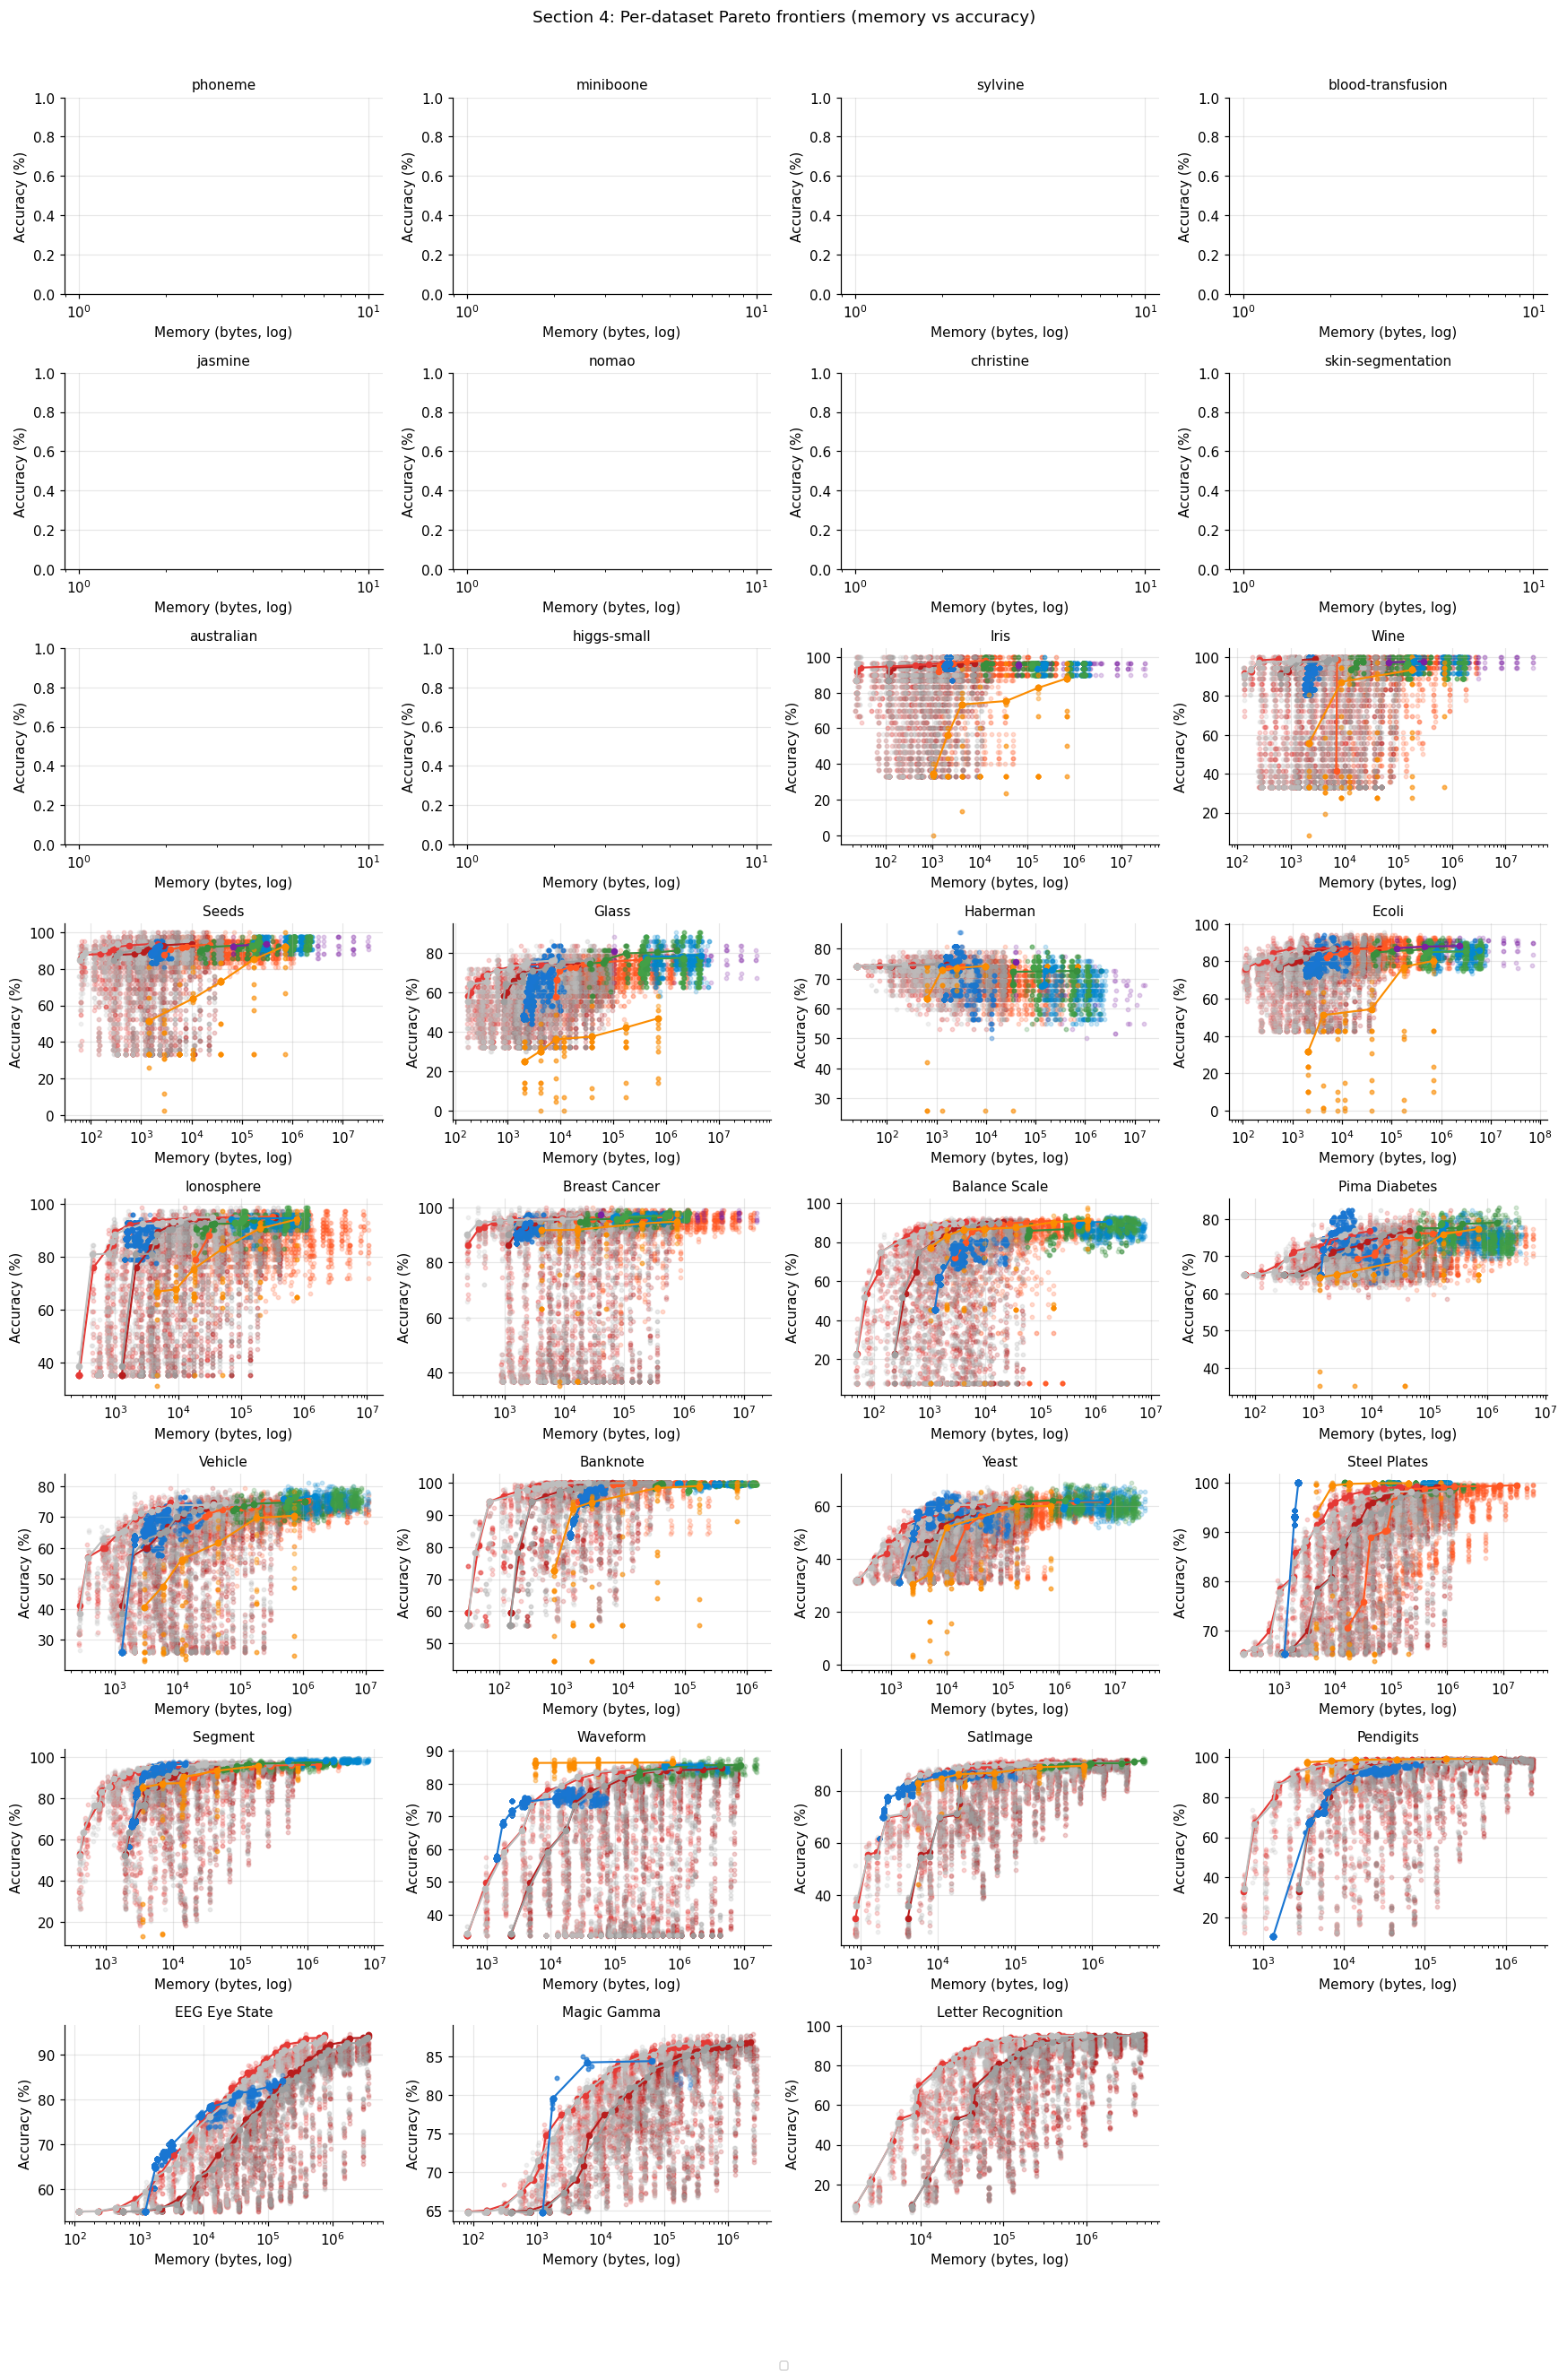

Saved: /Users/muanlartins/repos/masters/notebooks/paper_figures/section4_pareto_grid.pdf


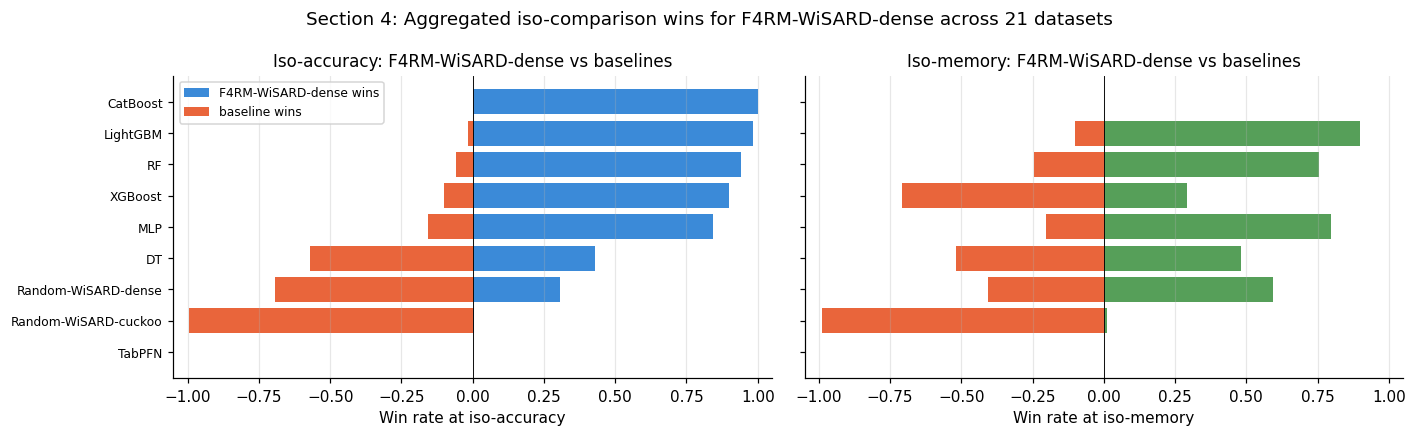

Saved: /Users/muanlartins/repos/masters/notebooks/paper_figures/section4_aggregated_wins.pdf


Saved: /Users/muanlartins/repos/masters/notebooks/paper_tables/section4_all_points.csv (226440 rows)


In [16]:
# === Section 4.5 — 21-panel Pareto grid + aggregated wins bar chart ===
# Color palette: F4RM systems in deep red shades, baselines in distinct colors.
SECTION4_COLORS = {
    "F4RM-WiSARD-dense":   "#B71C1C",
    "F4RM-WiSARD-cuckoo":  "#E53935",
    "F4RMS":               "#FF5722",
    "Random-WiSARD-dense": "#9E9E9E",
    "Random-WiSARD-cuckoo": "#BDBDBD",
    "DT":                  "#1976D2",
    "RF":                  "#388E3C",
    "CatBoost":            "#7B1FA2",
    "XGBoost":             "#0288D1",
    "LightGBM":            "#43A047",
    "MLP":                 "#FB8C00",
    "FT-Transformer":      "#5D4037",
    "TabPFN":              "#00796B",
}


def plot_pareto_grid(frontiers, df_all, out_path):
    datasets = sorted(set(ds for (_, ds) in frontiers.keys()),
                       key=lambda d: DATASETS[d][3] if d in DATASETS else 0)
    n_ds = len(datasets)
    if n_ds == 0:
        print("[FLAG] No frontiers to plot.")
        return
    cols = 4; rows = int(math.ceil(n_ds / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows))
    axes = axes.flatten() if rows * cols > 1 else [axes]
    for i, ds in enumerate(datasets):
        ax = axes[i]
        # Plot all measured points faintly
        sub = df_all[(df_all["dataset"] == ds) & (df_all["seed"] >= 0) &
                      (~df_all["infeasible"]) & (df_all["mem_bytes"] > 0)]
        for sys_name, color in SECTION4_COLORS.items():
            ss = sub[sub["system"] == sys_name]
            if len(ss):
                ax.scatter(ss["mem_bytes"], ss["test_acc"] * 100, color=color,
                            alpha=0.20, s=8)
        # Plot frontiers as solid lines
        for sys_name, color in SECTION4_COLORS.items():
            f = frontiers.get((sys_name, ds))
            if f is None or not len(f): continue
            ax.plot(f["mem_bytes"], f["test_acc"] * 100, marker="o",
                     color=color, linewidth=1.4, markersize=4, label=sys_name)
        ax.set_xscale("log")
        ax.set_xlabel("Memory (bytes, log)")
        ax.set_ylabel("Accuracy (%)")
        ax.set_title(ds, fontsize=10)
        ax.grid(True, alpha=0.3)
    for i in range(n_ds, len(axes)):
        axes[i].set_visible(False)
    # Single legend for all panels
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=5, fontsize=8,
                bbox_to_anchor=(0.5, -0.02))
    fig.suptitle("Section 4: Per-dataset Pareto frontiers (memory vs accuracy)",
                  fontsize=12)
    fig.tight_layout(rect=[0, 0.02, 1, 0.97])
    fig.savefig(out_path, bbox_inches="tight")
    fig.savefig(str(out_path).replace(".pdf", ".png"), bbox_inches="tight")
    plt.show()


plot_pareto_grid(SECTION4_FRONTIERS, SECTION4_DF, FIG_DIR / "section4_pareto_grid.pdf")
print(f"Saved: {FIG_DIR / 'section4_pareto_grid.pdf'}")


def plot_aggregated_wins(agg, focus="F4RM-WiSARD-dense", out_path=None):
    sub = agg[agg["system_a"] == focus]
    if len(sub) == 0:
        print(f"[FLAG] No aggregated wins for {focus}.")
        return
    sub = sub.sort_values("iso_acc_win_rate_a", ascending=False)
    fig, axes = plt.subplots(1, 2, figsize=(13, max(4, 0.4 * len(sub))))
    y = np.arange(len(sub))
    # Iso-acc wins
    ax = axes[0]
    ax.barh(y, sub["iso_acc_win_rate_a"].values, color="#1976D2", alpha=0.85, label=f"{focus} wins")
    ax.barh(y, -((1 - sub["iso_acc_win_rate_a"]) * (sub["iso_acc_levels_total"] > 0).astype(int)).values,
             color="#E64A19", alpha=0.85, label="baseline wins")
    ax.set_yticks(y); ax.set_yticklabels(sub["system_b"].values, fontsize=8)
    ax.axvline(0, color="black", linewidth=0.6)
    ax.set_xlim(-1.05, 1.05)
    ax.set_xlabel("Win rate at iso-accuracy")
    ax.set_title(f"Iso-accuracy: {focus} vs baselines")
    ax.invert_yaxis()
    ax.grid(True, axis="x", alpha=0.3)
    ax.legend(fontsize=8)
    # Iso-mem wins
    ax = axes[1]
    ax.barh(y, sub["iso_mem_win_rate_a"].values, color="#388E3C", alpha=0.85)
    ax.barh(y, -(1 - sub["iso_mem_win_rate_a"]).values * (sub["iso_mem_levels_total"] > 0).astype(int).values,
             color="#E64A19", alpha=0.85)
    ax.set_yticks(y); ax.set_yticklabels([])
    ax.axvline(0, color="black", linewidth=0.6)
    ax.set_xlim(-1.05, 1.05)
    ax.set_xlabel("Win rate at iso-memory")
    ax.set_title(f"Iso-memory: {focus} vs baselines")
    ax.invert_yaxis()
    ax.grid(True, axis="x", alpha=0.3)
    fig.suptitle(f"Section 4: Aggregated iso-comparison wins for {focus} across 21 datasets",
                  fontsize=12)
    fig.tight_layout()
    if out_path:
        fig.savefig(out_path); fig.savefig(str(out_path).replace(".pdf", ".png"))
    plt.show()


plot_aggregated_wins(SECTION4_AGG, "F4RM-WiSARD-dense",
                      out_path=FIG_DIR / "section4_aggregated_wins.pdf")
print(f"Saved: {FIG_DIR / 'section4_aggregated_wins.pdf'}")

# Save the master CSV of all measured points
SECTION4_DF.to_csv(TBL_DIR / "section4_all_points.csv", index=False)
print(f"Saved: {TBL_DIR / 'section4_all_points.csv'} ({len(SECTION4_DF)} rows)")

## Section 5 — FLAGs and runtime summary

Every experiment that hit a budget, was deferred, or produced surprising
results was tagged with `[FLAG]` above. Re-run any flagged section to
continue accumulating data.

**Open items per spec §6:**
- E9b heterogeneous-vs-homogeneous result — see Section 3.4 win count.
- Prior WiSARD systems — deferred to a separate session per
  `PRIOR_WISARD_SPEC.md`. Section 4.5 frontier plots will pick up new rows
  automatically once that session completes.
- E11 tuned-vs-tuned outcome — see Section 3.6 headline.
- Pareto picture shape — see Section 4.5 grid + aggregated wins.

In [17]:
# === Section 5 — Final FLAG and runtime summary ===
print("=" * 70)
print("F4RM notebook — Final FLAG and runtime summary")
print("=" * 70)

# Cache file inventory
print("\nCaches in cache/:")
for p in sorted(CACHE_DIR.glob("*.pkl")):
    sz_kb = p.stat().st_size / 1024
    print(f"  {p.name:45s} {sz_kb:>10.1f} KiB")

# CSV inventory
print("\nTables in paper_tables/:")
for p in sorted(TBL_DIR.glob("*.csv")):
    print(f"  {p.name}")

# Figure inventory
print("\nFigures in paper_figures/:")
for p in sorted(FIG_DIR.glob("*.pdf")):
    print(f"  {p.name}")

# Per-system row counts in Section 4 cache
print("\nSection 4 per-system row counts:")
try:
    print(SECTION4_DF.groupby("system").size().to_string())
except Exception as e:
    print(f"  (Section 4 cache not available: {e})")

print("\nCheck above output for any [FLAG] markers, and re-run flagged sections "
      "in additional sessions to continue accumulating data.")

F4RM notebook — Final FLAG and runtime summary

Caches in cache/:
  E10_selection_results.pkl                          141.8 KiB
  E11_grid_results.pkl                             12875.7 KiB
  E1_results.pkl                                      68.1 KiB
  E2_results.pkl                                     101.8 KiB
  E3_results.pkl                                      28.0 KiB
  E4_results.pkl                                      52.7 KiB
  E5_results.pkl                                       0.9 KiB
  E6_bleach_results.pkl                               73.7 KiB
  E7_thermometer_results.pkl                          73.8 KiB
  E8_storage_results.pkl                              56.4 KiB
  E9a_K_sweep_results.pkl                            136.4 KiB
  E9b_heterogeneous_results.pkl                        9.7 KiB
  E_raw_pareto.pkl                                    53.8 KiB
  mnist_sub_5000_1000_42.pkl                       36773.7 KiB
  section4_frontiers.pkl                            